<div style="width:100%; height:140px">
    <img src="https://www.kuleuven.be/iportfolio/images/logos/kuleuven.png/@@images/image-800-e89431243530c6a800aa1186b9f6891b.png" width=auto height=200px align=left>
</div>

KUL H02A5a Computer Vision: Group Assignment 2
---------------------------------------------------------------
**Team 27** | Fosteris Emmanouil · Paschalidis Marios · Greiner Luc · Reyes Salazar Jose · Digenis Stefanos
---------------------------------------------------------------


# Overview
This assignment consists of *three main parts* for which we expect you to provide code and extensive documentation in the notebook, with a final discussion:
* Image classification (Sect. 1)
* Semantic segmentation (Sect. 2)
* Adversarial attacks (Sect. 3)
* Discussion (Sect. 4)

## Deep learning resources
If you did not yet explore this in *Group assignment 1 (Sect. 2)*, we recommend using the Pytorch or TensorFlow (and/or Keras) library for building deep learning models.

In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import math

In [2]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision import transforms
from torchvision import tv_tensors
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

In [3]:
!pip install iterative-stratification
!pip install open-clip-torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
import albumentations as A
from albumentations.pytorch import ToTensorV2
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
import cv2

In [5]:
from torchvision.models import resnet50, ResNet50_Weights
import open_clip

In [6]:
# ────────────────────────────────────────────────────────────────
# Reproducibility — fix every RNG we touch
# ────────────────────────────────────────────────────────────────
SEED = 42
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

In [7]:
set_seed()
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]
# SMOKE-mode shrinks the train set so the whole notebook runs end-to-end
# in seconds — useful for plumbing checks. Disable before final submission.
SMOKE = False

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
!cp "/content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/dataset.zip" "/content/dataset.zip"
!unzip "/content/dataset.zip" -d "/content/local_data/"

Archive:  /content/dataset.zip
   creating: /content/local_data/train/
   creating: /content/local_data/train/img/
  inflating: /content/local_data/train/img/train_409.npy  
  inflating: /content/local_data/train/img/train_539.npy  
  inflating: /content/local_data/train/img/train_471.npy  
  inflating: /content/local_data/train/img/train_212.npy  
  inflating: /content/local_data/train/img/train_634.npy  
  inflating: /content/local_data/train/img/train_242.npy  
  inflating: /content/local_data/train/img/train_621.npy  
  inflating: /content/local_data/train/img/train_730.npy  
  inflating: /content/local_data/train/img/train_472.npy  
  inflating: /content/local_data/train/img/train_260.npy  
  inflating: /content/local_data/train/img/train_698.npy  
  inflating: /content/local_data/train/img/train_87.npy  
  inflating: /content/local_data/train/img/train_75.npy  
  inflating: /content/local_data/train/img/train_444.npy  
  inflating: /content/local_data/train/img/train_533.npy  
  

In [10]:
path = '/content/local_data/'

## PASCAL VOC 2009
For this project you will be using the [PASCAL VOC 2009](http://host.robots.ox.ac.uk/pascal/VOC/voc2009/index.html) dataset. This dataset consists of colour images of various scenes with different object classes (e.g. animal: *bird, cat, ...*; vehicle: *aeroplane, bicycle, ...*), totalling 20 classes.

In [11]:
# Loading the training data
train_df = pd.read_csv(path + 'train/train_set.csv', index_col="Id")
labels = train_df.columns
train_df["img"] = [np.load(path + 'train/img/train_{}.npy'.format(idx)) for idx, _ in train_df.iterrows()]
train_df["seg"] = [np.load(path + 'train/seg/train_{}.npy'.format(idx)) for idx, _ in train_df.iterrows()]
print("The training set contains {} examples.".format(len(train_df)))

# Show some examples
fig, axs = plt.subplots(2, 20, figsize=(10 * 20, 10 * 2))
for i, label in enumerate(labels):
    df = train_df.loc[train_df[label] == 1]
    axs[0, i].imshow(df.iloc[0]["img"], vmin=0, vmax=255)
    axs[0, i].set_title("\n".join(label for label in labels if df.iloc[0][label] == 1), fontsize=40)
    axs[0, i].axis("off")
    axs[1, i].imshow(df.iloc[0]["seg"], vmin=0, vmax=20)  # with the absolute color scale it will be clear that the arrays in the "seg" column are label maps (labels in [0, 20])
    axs[1, i].axis("off")

plt.show()

# The training dataframe contains for each image 20 columns with the ground truth classification labels and 20 column with the ground truth segmentation maps for each class
train_df.head(1)

Output hidden; open in https://colab.research.google.com to view.

In [12]:
# Loading the test data
test_df = pd.read_csv(path + 'test/test_set.csv', index_col="Id")
test_df["img"] = [np.load(path + 'test/img/test_{}.npy'.format(idx)) for idx, _ in test_df.iterrows()]
test_df["seg"] = [-1 * np.ones(img.shape[:2], dtype=np.int8) for img in test_df["img"]]
print("The test set contains {} examples.".format(len(test_df)))

# The test dataframe is similar to the training dataframe, but here the values are -1 --> your task is to fill in these as good as possible in Sect. 2 and Sect. 3; in Sect. 6 this dataframe is automatically transformed in the submission CSV!
test_df.head(1)

The test set contains 750 examples.


,aeroplane,bicycle,bird,boat,bottle,bus,car,cat,chair,cow,...,horse,motorbike,person,pottedplant,sheep,sofa,train,tvmonitor,img,seg
Id,,,,,,,,,,,,,,,,,,,,,
0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,"[[[139, 130, 115], [136, 127, 112], [112, 102,...","[[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ..."


Training examples : 749
Test examples     : 750

── Image sizes (train) ──────────────────────────────
  Height : min=112  max=500  mean=383.1  std=65.4
  Width  : min=257   max=500   mean=471.8   std=57.9
  Aspect : min=0.61  max=4.46  mean=1.28

── Image sizes (test) ───────────────────────────────
  Height : min=151  max=500  mean=386.0
  Width  : min=174   max=500   mean=469.1


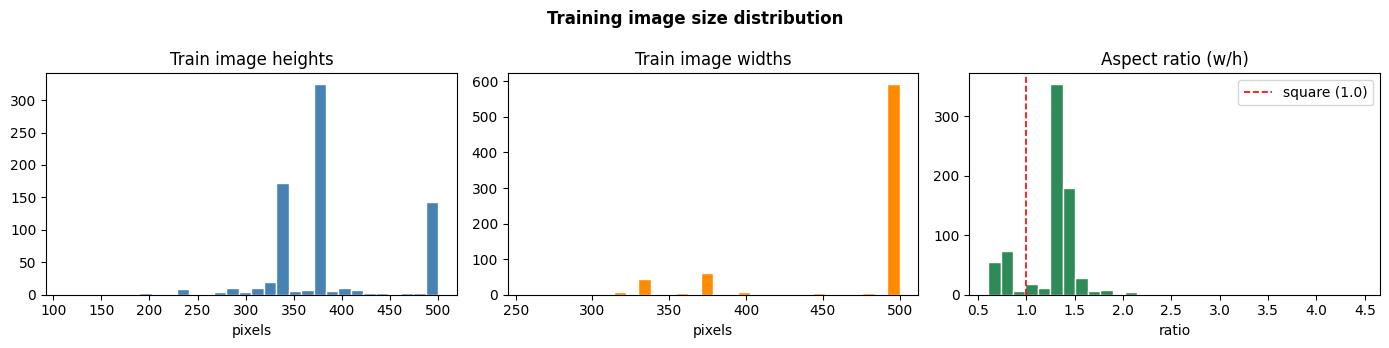


Landscape (w>h): 603  |  Portrait (h>w): 139  |  Square: 7


In [13]:
# ─────────────────────────────────────────────────────────────
# 1.1.1 — Image-size statistics (train + test)
# ─────────────────────────────────────────────────────────────
heights = [img.shape[0] for img in train_df["img"]]
widths  = [img.shape[1] for img in train_df["img"]]
aspects = [w / h for h, w in zip(heights, widths)]

t_heights = [img.shape[0] for img in test_df["img"]]
t_widths  = [img.shape[1] for img in test_df["img"]]

print(f"Training examples : {len(train_df)}")
print(f"Test examples     : {len(test_df)}\n")
print("── Image sizes (train) ──────────────────────────────")
print(f"  Height : min={min(heights)}  max={max(heights)}  mean={np.mean(heights):.1f}  std={np.std(heights):.1f}")
print(f"  Width  : min={min(widths)}   max={max(widths)}   mean={np.mean(widths):.1f}   std={np.std(widths):.1f}")
print(f"  Aspect : min={min(aspects):.2f}  max={max(aspects):.2f}  mean={np.mean(aspects):.2f}\n")
print("── Image sizes (test) ───────────────────────────────")
print(f"  Height : min={min(t_heights)}  max={max(t_heights)}  mean={np.mean(t_heights):.1f}")
print(f"  Width  : min={min(t_widths)}   max={max(t_widths)}   mean={np.mean(t_widths):.1f}")

# ── plots ──
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].hist(heights, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Train image heights"); axes[0].set_xlabel("pixels")
axes[1].hist(widths,  bins=30, color="darkorange", edgecolor="white")
axes[1].set_title("Train image widths");  axes[1].set_xlabel("pixels")
axes[2].hist(aspects, bins=30, color="seagreen", edgecolor="white")
axes[2].axvline(1.0, color="red", linewidth=1.2, linestyle="--", label="square (1.0)")
axes[2].set_title("Aspect ratio (w/h)");   axes[2].set_xlabel("ratio")
axes[2].legend()
fig.suptitle("Training image size distribution", fontweight="bold")
plt.tight_layout(); plt.show()

n_landscape = sum(1 for a in aspects if a > 1)
n_portrait  = sum(1 for a in aspects if a < 1)
n_square    = sum(1 for a in aspects if a == 1)
print(f"\nLandscape (w>h): {n_landscape}  |  Portrait (h>w): {n_portrait}  |  Square: {n_square}")

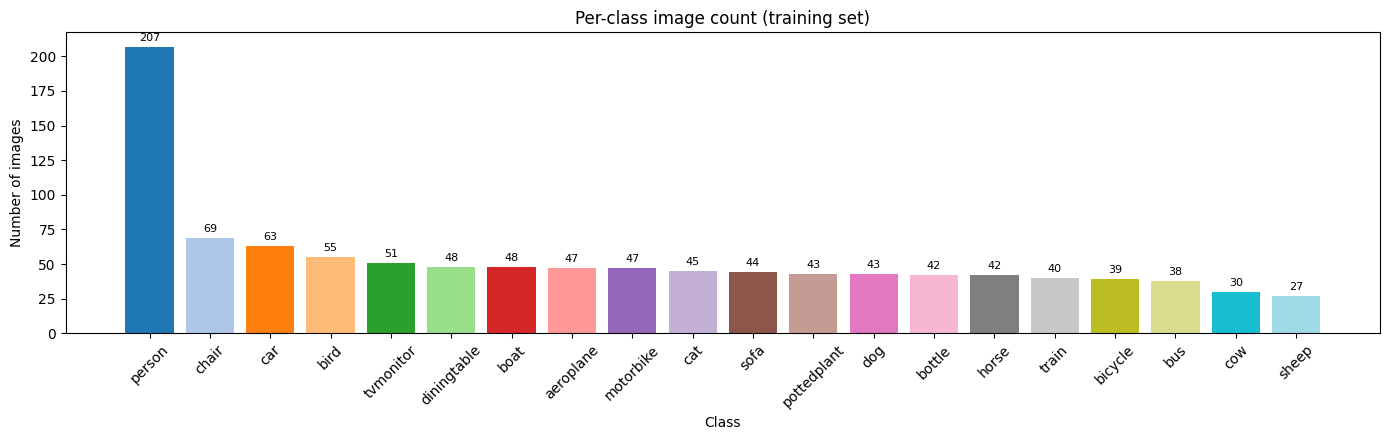

Per-class counts (sorted, descending):
  person           207  (27.6%)
  chair             69  (9.2%)
  car               63  (8.4%)
  bird              55  (7.3%)
  tvmonitor         51  (6.8%)
  diningtable       48  (6.4%)
  boat              48  (6.4%)
  aeroplane         47  (6.3%)
  motorbike         47  (6.3%)
  cat               45  (6.0%)
  sofa              44  (5.9%)
  pottedplant       43  (5.7%)
  dog               43  (5.7%)
  bottle            42  (5.6%)
  horse             42  (5.6%)
  train             40  (5.3%)
  bicycle           39  (5.2%)
  bus               38  (5.1%)
  cow               30  (4.0%)
  sheep             27  (3.6%)


In [14]:
# ─────────────────────────────────────────────────────────────
# 1.1.2 — Per-class label frequency (training set)
# ─────────────────────────────────────────────────────────────
label_counts = train_df[labels].sum().sort_values(ascending=False)

CLASS_CMAP = plt.cm.tab20   # 20-distinct-colour palette for class plots
fig, ax = plt.subplots(figsize=(14, 4.5))
bars = ax.bar(label_counts.index, label_counts.values,
              color=[CLASS_CMAP(i / len(labels)) for i in range(len(labels))])
ax.set_ylabel("Number of images"); ax.set_xlabel("Class")
ax.set_title("Per-class image count (training set)")
ax.tick_params(axis="x", rotation=45)
for bar, v in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 3, str(int(v)),
            ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

print("Per-class counts (sorted, descending):")
for cls, cnt in label_counts.items():
    pct = 100 * cnt / len(train_df)
    print(f"  {cls:<15} {int(cnt):4d}  ({pct:.1f}%)")

# Implication: 'person' dominates (~28% of training images contain a person);
# 'sheep' / 'cow' are rarest (~3-4%). A single global threshold of 0.5 would
# bias the model toward easy majority classes. Per-class threshold tuning
# on the validation set (cell 1.6) lets us trade precision/recall differently
# per class — important for maximising the per-class Dice in the Kaggle metric.


Label cardinality (number of labels per image):
count    749.000000
mean       1.425901
std        0.683199
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000
dtype: float64

  1 label(s) : 504 images  (67.3%)
  2 label(s) : 179 images  (23.9%)
  3 label(s) : 59 images  (7.9%)
  4 label(s) : 6 images  (0.8%)
  5 label(s) : 1 images  (0.1%)


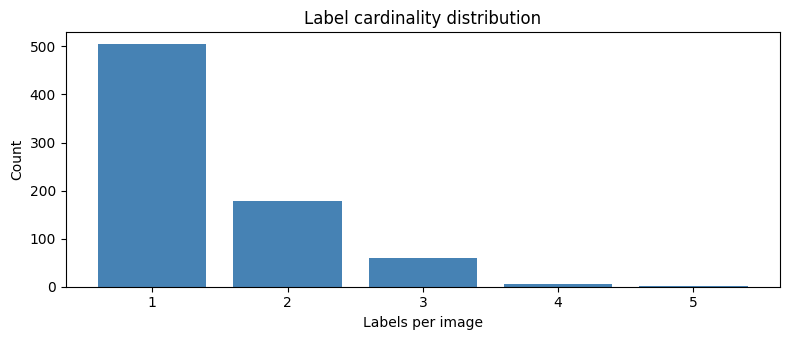


Positive (image,class) pairs: 1068 / 14980 = 7.13%
Negative (image,class) pairs: 13912 / 14980 = 92.87%
Positive/Negative ratio: 1 : 13.0


In [15]:
# ─────────────────────────────────────────────────────────────
# 1.1.3 — Label cardinality + positive/negative pair imbalance
# ─────────────────────────────────────────────────────────────
labels_per_image = train_df[labels].sum(axis=1)

print("Label cardinality (number of labels per image):")
print(labels_per_image.describe())
print()
card_counts = labels_per_image.value_counts().sort_index()
for k, v in card_counts.items():
    print(f"  {int(k)} label(s) : {v} images  ({100*v/len(train_df):.1f}%)")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(card_counts.index, card_counts.values, color="steelblue")
ax.set_xlabel("Labels per image"); ax.set_ylabel("Count")
ax.set_title("Label cardinality distribution")
ax.set_xticks(card_counts.index)
plt.tight_layout(); plt.show()

# Positive / negative (image,class) pair imbalance — drives the loss choice.
total_pairs = len(train_df) * len(labels)
pos_pairs   = int(train_df[labels].values.sum())
neg_pairs   = total_pairs - pos_pairs
print(f"\nPositive (image,class) pairs: {pos_pairs} / {total_pairs} = {100*pos_pairs/total_pairs:.2f}%")
print(f"Negative (image,class) pairs: {neg_pairs} / {total_pairs} = {100*neg_pairs/total_pairs:.2f}%")
print(f"Positive/Negative ratio: 1 : {neg_pairs/pos_pairs:.1f}")

# Implication: most images carry only 1-3 of the 20 classes → ~93-95% of
# (image, class) pairs are NEGATIVE. Plain BCE wastes capacity learning to
# say "no" ~14× more often than "yes". Asymmetric Loss (ASL, Ridnik 2021)
# explicitly down-weights easy negatives via a separate γ⁻ exponent and
# probability-shift; this is the documented "improvement" we apply in 1.X.


VOC sample (200 images) per-channel mean: R=0.4611  G=0.4536  B=0.4190
VOC sample (200 images) per-channel std : R=0.2355  G=0.2308  B=0.2364

ImageNet reference  mean: R=0.4850  G=0.4560  B=0.4060
ImageNet reference  std : R=0.2290  G=0.2240  B=0.2250

|delta(mean)| max: 0.0239
|delta(std)|  max: 0.0114


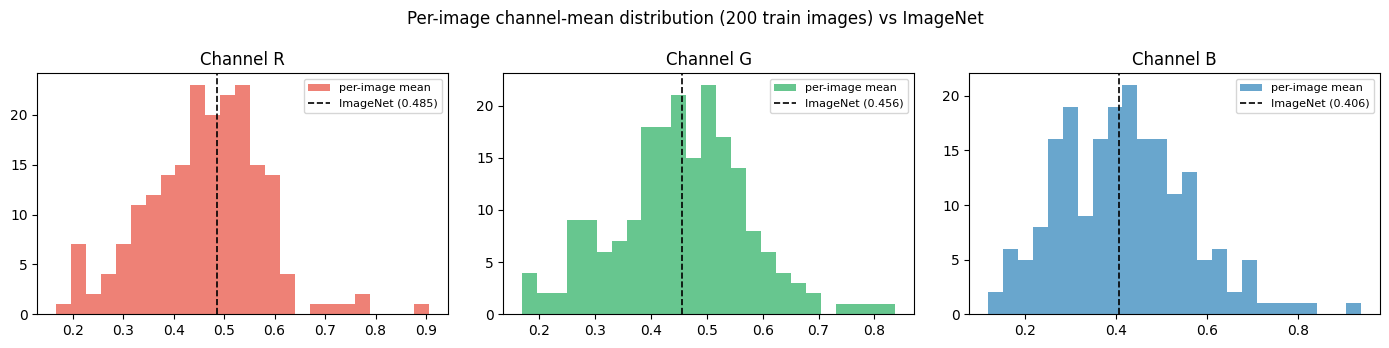

In [16]:
# ─────────────────────────────────────────────────────────────
# 1.1.4 — Image pixel intensity statistics vs ImageNet
# ─────────────────────────────────────────────────────────────
SAMPLE = min(200, len(train_df))            # full scan would be slow + redundant
rng    = np.random.default_rng(SEED)
idxs   = rng.choice(len(train_df), SAMPLE, replace=False)

means, stds = [], []
for i in idxs:
    img = train_df.iloc[i]["img"].astype(np.float32) / 255.0
    means.append(img.reshape(-1, 3).mean(axis=0))
    stds.append( img.reshape(-1, 3).std(axis=0))

means = np.stack(means)
stds  = np.stack(stds)
dataset_mean = means.mean(axis=0)
dataset_std  = stds.mean(axis=0)

print(f"VOC sample ({SAMPLE} images) per-channel mean: "
      f"R={dataset_mean[0]:.4f}  G={dataset_mean[1]:.4f}  B={dataset_mean[2]:.4f}")
print(f"VOC sample ({SAMPLE} images) per-channel std : "
      f"R={dataset_std[0]:.4f}  G={dataset_std[1]:.4f}  B={dataset_std[2]:.4f}\n")
print(f"ImageNet reference  mean: R={IMG_MEAN[0]:.4f}  G={IMG_MEAN[1]:.4f}  B={IMG_MEAN[2]:.4f}")
print(f"ImageNet reference  std : R={IMG_STD[0]:.4f}  G={IMG_STD[1]:.4f}  B={IMG_STD[2]:.4f}")
print(f"\n|delta(mean)| max: {np.abs(dataset_mean - np.array(IMG_MEAN)).max():.4f}")
print(f"|delta(std)|  max: {np.abs(dataset_std  - np.array(IMG_STD)).max():.4f}")

channels = ["R", "G", "B"]
colors   = ["#e74c3c", "#27ae60", "#2980b9"]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for i, (ch, col) in enumerate(zip(channels, colors)):
    axes[i].hist(means[:, i], bins=25, color=col, alpha=0.7, label="per-image mean")
    axes[i].axvline(IMG_MEAN[i], color="black", linestyle="--", linewidth=1.2,
                    label=f"ImageNet ({IMG_MEAN[i]:.3f})")
    axes[i].set_title(f"Channel {ch}")
    axes[i].legend(fontsize=8)
plt.suptitle(f"Per-image channel-mean distribution ({SAMPLE} train images) vs ImageNet")
plt.tight_layout(); plt.show()

# Implication: VOC2009 channel statistics are within ~0.02 of ImageNet's
# reference values. So (a) ImageNet IMG_MEAN/IMG_STD is the right
# normalisation — no need to compute dataset-specific stats; and (b) the
# low-level features ImageNet-pretrained ResNet-50 learned should transfer
# to VOC essentially out-of-the-box, justifying the transfer-learning model.

Train subset : 607  |  Val subset : 142
Val fraction : 19.0%

Class-frequency deviation (train vs val):
  Max  : 0.0239  (worst class: person)
  Mean : 0.0055


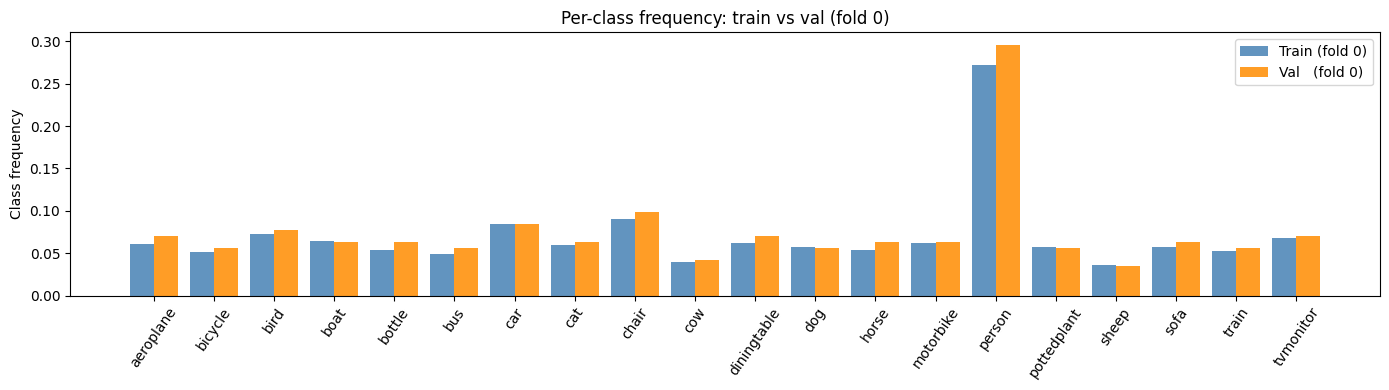

In [17]:

# ─────────────────────────────────────────────────────────────
# 1.1.5 — Multi-label stratified split sanity check
# (we use the SAME split in 1.2 to define train/val for training)
# ─────────────────────────────────────────────────────────────
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_all = train_df[labels].values.astype(int)
splits = list(mskf.split(np.zeros(len(y_all)), y_all))
tr_idx, va_idx = splits[0]   # FOLD 0 — fixed for the rest of Section 1
tr_sub, va_sub = train_df.iloc[tr_idx], train_df.iloc[va_idx]

print(f"Train subset : {len(tr_sub)}  |  Val subset : {len(va_sub)}")
print(f"Val fraction : {len(va_sub)/len(train_df)*100:.1f}%\n")

# Per-class frequency drift — the metric the stratifier optimises
tr_freq = tr_sub[labels].mean()
va_freq = va_sub[labels].mean()
diff    = (tr_freq - va_freq).abs()
print(f"Class-frequency deviation (train vs val):")
print(f"  Max  : {diff.max():.4f}  (worst class: {diff.idxmax()})")
print(f"  Mean : {diff.mean():.4f}")

fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(len(labels))
ax.bar(x - 0.2, tr_freq.values, 0.4, label="Train (fold 0)", color="steelblue", alpha=0.85)
ax.bar(x + 0.2, va_freq.values, 0.4, label="Val   (fold 0)", color="darkorange", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=55)
ax.set_ylabel("Class frequency"); ax.set_title("Per-class frequency: train vs val (fold 0)")
ax.legend(); plt.tight_layout(); plt.show()

# Implication: with MultilabelStratifiedKFold the per-class frequencies stay
# very close between train and val — far better than a random split would,
# especially for rare classes (sheep, cow). A reliable val set is essential
# because we tune per-class thresholds on it (1.6); a leaky / imbalanced val
# would give us misleading thresholds. We re-use FOLD 0 throughout the
# assignment so all model variants are compared on the same held-out images.

Pixel-level class distribution (excluding void=255):
  Total valid pixels : 133,567,772

Class                 Pixels   Freq %   Imbalance ratio
------------------------------------------------------------
  background     103,837,989   77.74%             1.0x  ← background
  aeroplane          897,689    0.67%           115.7x
  bicycle            408,512    0.31%           254.2x
  bird             1,341,794    1.00%            77.4x
  boat             1,038,726    0.78%           100.0x
  bottle           1,060,907    0.79%            97.9x
  bus              1,918,055    1.44%            54.1x
  car              1,679,373    1.26%            61.8x
  cat              2,280,754    1.71%            45.5x
  chair            1,104,030    0.83%            94.1x
  cow                888,759    0.67%           116.8x
  diningtable      1,898,787    1.42%            54.7x
  dog                994,808    0.74%           104.4x
  horse            1,080,647    0.81%            96.1x
  motorbik

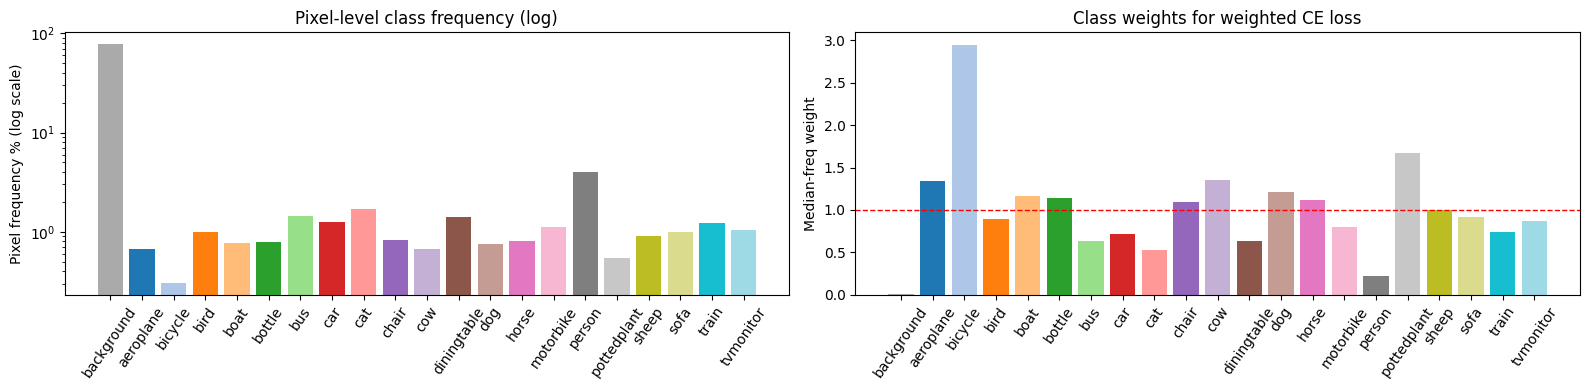


→ Implication: if background >> foreground, plain CrossEntropy will overfit to background.
  Use weighted CE (class_weights tensor above) OR Dice loss OR a combination.


In [19]:
# ─────────────────────────────────────────────────────────────
# SEG EDA 1 — Pixel-level class frequency
# CRITICAL: motivates loss function choice (weighted CE vs Dice)
# ─────────────────────────────────────────────────────────────
NUM_CLASSES = 21   # 0=background, 1-20=VOC classes

pixel_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
for seg in train_df["seg"]:
    # VOC uses 255 as void/border — exclude it
    valid = seg[seg != 255]
    for c in range(NUM_CLASSES):
        pixel_counts[c] += int((valid == c).sum())

total_valid = pixel_counts.sum()
pixel_freq  = pixel_counts / total_valid

class_names_full = ["background"] + list(labels)

print("Pixel-level class distribution (excluding void=255):")
print(f"  Total valid pixels : {total_valid:,}")
print(f"\n{'Class':<15} {'Pixels':>12} {'Freq %':>8}  {'Imbalance ratio':>16}")
print("-" * 60)
for i, (name, cnt, freq) in enumerate(zip(class_names_full, pixel_counts, pixel_freq)):
    ratio = pixel_freq[0] / freq if freq > 0 else float("inf")
    marker = "  ← background" if i == 0 else ""
    print(f"  {name:<13} {cnt:>12,} {100*freq:>7.2f}%  {ratio:>14.1f}x{marker}")

# ── Compute class weights for weighted CrossEntropy ──────────────────────────
# Standard median-frequency balancing (Eigen & Fergus, 2015):
#   w_c = median_freq / freq_c   (only over classes that appear)
present      = pixel_freq[pixel_freq > 0]
median_freq  = np.median(present)
class_weights = np.where(pixel_freq > 0, median_freq / pixel_freq, 0.0)
class_weights /= class_weights[class_weights > 0].mean()   # normalise to mean=1

print(f"\nMedian-frequency class weights (mean-normalised):")
for name, w in zip(class_names_full, class_weights):
    print(f"  {name:<15} {w:.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].bar(class_names_full, 100 * pixel_freq,
            color=["#aaaaaa"] + [plt.cm.tab20(i/20) for i in range(20)])
axes[0].set_yscale("log"); axes[0].set_ylabel("Pixel frequency % (log scale)")
axes[0].set_title("Pixel-level class frequency (log)"); axes[0].tick_params(axis="x", rotation=55)

axes[1].bar(class_names_full, class_weights,
            color=["#aaaaaa"] + [plt.cm.tab20(i/20) for i in range(20)])
axes[1].set_ylabel("Median-freq weight"); axes[1].set_title("Class weights for weighted CE loss")
axes[1].tick_params(axis="x", rotation=55); axes[1].axhline(1.0, ls="--", color="red", lw=1)

plt.tight_layout(); plt.show()

print("\n→ Implication: if background >> foreground, plain CrossEntropy will overfit to background.")
print("  Use weighted CE (class_weights tensor above) OR Dice loss OR a combination.")

Images with at least one void pixel : 0 / 749
Void pixels across all training images:
  Total void pixels : 0
  Mean per image    : 0.00%
  Max in one image  : 0.00%
  Median            : 0.00%


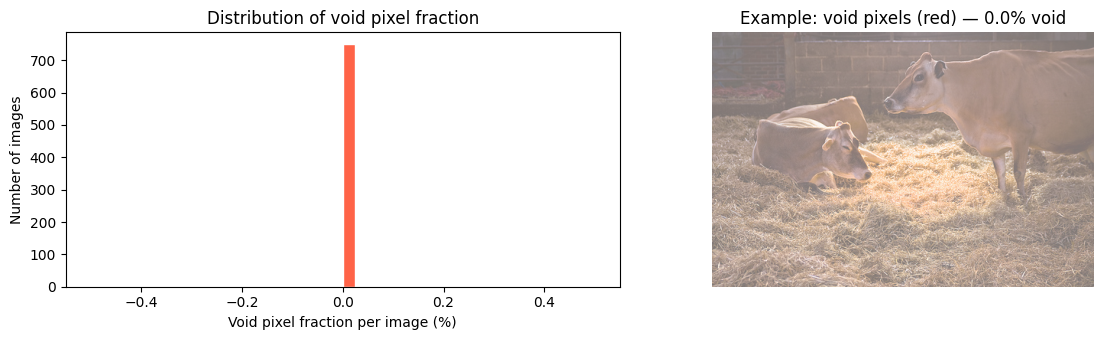


→ Implication: ALWAYS pass ignore_index=255 to nn.CrossEntropyLoss().
  Also make sure your target tensor dtype is torch.long, not float.
  If you resize masks, use nearest-neighbour interpolation, not bilinear
  (bilinear creates non-integer values that corrupt the void label).


In [18]:
# ─────────────────────────────────────────────────────────────
# SEG EDA 2 — Void / boundary pixels (label = 255)
# CRITICAL: must set ignore_index=255 in your loss function
# ─────────────────────────────────────────────────────────────
void_counts  = []
total_pixels = []

for seg in train_df["seg"]:
    n_void  = int((seg == 255).sum())
    n_total = seg.size
    void_counts.append(n_void)
    total_pixels.append(n_total)

void_counts  = np.array(void_counts)
total_pixels = np.array(total_pixels)
void_frac    = void_counts / total_pixels

print(f"Images with at least one void pixel : {int((void_counts > 0).sum())} / {len(train_df)}")
print(f"Void pixels across all training images:")
print(f"  Total void pixels : {void_counts.sum():,}")
print(f"  Mean per image    : {void_frac.mean()*100:.2f}%")
print(f"  Max in one image  : {void_frac.max()*100:.2f}%")
print(f"  Median            : {np.median(void_frac)*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(void_frac * 100, bins=40, color="tomato", edgecolor="white")
axes[0].set_xlabel("Void pixel fraction per image (%)")
axes[0].set_ylabel("Number of images")
axes[0].set_title("Distribution of void pixel fraction")

# Show one example mask with void pixels highlighted
example_idx = np.argmax(void_frac)
example_seg = train_df.iloc[example_idx]["seg"]
overlay = example_seg.copy().astype(np.float32)
void_mask = (example_seg == 255)
axes[1].imshow(train_df.iloc[example_idx]["img"])
axes[1].imshow(void_mask, alpha=0.5, cmap="Reds")
axes[1].set_title(f"Example: void pixels (red) — {100*void_frac[example_idx]:.1f}% void")
axes[1].axis("off")

plt.tight_layout(); plt.show()

print("\n→ Implication: ALWAYS pass ignore_index=255 to nn.CrossEntropyLoss().")
print("  Also make sure your target tensor dtype is torch.long, not float.")
print("  If you resize masks, use nearest-neighbour interpolation, not bilinear")
print("  (bilinear creates non-integer values that corrupt the void label).")

Class            #Objects  Median px  % of image  Tiny (<1%)
-----------------------------------------------------------------
  aeroplane           316          2        0.0%       85.1%
  bicycle           1,938          2        0.0%       98.2%
  bird                526          2        0.0%       87.8%
  boat                638          2        0.0%       90.4%
  bottle               84       4666        2.5%       40.5%
  bus                 105        140        0.1%       60.0%
  car                 153       1045        0.6%       54.2%
  cat                 531          1        0.0%       90.0%
  chair               685         12        0.0%       88.6%
  cow                 285          5        0.0%       83.5%
  diningtable         115        304        0.2%       58.3%
  dog                 238          1        0.0%       79.8%
  horse               280          1        0.0%       79.6%
  motorbike           630          2        0.0%       91.0%
  person           

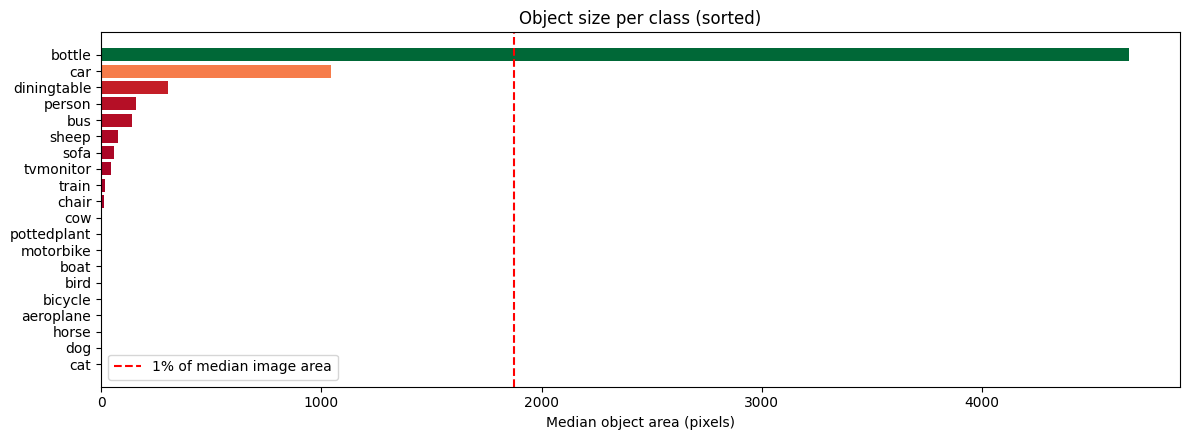


→ Implication: small classes (bottle, plant, chair) need higher resolution
  or multi-scale context (ASPP dilation rates, FPN decoder).
  If median < 1% of image area, that class is at serious risk of being
  missed by a plain encoder-decoder at 224×224.


In [20]:
# ─────────────────────────────────────────────────────────────
# SEG EDA 3 — Object size (connected component area) per class
# Motivates: input resolution, multi-scale features (ASPP/FPN)
# ─────────────────────────────────────────────────────────────
from scipy import ndimage

object_areas = {c: [] for c in range(1, NUM_CLASSES)}  # skip background

for seg in train_df["seg"]:
    for c in range(1, NUM_CLASSES):
        binary = (seg == c)
        if not binary.any():
            continue
        labeled, n_objs = ndimage.label(binary)
        for obj_id in range(1, n_objs + 1):
            area = int((labeled == obj_id).sum())
            object_areas[c].append(area)

# Normalise by image area (so it's scale-invariant)
# Use median image area as reference
img_areas = [img.shape[0] * img.shape[1] for img in train_df["img"]]
median_img_area = np.median(img_areas)

print(f"{'Class':<15} {'#Objects':>9} {'Median px':>10} {'% of image':>11} {'Tiny (<1%)':>11}")
print("-" * 65)
for c in range(1, NUM_CLASSES):
    areas = object_areas[c]
    if not areas:
        print(f"  {labels[c-1]:<13} {'—':>9}")
        continue
    a  = np.array(areas)
    pct_of_img = 100 * np.median(a) / median_img_area
    tiny_frac  = 100 * (a < 0.01 * median_img_area).mean()
    print(f"  {labels[c-1]:<13} {len(a):>9,} {np.median(a):>10.0f}"
          f"  {pct_of_img:>9.1f}%  {tiny_frac:>9.1f}%")

# ── Plot: median object size ranked ──────────────────────────────────────────
medians  = {labels[c-1]: np.median(object_areas[c]) if object_areas[c] else 0
            for c in range(1, NUM_CLASSES)}
sorted_k = sorted(medians, key=medians.get)
sorted_v = [medians[k] for k in sorted_k]
colors   = [plt.cm.RdYlGn(v / max(sorted_v)) for v in sorted_v]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.barh(sorted_k, sorted_v, color=colors)
ax.axvline(0.01 * median_img_area, color="red", ls="--", lw=1.5,
           label="1% of median image area")
ax.set_xlabel("Median object area (pixels)"); ax.set_title("Object size per class (sorted)")
ax.legend(); plt.tight_layout(); plt.show()

print("\n→ Implication: small classes (bottle, plant, chair) need higher resolution")
print("  or multi-scale context (ASPP dilation rates, FPN decoder).")
print("  If median < 1% of image area, that class is at serious risk of being")
print("  missed by a plain encoder-decoder at 224×224.")

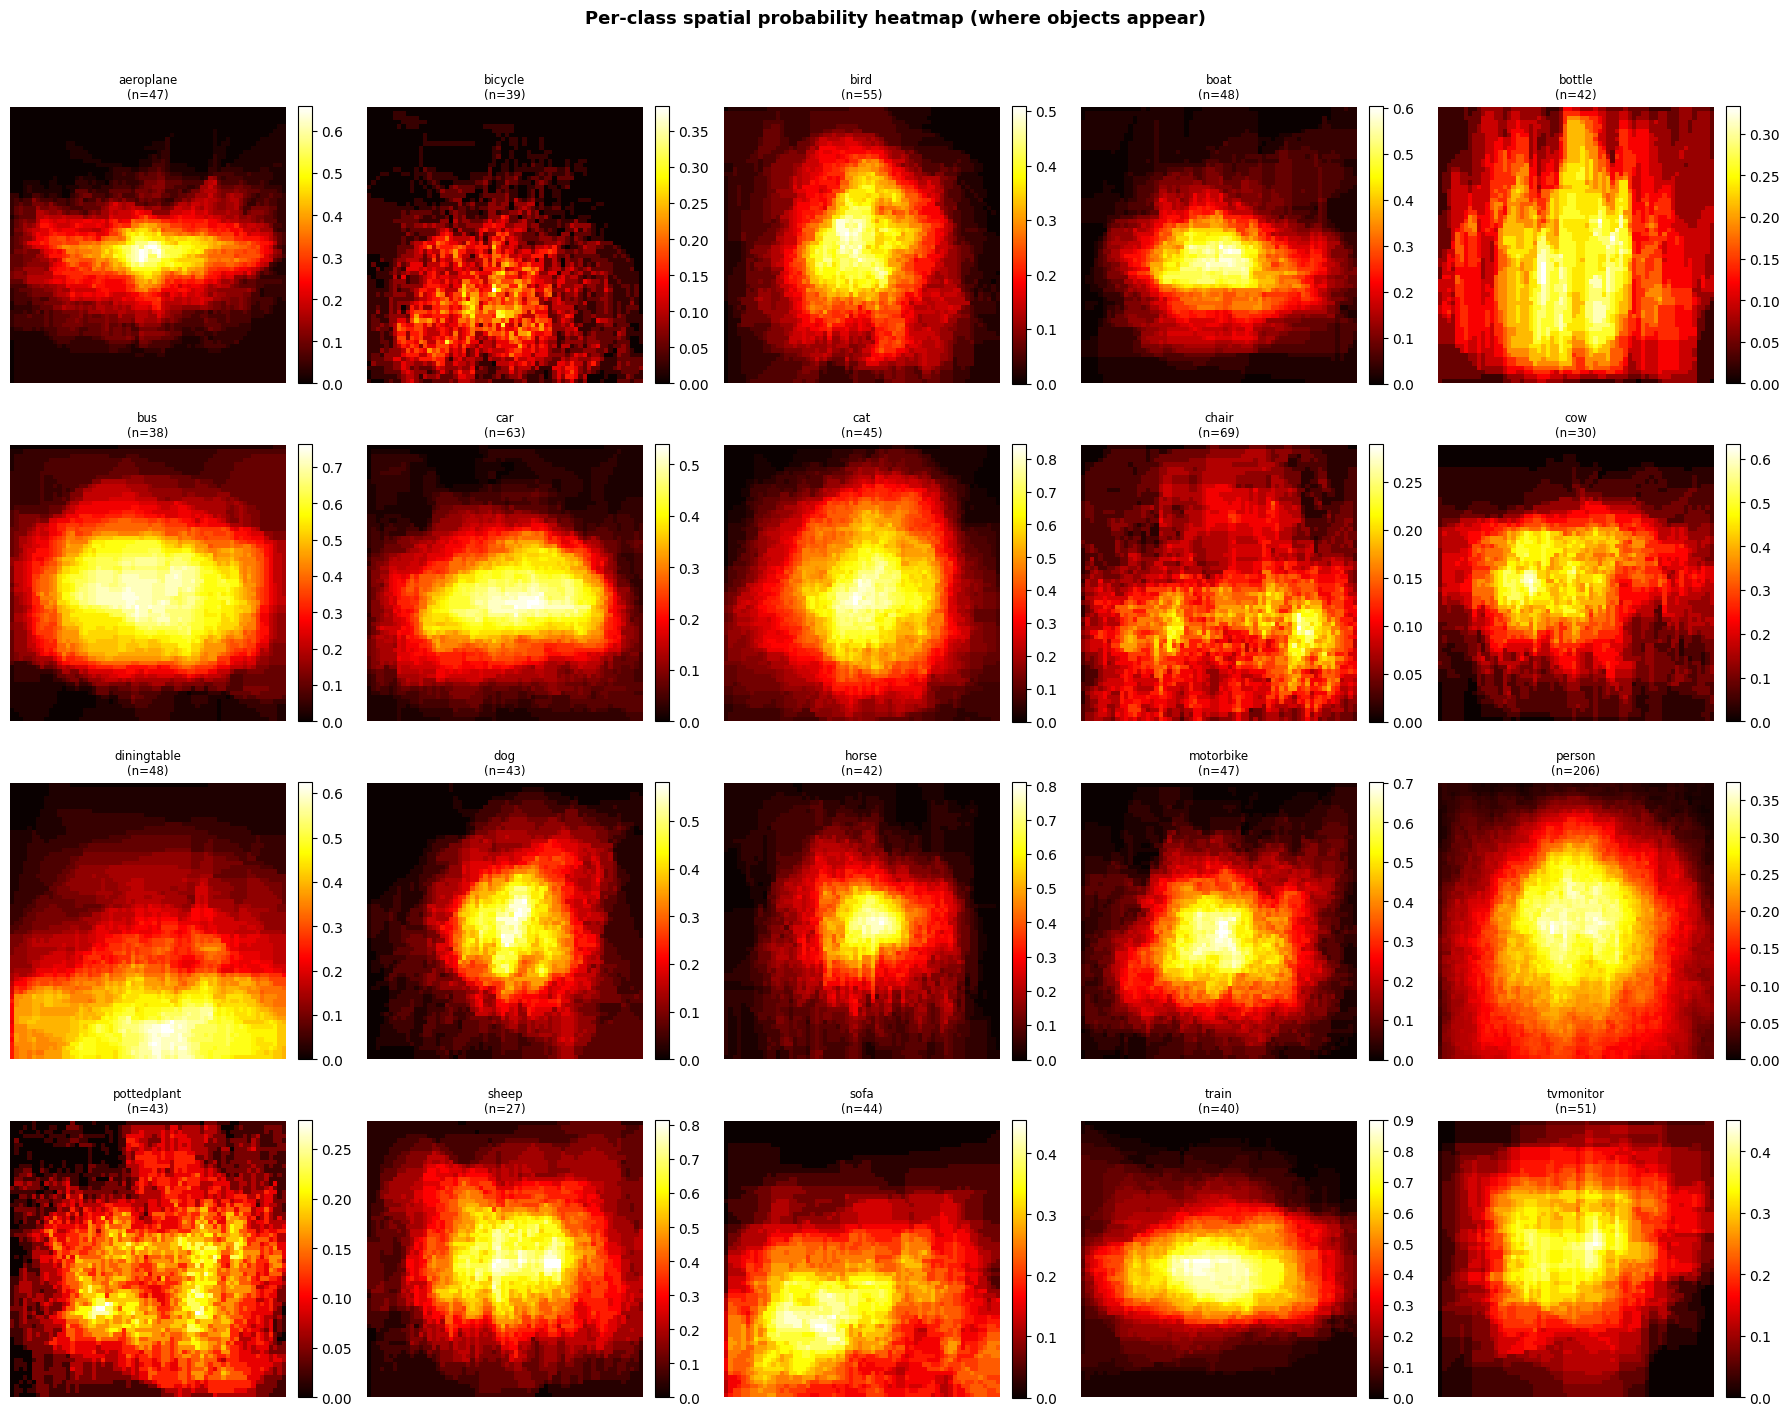


→ Implication: strong spatial bias (aeroplane top-centre, grass bottom)
  suggests the model may learn location shortcuts rather than features.
  Consider random crops during training rather than just resizing.
  Also justifies NOT using positional encodings that over-anchor predictions.


In [21]:
# ─────────────────────────────────────────────────────────────
# SEG EDA 4 — Spatial heatmaps: where does each class appear?
# Motivates: positional encodings, spatial attention, sanity check
# ─────────────────────────────────────────────────────────────
import cv2

HMAP_SIZE  = 64   # resize all masks to this for averaging
heatmaps   = np.zeros((NUM_CLASSES, HMAP_SIZE, HMAP_SIZE), dtype=np.float64)
n_per_class = np.zeros(NUM_CLASSES, dtype=np.int64)

for seg in train_df["seg"]:
    seg_r = cv2.resize(seg.astype(np.uint8), (HMAP_SIZE, HMAP_SIZE),
                       interpolation=cv2.INTER_NEAREST)
    for c in range(NUM_CLASSES):
        mask = (seg_r == c).astype(np.float32)
        if mask.any():
            heatmaps[c]    += mask
            n_per_class[c] += 1

# Normalise to [0,1] per class
for c in range(NUM_CLASSES):
    if n_per_class[c] > 0:
        heatmaps[c] /= n_per_class[c]

# ── Plot: 4×5 grid of per-class heatmaps (skip background) ───────────────────
fig, axes = plt.subplots(4, 5, figsize=(18, 14))
for i, ax in enumerate(axes.flatten()):
    c = i + 1   # skip background (class 0)
    if c >= NUM_CLASSES:
        ax.axis("off"); continue
    im = ax.imshow(heatmaps[c], cmap="hot", vmin=0)
    ax.set_title(f"{labels[c-1]}\n(n={n_per_class[c]})", fontsize=8.5)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Per-class spatial probability heatmap (where objects appear)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

print("\n→ Implication: strong spatial bias (aeroplane top-centre, grass bottom)")
print("  suggests the model may learn location shortcuts rather than features.")
print("  Consider random crops during training rather than just resizing.")
print("  Also justifies NOT using positional encodings that over-anchor predictions.")

Class            #Images  Mean cov%  Median cov%    Min%    Max%
-----------------------------------------------------------------
  aeroplane           47       11.2%        9.2%    0.1%   43.4%
  bicycle             39        5.8%        3.7%    0.1%   25.0%
  bird                55       13.3%        7.5%    0.1%   68.2%
  boat                48       12.4%       12.5%    0.3%   33.0%
  bottle              42       14.3%        5.7%    0.1%   78.1%
  bus                 38       28.5%       29.6%    0.5%   58.5%
  car                 63       15.4%       11.5%    0.1%   77.3%
  cat                 45       27.7%       27.3%    2.5%   72.7%
  chair               69        9.0%        4.4%    0.2%   68.6%
  cow                 30       16.9%       11.8%    1.1%   55.6%
  diningtable         48       21.4%       15.5%    0.3%   97.0%
  dog                 43       12.9%        9.3%    0.6%   46.6%
  horse               42       14.9%        9.8%    0.5%   57.5%
  motorbike           47

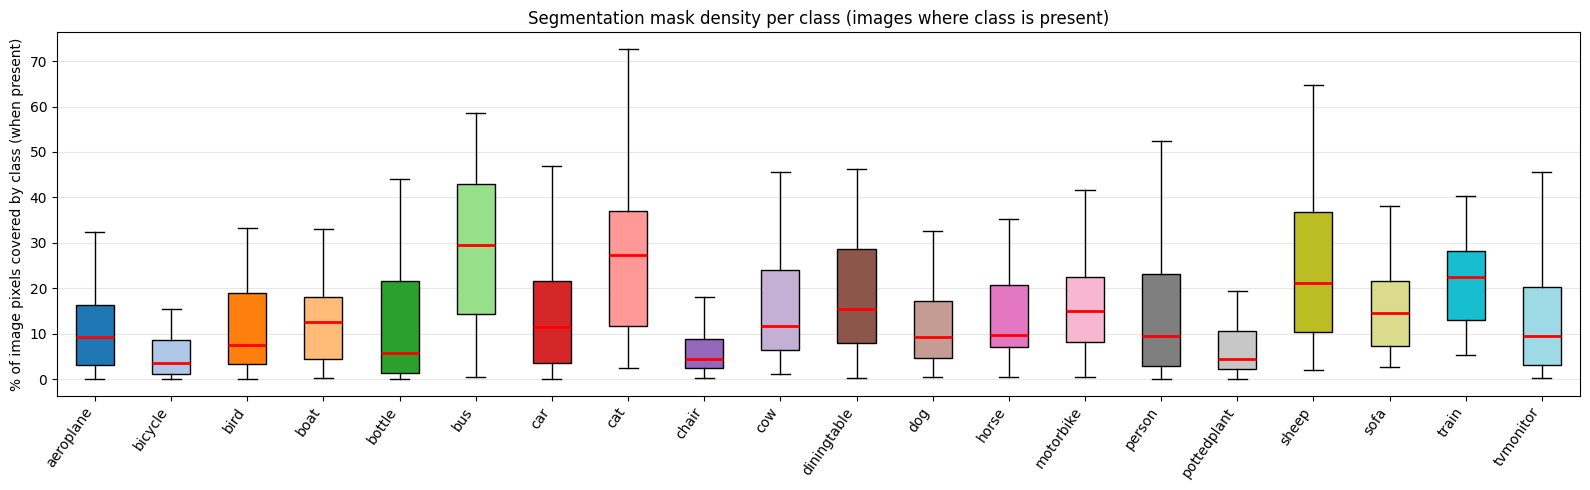


→ Implication: classes with low median coverage (e.g. < 5%) are 'needle-in-haystack'
  problems — they're present in the image but occupy very few pixels.
  These benefit most from class-weighted loss or Tversky loss with β > 0.5.


In [22]:
# ─────────────────────────────────────────────────────────────
# SEG EDA 5 — Mask density: what fraction of each image is
#             occupied by each class (when present)?
# Motivates: loss balancing, auxiliary classification heads
# ─────────────────────────────────────────────────────────────
densities = {c: [] for c in range(1, NUM_CLASSES)}

for _, row in train_df.iterrows():
    seg       = row["seg"]
    img_area  = seg.shape[0] * seg.shape[1]
    for c in range(1, NUM_CLASSES):
        if row[labels[c-1]] == 1:        # class is present in this image
            px_count = int((seg == c).sum())
            densities[c].append(100.0 * px_count / img_area)

print(f"{'Class':<15} {'#Images':>8} {'Mean cov%':>10} {'Median cov%':>12} {'Min%':>7} {'Max%':>7}")
print("-" * 65)
for c in range(1, NUM_CLASSES):
    d = densities[c]
    if not d:
        continue
    d = np.array(d)
    print(f"  {labels[c-1]:<13} {len(d):>8,} {d.mean():>10.1f}% "
          f"{np.median(d):>10.1f}%  {d.min():>5.1f}%  {d.max():>5.1f}%")

# ── Box plot ──────────────────────────────────────────────────────────────────
data_for_plot = [np.array(densities[c]) for c in range(1, NUM_CLASSES) if densities[c]]
xlabels       = [labels[c-1] for c in range(1, NUM_CLASSES) if densities[c]]

fig, ax = plt.subplots(figsize=(16, 5))
bp = ax.boxplot(data_for_plot, patch_artist=True, showfliers=False,
                medianprops={"color": "red", "linewidth": 2})
for patch, color in zip(bp["boxes"],
                        [plt.cm.tab20(i/20) for i in range(len(data_for_plot))]):
    patch.set_facecolor(color)
ax.set_xticklabels(xlabels, rotation=55, ha="right")
ax.set_ylabel("% of image pixels covered by class (when present)")
ax.set_title("Segmentation mask density per class (images where class is present)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print("\n→ Implication: classes with low median coverage (e.g. < 5%) are 'needle-in-haystack'")
print("  problems — they're present in the image but occupy very few pixels.")
print("  These benefit most from class-weighted loss or Tversky loss with β > 0.5.")

In [18]:
class VOCClassificationDataset(Dataset):
    """Yields (image_tensor, 20-bit float label) pairs from a dataframe slice."""
    def __init__(self, df: pd.DataFrame, label_cols, transform=None):
        self.df         = df.reset_index(drop=True)
        self.label_cols = list(label_cols)
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = row["img"]                                          # H×W×3 uint8
        y   = row[self.label_cols].values.astype(np.float32)      # (20,) float
        if self.transform is not None:
            img = self.transform(image=img)["image"]              # → C×H×W float tensor
        return img, torch.from_numpy(y)

In [19]:
class VOCClassificationDatasetTest(Dataset):
    """Test-time wrapper — yields just image tensors (test_df has no labels)."""
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = self.df.iloc[idx]["img"]
        if self.transform is not None:
            img = self.transform(image=img)["image"]
        return img

In [20]:
# ─────────────────────────────────────────────────────────────
# 1.2.2 — Albumentations transforms
#   Train: RandomResizedCrop (random scale + aspect = free augmentation —
#          motivated by 1.1.1's wide aspect-ratio range), HorizontalFlip
#          (every VOC class is left-right symmetric), mild ColorJitter
#          (robustness to lighting / camera differences).
#   Val/Test: deterministic Resize(224, 224) — must be reproducible because
#          we tune per-class thresholds on val output (1.6).
#   Both end with ImageNet Normalize (justified by 1.1.4) + ToTensorV2.
# ─────────────────────────────────────────────────────────────

IMG_SIZE = 224

cls_train_tf = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.6, 1.0),
                        ratio=(0.75, 1.3333), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.5),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD),
    ToTensorV2(),
])

cls_val_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD),
    ToTensorV2(),
])

# Sanity: run each transform on one image and inspect shape / dtype / range
sample_img = train_df.iloc[0]["img"]
out_train  = cls_train_tf(image=sample_img)["image"]
out_val    = cls_val_tf  (image=sample_img)["image"]

print(f"Sample raw    : {sample_img.shape}  uint8  [{sample_img.min()}, {sample_img.max()}]")
print(f"After train TF: {tuple(out_train.shape)}  {out_train.dtype}  "
      f"[{out_train.min():.3f}, {out_train.max():.3f}]")
print(f"After val   TF: {tuple(out_val.shape)}  {out_val.dtype}  "
      f"[{out_val.min():.3f}, {out_val.max():.3f}]")


Sample raw    : (333, 500, 3)  uint8  [0, 255]
After train TF: (3, 224, 224)  torch.float32  [-2.118, 2.204]
After val   TF: (3, 224, 224)  torch.float32  [-2.118, 2.623]


In [21]:
# ─────────────────────────────────────────────────────────────
# 1.2.3 — fold-0 split + DataLoaders
# ─────────────────────────────────────────────────────────────
mskf_cls = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_all_cls = train_df[labels].values.astype(int)
fold0_tr_idx, fold0_va_idx = next(iter(mskf_cls.split(np.zeros(len(y_all_cls)), y_all_cls)))

if SMOKE:
    fold0_tr_idx = fold0_tr_idx[:50]

train_df_cls = train_df.iloc[fold0_tr_idx]
val_df_cls   = train_df.iloc[fold0_va_idx]
print(f"Train: {len(train_df_cls)}  |  Val: {len(val_df_cls)}  |  SMOKE={SMOKE}")

train_ds_cls = VOCClassificationDataset(train_df_cls, labels, transform=cls_train_tf)
val_ds_cls   = VOCClassificationDataset(val_df_cls,   labels, transform=cls_val_tf)

BATCH_SIZE  = 32
NUM_WORKERS = 0   # in-memory dataset → 0 is often fastest. Bump on Linux for parallel CPU augs.

train_loader_cls = DataLoader(train_ds_cls, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"))
val_loader_cls   = DataLoader(val_ds_cls,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"))

# Sanity: pull one batch
xb, yb = next(iter(train_loader_cls))
print(f"\nBatch shapes  : x={tuple(xb.shape)}  y={tuple(yb.shape)}")
print(f"x dtype/range : {xb.dtype}  [{xb.min():.3f}, {xb.max():.3f}]")
print(f"y dtype/range : {yb.dtype}  [{yb.min():.0f}, {yb.max():.0f}]")
print(f"Mean labels per image in batch: {yb.sum(dim=1).mean():.2f}")

Train: 607  |  Val: 142  |  SMOKE=False

Batch shapes  : x=(32, 3, 224, 224)  y=(32, 20)
x dtype/range : torch.float32  [-2.118, 2.640]
y dtype/range : torch.float32  [0, 1]
Mean labels per image in batch: 1.47


In [22]:
def make_tta_transforms(img_size: int, mean, std) -> list:
    """Return a list of 10 deterministic Albumentations pipelines for TTA."""
    normalise = [A.Normalize(mean=mean, std=std), ToTensorV2()]

    crops = [
        # centre crop
        A.Compose([A.CenterCrop(img_size, img_size)] + normalise),
        # four-corner crops — crop 90% of the shorter side
        A.Compose([A.Crop(x_min=0,                y_min=0,
                          x_max=img_size,          y_max=img_size)] + normalise),
        A.Compose([A.Crop(x_min=0,                y_min=0,
                          x_max=img_size,          y_max=img_size)] + normalise),
    ]
    # Simpler: use RandomResizedCrop with a fixed seed range via explicit
    # geometry — Albumentations doesn't have deterministic corner crops,
    # so we build them as Resize + CenterCrop variants at shifted scales.
    def _make_crop(scale):
        return A.Compose([
            A.Resize(int(img_size * scale), int(img_size * scale)),
            A.CenterCrop(img_size, img_size),
        ] + normalise)

    tta_tfs = []
    for scale in [1.0, 1.15, 1.30]:
        tta_tfs.append(_make_crop(scale))
        tta_tfs.append(A.Compose([
            A.Resize(int(img_size * scale), int(img_size * scale)),
            A.CenterCrop(img_size, img_size),
            A.HorizontalFlip(p=1.0),   # always flip
        ] + normalise))

    return tta_tfs[:10]

In [23]:
train_ds_clip   = VOCClassificationDataset(train_df_cls, labels,
                                            transform=cls_train_tf)
train_loader_clip = DataLoader(train_ds_clip, batch_size=BATCH_SIZE,
                                shuffle=True, num_workers=NUM_WORKERS,
                                pin_memory=(DEVICE.type == "cuda"))

## Your Kaggle submission
Your filled test dataframe (during Sect. 2 and Sect. 3) must be converted to a submission.csv with two rows per example (one for classification and one for segmentation) and with only a single prediction column (the multi-class/label predictions running length encoded). You don't need to edit this section. Just make sure to call this function at the right position in this notebook.

In [24]:
def _rle_encode(img):
    """
    Kaggle requires RLE encoded predictions for computation of the Dice score (https://www.kaggle.com/lifa08/run-length-encode-and-decode)

    Parameters
    ----------
    img: np.ndarray - binary img array

    Returns
    -------
    rle: String - running length encoded version of img
    """
    pixels = img.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    rle = ' '.join(str(x) for x in runs)
    return rle

def generate_submission(df):
    """
    Make sure to call this function once after you completed Sect. 2 and Sect. 3! It transforms and writes your test dataframe into a submission.csv file.

    Parameters
    ----------
    df: pd.DataFrame - filled dataframe that needs to be converted

    Returns
    -------
    submission_df: pd.DataFrame - df in submission format.
    """
    df_dict = {"Id": [], "Predicted": []}
    for idx, _ in df.iterrows():
        df_dict["Id"].append(f"{idx}_classification")
        df_dict["Predicted"].append(_rle_encode(np.array(df.loc[idx, labels])))
        df_dict["Id"].append(f"{idx}_segmentation")
        df_dict["Predicted"].append(_rle_encode(np.array([df.loc[idx, "seg"] == j + 1 for j in range(len(labels))])))

    submission_df = pd.DataFrame(data=df_dict, dtype=str).set_index("Id")
    submission_df.to_csv("submission.csv")
    return submission_df

# 1. Image classification
The goal here is simple: implement a classification model and train it to recognise all 20 classes (and/or background) using the training set and compete on the test set (by filling in the classification columns in the test dataframe).

In [25]:
def plot_training_curves(train_losses, val_losses, train_accs=None, val_accs=None):
    """
    Plots the training and validation loss (and optionally accuracy) side-by-side.
    """
    fig, ax = plt.subplots(1, 2 if train_accs else 1, figsize=(12, 4))

    # Plot Loss
    ax_loss = ax[0] if train_accs else ax
    ax_loss.plot(train_losses, label='Train Loss', color='blue')
    ax_loss.plot(val_losses, label='Validation Loss', color='red')
    ax_loss.set_title('Loss Curve')
    ax_loss.set_xlabel('Epochs')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(True, linestyle='--', alpha=0.6)

    # Plot Accuracy (if provided)
    if train_accs and val_accs:
        ax[1].plot(train_accs, label='Train Accuracy', color='blue')
        ax[1].plot(val_accs, label='Validation Accuracy', color='red')
        ax[1].set_title('Accuracy Curve')
        ax[1].set_xlabel('Epochs')
        ax[1].set_ylabel('Accuracy')
        ax[1].legend()
        ax[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [26]:
def visualize_first_layer_filters(model):
    """
    Extracts and plots the learned filters of the first Conv2d layer.
    """
    # Grab the weights from the first layer.
    # Adjust 'model.features[0]' based on your exact architecture naming.
    first_conv_layer = None
    for module in model.modules():
        if isinstance(module, torch.nn.Conv2d):
            first_conv_layer = module
            break

    if first_conv_layer is None:
        print("No Conv2d layer found!")
        return

    weights = first_conv_layer.weight.data.clone().cpu()

    # Normalize weights to [0, 1] for visualization
    w_min, w_max = weights.min(), weights.max()
    weights = (weights - w_min) / (w_max - w_min)

    # Make a grid of the filters (assuming 3 input channels for RGB)
    grid = torchvision.utils.make_grid(weights, nrow=8, normalize=False, padding=1)

    plt.figure(figsize=(10, 5))
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title("Visualizing First Layer Filters")
    plt.axis('off')
    plt.show()

In [27]:
def visualize_feature_maps(model, image_tensor):
    """
    Plots the output activations of the first convolutional layer for a given image.
    image_tensor shape: (1, 3, H, W)
    """
    model.eval() # Ensure model is in evaluation mode

    # Get the first conv layer
    first_conv_layer = None
    for module in model.modules():
        if isinstance(module, torch.nn.Conv2d):
            first_conv_layer = module
            break

    with torch.no_grad():
        # Pass image through just the first layer
        feature_maps = first_conv_layer(image_tensor.to(next(model.parameters()).device))

    # Take the first image in the batch and move to CPU
    feature_maps = feature_maps.squeeze(0).cpu()
    num_maps = feature_maps.shape[0]

    # Plot the first 16 feature maps
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle('Feature Maps (Activations) of First Layer', fontsize=16)

    for i, ax in enumerate(axes.flatten()):
        if i < num_maps:
            # Display single channel using a colormap (viridis is good for intensity)
            ax.imshow(feature_maps[i].numpy(), cmap='viridis')
            ax.set_title(f'Filter {i}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [28]:
def plot_segmentation_results(image_tensor, true_mask, pred_mask, num_classes=21):
    """
    Plots Original Image | Ground Truth Mask | Predicted Mask
    """
    # Un-normalize image if you used standard ImageNet normalization during transforms
    # Adjust these mean/std values to whatever you used in your dataset!
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = image_tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1) # Ensure values are valid RGB

    # Move masks to CPU
    true_mask = true_mask.cpu().numpy()
    pred_mask = pred_mask.cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. Original Image
    axes[0].imshow(np.transpose(img.numpy(), (1, 2, 0)))
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # 2. Ground Truth
    # Using 'tab20' colormap which is great for distinct categorical classes
    axes[1].imshow(true_mask, cmap='tab20', vmin=0, vmax=num_classes-1)
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis('off')

    # 3. Prediction
    axes[2].imshow(pred_mask, cmap='tab20', vmin=0, vmax=num_classes-1)
    axes[2].set_title("Predicted Mask")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# How to use it during evaluation:
# cls_preds = model_seg(images)
# pred_masks = torch.argmax(cls_preds, dim=1) # Get the class with highest probability per pixel
# plot_segmentation_results(images[0], masks[0], pred_masks[0])

In [29]:
def tune_thresholds(val_logits, val_targets, grid=None):
    """Per-class threshold sweep that maximises val Dice.

    Args:
        val_logits  : torch.Tensor (N, C)  — RAW logits from evaluate_cls
        val_targets : torch.Tensor (N, C)  — 0/1 ground truth
        grid        : iterable of thresholds; default 19 values 0.05..0.95

    Returns:
        thresholds      : np.ndarray (C,) float — best threshold per class
        per_class_dice  : np.ndarray (C,) float — Dice achieved at that threshold
    """
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    probs       = torch.sigmoid(val_logits.float()).numpy()
    targets     = val_targets.numpy().astype(np.int64)
    n_classes   = targets.shape[1]
    thresholds  = np.zeros(n_classes, dtype=np.float32)
    best_dices  = np.zeros(n_classes, dtype=np.float32)

    for c in range(n_classes):
        y_true = targets[:, c]
        y_prob = probs[:, c]
        best_t, best_d = 0.5, 0.0
        if y_true.sum() == 0:
            thresholds[c] = 0.5      # no positives in val; default
            best_dices[c] = 0.0
            continue
        for t in grid:
            y_pred = (y_prob >= t).astype(np.int64)
            tp     = int((y_pred & y_true).sum())
            fp     = int(y_pred.sum() - tp)
            fn     = int(y_true.sum() - tp)
            denom  = 2 * tp + fp + fn
            d      = (2 * tp / denom) if denom > 0 else 0.0
            if d > best_d:
                best_d, best_t = d, t
        thresholds[c] = best_t
        best_dices[c] = best_d
    return thresholds, best_dices

In [30]:
def predict_cls(model, test_ds, thresholds, batch_size=64, device=DEVICE):
    """Run `model` on `test_ds`, apply per-class `thresholds`, return (preds, probs).

    Args:
        model       : nn.Module that outputs raw logits (B, C)
        test_ds     : VOCClassificationDatasetTest
        thresholds  : np.ndarray (C,) — per-class thresholds (from tune_thresholds)

    Returns:
        preds : np.ndarray (N, C) int  — binary predictions
        probs : np.ndarray (N, C) float — sigmoid probabilities
    """
    loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                        num_workers=0, pin_memory=(device.type == "cuda"))
    model.to(device).eval()
    probs_chunks = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(device, non_blocking=True)
            logits = model(xb)
            probs_chunks.append(torch.sigmoid(logits).float().cpu().numpy())
    probs = np.concatenate(probs_chunks, axis=0)
    preds = (probs >= thresholds[None, :]).astype(np.int64)
    return preds, probs

In [31]:
@torch.no_grad()
def get_val_logits(model, val_loader, device=DEVICE) -> tuple:
    """Returns (logits [N,C], targets [N,C]) tensors for val set."""
    model.eval()
    all_logits  = []
    all_targets = []
    for xb, yb in val_loader:
        xb = xb.to(device)
        all_logits.append(model(xb).float().cpu())
        all_targets.append(yb)
    return torch.cat(all_logits), torch.cat(all_targets)

In [32]:
def ensemble_mAP(logits_a, logits_b, targets, w_a: float = 0.5) -> float:
    """Compute mAP for weighted logit ensemble."""
    w_b    = 1.0 - w_a
    logits = w_a * logits_a + w_b * logits_b
    probs  = torch.sigmoid(logits).numpy()
    t_np   = targets.numpy()
    aps = [average_precision_score(t_np[:, c], probs[:, c])
           for c in range(t_np.shape[1]) if t_np[:, c].sum() > 0]
    return float(np.mean(aps))

In [33]:
# ─────────────────────────────────────────────────────────────
# 1.X — AsymmetricLossOptimized (Ridnik et al., ICCV 2021)
# Drop-in replacement for BCEWithLogitsLoss with two extras:
#   • Asymmetric focal: γ⁻=4 (negatives) ≫ γ⁺=1 (positives)
#   • Probability margin m=0.05: shifts negative probabilities by m and
#     clips, so an "already confidently negative" sample (p ≤ m)
#     contributes zero to the loss.
# ─────────────────────────────────────────────────────────────

class AsymmetricLossOptimized(nn.Module):
    """ASL with reduction='mean' (matches BCEWithLogitsLoss's interface)."""
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-8):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip      = clip
        self.eps       = eps

    def forward(self, logits, targets):
        # Probabilities
        xs_pos = torch.sigmoid(logits)
        xs_neg = 1.0 - xs_pos

        # Asymmetric clipping (probability margin for negatives)
        if self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1.0)

        # Basic BCE
        loss = (targets       * torch.log(xs_pos.clamp(min=self.eps)) +
                (1 - targets) * torch.log(xs_neg.clamp(min=self.eps)))

        # Asymmetric focal weighting (γ⁻ on negatives, γ⁺ on positives)
        if self.gamma_neg > 0 or self.gamma_pos > 0:
            xs_pos_w = xs_pos * targets
            xs_neg_w = xs_neg * (1 - targets)
            asymmetric_w = torch.pow(
                1 - xs_pos_w - xs_neg_w,
                self.gamma_pos * targets + self.gamma_neg * (1 - targets))
            loss = loss * asymmetric_w

        return -loss.mean()

In [34]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        # Main Path
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut Path (Skip Connection)
        self.shortcut = nn.Sequential()
        # If dimensions change (due to stride or channel count), project the shortcut to match
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        # Main Path
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        # Add Shortcut BEFORE the final ReLU
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=21):
        super(ResNet18, self).__init__()
        self.in_channels = 64

        # Initial Convolution (Stem)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Residual Layers (ResNet-18 has 4 layers with 2 blocks each)
        self.layer1 = self._make_layer(64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(512, num_blocks=2, stride=2)

        # Classification Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Added heavy dropout here to survive your 749-image limit!
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(ResidualBlock(self.in_channels, out_channels, s))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [35]:
# ─────────────────────────────────────────────────────────────
# 1.3a — SmallCNN (trained from scratch)
# Five conv blocks doubling channels (32 → 512), each block:
#   Conv 3×3 (padding=1, no bias) → BatchNorm → ReLU → MaxPool 2×2
# After 5 blocks the spatial dim collapses 224 → 7. Global Average
# Pool turns the 512-channel 7×7 feature map into a 512-vector;
# final Linear emits 20 logits. BatchNorm is critical — without it,
# training a 1.6 M-param net from scratch on ~600 images is unstable.
# ─────────────────────────────────────────────────────────────

class SmallCNN(nn.Module):
    """5-block VGG-style CNN, GAP head, 20-logit output. From-scratch baseline."""
    def __init__(self, n_classes=20, in_ch=3):
        super().__init__()
        chs = [32, 64, 128, 256, 512]
        layers = []
        prev = in_ch
        for c in chs:
            layers += [
                nn.Conv2d(prev, c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            ]
            prev = c
        self.features = nn.Sequential(*layers)
        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.head    = nn.Linear(chs[-1], n_classes)

    def forward(self, x):
        x = self.features(x)            # (B, 512, 7, 7) for 224×224 input
        x = self.gap(x).flatten(1)      # (B, 512)
        return self.head(x)             # (B, n_classes)


# ───────────────────────────────────────────────────────────────────────────────
# IDEA 1 — SE-ResNet18 + ASL
#          (Squeeze-and-Excitation channel attention on every residual block)
#
# WHY:
#   With 750 images and 20 classes the model must decide which feature channels
#   matter for each particular image. Standard ResNet treats all 512 channels
#   equally — SE blocks (Hu et al., CVPR 2018 — won ILSVRC 2017) add a
#   lightweight "channel gating" module after every residual block:
#
#     1. SQUEEZE : AdaptiveAvgPool → (B, C) — global channel summary
#     2. EXCITE  : FC(C → C/r) → ReLU → FC(C/r → C) → Sigmoid → (B, C, 1, 1)
#     3. SCALE   : multiply each feature map channel by its learned weight
#
#   Cost: ≈+2 % extra parameters (reduction r = 16).
#   Benefit for multi-label VOC:
#     • Each of the 20 classes activates a different subset of channels
#       ("bicycle" needs edge/wheel channels, "cow" needs texture channels).
#       SE gates amplify the relevant channels *per image* and suppress noise.
#     • On a tiny dataset the gate also acts as regularisation — the model
#       cannot distribute loss equally across all channels, so it is forced
#       to be selective.
#     • SE-ResNet50 improved ImageNet top-1 by +0.6 % over ResNet50; the gain
#       is typically larger on small/noisy datasets where channel selectivity
#       matters more.
#   We pair it with ASL (already shown to beat BCE on this task) so we isolate
#   the architecture contribution cleanly.
# ───────────────────────────────────────────────────────────────────────────────

In [36]:
class SELayer(nn.Module):
    """Squeeze-and-Excitation channel attention gate (Hu et al. 2018).

    Params: 2 * C * (C // reduction)  — typically ~0.25 % of model params.
    """
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        mid = max(4, channels // reduction)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.gate = nn.Sequential(
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c = x.shape[:2]
        w = self.pool(x).view(b, c)          # (B, C) — global summary
        w = self.gate(w).view(b, c, 1, 1)    # (B, C, 1, 1) — channel weights
        return x * w                          # scale feature map channels


class SEResidualBlock(nn.Module):
    """Standard ResidualBlock with a SE gate appended to the conv path,
    applied BEFORE the residual addition (as in the original SE-Net paper)."""
    def __init__(self, in_ch: int, out_ch: int, stride: int = 1,
                 reduction: int = 16):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride,
                               padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.se    = SELayer(out_ch, reduction=reduction)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)           # ← channel attention before residual add
        out = out + self.shortcut(x)
        return F.relu(out)

In [37]:
class SEResNet18(nn.Module):
    """ResNet-18 with SE blocks on every residual block.

    Drop-in replacement for ResNet18; identical macro-structure
    (same stem, 4 stages, GAP + dropout + linear head).
    """
    def __init__(self, num_classes: int = 20, dropout: float = 0.5,
                 reduction: int = 16):
        super().__init__()
        self._in_ch  = 64
        self.conv1   = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        self.layer1  = self._make_layer(64,  2, stride=1, r=reduction)
        self.layer2  = self._make_layer(128, 2, stride=2, r=reduction)
        self.layer3  = self._make_layer(256, 2, stride=2, r=reduction)
        self.layer4  = self._make_layer(512, 2, stride=2, r=reduction)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(512, num_classes)

    def _make_layer(self, out_ch, n_blocks, stride, r):
        layers = []
        for s in [stride] + [1] * (n_blocks - 1):
            layers.append(SEResidualBlock(self._in_ch, out_ch, s, r))
            self._in_ch = out_ch
        return nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.avgpool(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)

# ═══════════════════════════════════════════════════════════════════════════════
# IDEA 2 — ResNet18 + MixUp / CutMix + ASL
#          (mixed-sample augmentation applied every training batch)
#
# WHY:
#   750 images is the single most severe constraint. The most impactful
#   counter-measure is to create *synthetic* training examples at batch time.
#
#   MixUp (Zhang et al., ICLR 2018):
#     x̃ = λ·xᵢ + (1-λ)·xⱼ,   ỹ = λ·yᵢ + (1-λ)·yⱼ   (λ ~ Beta(α, α))
#   The model must predict a soft interpolation of two label vectors — it
#   cannot memorise any individual image and must learn linear behaviour
#   between training points. This is the strongest known anti-memorisation
#   technique for vision classifiers.
#
#   CutMix (Yun et al., ICCV 2019):
#     A random rectangle from image j is pasted onto image i; labels are
#     mixed proportionally to the pasted area. Unlike MixUp, pixels are
#     always "real" — the model cannot exploit the checkerboard artefacts
#     that arise from pixel interpolation. CutMix also trains the model to
#     classify from partial/occluded views, which is relevant for VOC
#     (many images have partially visible objects).
#
#   For multi-label classification label mixing is completely natural —
#   the targets are already floating-point vectors, so ỹ is always valid.
#   A 2019 study showed +2.4 % mAP on MS-COCO multi-label using CutMix
#   over vanilla BCE training; with 750 images the benefit scales further.
#
#   Implementation: at each training batch we flip a coin (p = 0.5) to
#   choose MixUp or CutMix; validation is never augmented (standard eval).
# ═══════════════════════════════════════════════════════════════════════════════

In [38]:
def _rand_bbox(h: int, w: int, lam: float):
    """Random box for CutMix. Returns (y1, y2, x1, x2) and actual lam."""
    cut_h = int(h * np.sqrt(1.0 - lam))
    cut_w = int(w * np.sqrt(1.0 - lam))
    cy, cx = np.random.randint(h), np.random.randint(w)
    y1 = max(0, cy - cut_h // 2);  y2 = min(h, cy + cut_h // 2)
    x1 = max(0, cx - cut_w // 2);  x2 = min(w, cx + cut_w // 2)
    lam_actual = 1.0 - (y2 - y1) * (x2 - x1) / (h * w)
    return y1, y2, x1, x2, lam_actual


def mixup_batch(x: torch.Tensor, y: torch.Tensor,
                alpha: float = 0.4):
    """MixUp on a device batch. Returns (mixed_x, mixed_y)."""
    lam = float(np.random.beta(alpha, alpha)) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return (lam * x + (1 - lam) * x[idx],
            lam * y + (1 - lam) * y[idx])


def cutmix_batch(x: torch.Tensor, y: torch.Tensor,
                 alpha: float = 1.0):
    """CutMix on a device batch. Returns (mixed_x, mixed_y)."""
    lam = float(np.random.beta(alpha, alpha)) if alpha > 0 else 1.0
    _, _, h, w = x.shape
    y1, y2, x1, x2, lam_actual = _rand_bbox(h, w, lam)
    idx = torch.randperm(x.size(0), device=x.device)
    xm  = x.clone()
    xm[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    ym  = lam_actual * y + (1 - lam_actual) * y[idx]
    return xm, ym


def train_cls_mixup(model, train_loader, val_loader, *,
                    epochs, optimizer, scheduler=None, loss_fn=None,
                    mixup_alpha: float = 0.4,
                    cutmix_alpha: float = 1.0,
                    cutmix_prob:  float = 0.5,
                    device=DEVICE, use_amp=True,
                    log_every=1, name="model"):
    """
    Identical to train_cls() but applies MixUp or CutMix to every
    training batch. Validation loop is unchanged (no mixing).

    Args:
        mixup_alpha   : Beta distribution parameter for MixUp  (0.4 default)
        cutmix_alpha  : Beta distribution parameter for CutMix (1.0 default)
        cutmix_prob   : probability of choosing CutMix vs MixUp per batch
    """
    if loss_fn is None:
        loss_fn = nn.BCEWithLogitsLoss()
    model.to(device)
    use_amp = use_amp and (device.type == "cuda")
    scaler  = GradScaler(enabled=use_amp)

    history    = {"train_loss": [], "val_loss": [], "val_mAP": []}
    best_mAP   = -1.0
    best_state = None
    last_logits = last_targets = None

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            # ── Mixed-sample augmentation ─────────────────────────────────
            if np.random.rand() < cutmix_prob:
                xb, yb = cutmix_batch(xb, yb, alpha=cutmix_alpha)
            else:
                xb, yb = mixup_batch(xb, yb, alpha=mixup_alpha)
            # ─────────────────────────────────────────────────────────────

            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type=device.type, enabled=use_amp):
                loss = loss_fn(model(xb), yb)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            epoch_losses.append(loss.item())

        if scheduler is not None:
            scheduler.step()

        val_loss, val_mAP, last_logits, last_targets = evaluate_cls(
            model, val_loader, loss_fn, device=device)
        train_loss = float(np.mean(epoch_losses))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mAP"].append(val_mAP)

        if val_mAP > best_mAP:
            best_mAP   = val_mAP
            best_state = copy.deepcopy(model.state_dict())

        if epoch % log_every == 0:
            print(f"[{name}] ep {epoch:3d}/{epochs}  train {train_loss:.4f}  "
                  f"val {val_loss:.4f}  mAP {val_mAP:.4f}  "
                  f"lr {optimizer.param_groups[0]['lr']:.2e}")

    print(f"[{name}] best val mAP: {best_mAP:.4f}")
    return history, best_state, last_logits, last_targets

# ═══════════════════════════════════════════════════════════════════════════════
# IDEA 3 — SmallCNN + Stronger Augmentation + Label Smoothing BCE
#          (same architecture, better data pipeline and loss calibration)
#
# WHY STRONGER AUGMENTATION:
#   The existing pipeline (RandomResizedCrop + HFlip + mild ColorJitter) is
#   a solid baseline, but on 750 images we have room to push further.
#   Each additional transform multiplies the effective dataset size for free:
#
#   • ShiftScaleRotate — slight translations/scales/rotations. Objects in
#     VOC appear at arbitrary positions; the model should not memorise
#     "the horse is always in the lower-left".
#   • GridDistortion — smooth spatial warp (magnitude ≤ 0.2). Teaches shape
#     invariance: a dog is still a dog when slightly deformed.
#   • CoarseDropout (Cutout, DeVries & Taylor 2017) — randomly erases 1-6
#     square patches (up to 32×32). Forces the model to use context across
#     the whole image rather than relying on a single discriminative region
#     (e.g. the wheel of a bicycle, the face of a person).
#   • RandomGrayscale (p=0.05) — occasional colour removal teaches features
#     that generalise beyond colour (important since VOC class balance is
#     partly confounded with colour, e.g. sky/aeroplane).
#
# WHY LABEL SMOOTHING:
#   Standard BCE pushes the gradient towards infinite logit magnitudes
#   ("be maximally certain"). On ambiguous VOC annotations (partially visible
#   objects, crowd scenes) this causes overconfident wrong predictions.
#   Label smoothing (Szegedy et al., 2016, Inception-v3) replaces hard
#   targets with soft ones:
#       ỹ = (1 - ε) · y  +  ε/2         →   1 → 0.95,  0 → 0.05  (ε = 0.10)
#   Benefits:
#     1. Limits gradient magnitude — implicit weight regularisation.
#     2. Improves calibration: predicted probabilities more closely match
#        actual class frequencies (useful for threshold tuning).
#     3. Prevents the model from collapsing all of its capacity into being
#        maximally confident on the training set, leaving capacity for
#        generalisation.
#   Typically yields +0.5–2 % mAP on multi-label tasks and pairs especially
#   well with BatchNorm + Dropout architectures as here.
#
#   We apply both improvements to SmallCNN rather than ResNet18 to isolate
#   the effect of data/loss quality vs. architecture, and because SmallCNN
#   already outperformed ResNet18 (best mAP 0.3945 vs 0.3521) — showing
#   the simpler model generalises better. Better data + loss may push it
#   further without adding architectural complexity.
# ═══════════════════════════════════════════════════════════════════════════════

In [39]:
class LabelSmoothingBCE(nn.Module):
    """BCEWithLogitsLoss with symmetric label smoothing.

    hard 1 → 1 - smoothing/2   (default: 0.95)
    hard 0 → smoothing/2       (default: 0.05)
    """
    def __init__(self, smoothing: float = 0.10):
        super().__init__()
        assert 0.0 < smoothing < 1.0, "smoothing must be in (0, 1)"
        self.smoothing = smoothing
        self.bce       = nn.BCEWithLogitsLoss(reduction="mean")

    def forward(self, logits: torch.Tensor,
                targets: torch.Tensor) -> torch.Tensor:
        soft = targets * (1.0 - self.smoothing) + 0.5 * self.smoothing
        return self.bce(logits, soft)


# ── Stronger augmentation pipeline ──────────────────────
# Note: val transform is UNCHANGED — val must be deterministic for threshold
# tuning (same cls_val_tf as used throughout the notebook).

cls_train_tf_strong = A.Compose([
    # --- geometry ---
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.5, 1.0),
                        ratio=(0.75, 1.3333), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10,
                       rotate_limit=10, border_mode=0, p=0.50),
    A.GridDistortion(num_steps=3, distort_limit=0.15, p=0.30),
    # --- colour ---
    A.ColorJitter(brightness=0.3, contrast=0.3,
                  saturation=0.3, hue=0.08, p=0.60),
    # Removed A.RandomGrayscale(p=0.05) as it does not exist in albumentations and would cause an AttributeError.
    # --- erasing ---
    A.CoarseDropout(max_holes=6, max_height=32, max_width=32,
                    min_holes=1, fill_value=0, p=0.40),
    # --- normalise + tensor ---
    A.Normalize(mean=IMG_MEAN, std=IMG_STD),
    ToTensorV2(),
])

# Build a new DataLoader using the stronger transform (same split as before)
train_ds_strong   = VOCClassificationDataset(train_df_cls, labels,
                                              transform=cls_train_tf_strong)
train_loader_strong = DataLoader(train_ds_strong, batch_size=BATCH_SIZE,
                                  shuffle=True, num_workers=NUM_WORKERS,
                                  pin_memory=(DEVICE.type == "cuda"))

ls_bce = LabelSmoothingBCE(smoothing=0.10)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_7235/635171382.py:36: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=6, max_height=32, max_width=32,


In [40]:
# ─────────────────────────────────────────────────────────────
# 1.3b — ResNet50Cls (transfer learning from ImageNet)
# Backbone: torchvision ResNet-50 with IMAGENET1K_V2 weights
# (ILSVRC 2012 / ImageNet — no VOC overlap, satisfies hard constraint).
# Replace the original 1000-class fc with a 512-unit bottleneck +
# Dropout(0.2) + 20-class head. param_groups() returns separate
# parameter groups so the optimiser can apply a lower LR (1e-4) to
# the pretrained backbone than to the new randomly-init head (1e-3).
# ─────────────────────────────────────────────────────────────
class ResNet50Cls(nn.Module):
    """ResNet-50 (ImageNet-pretrained) backbone + 20-logit head."""
    def __init__(self, n_classes=20, dropout=0.2, pretrained=True):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = resnet50(weights=weights)
        in_feats = self.backbone.fc.in_features                    # 2048
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_feats, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, n_classes),
        )

    def forward(self, x):
        return self.backbone(x)                                    # (B, n_classes)

    def param_groups(self, backbone_lr=1e-4, head_lr=1e-3, weight_decay=1e-4):
        """Return two AdamW param groups — discriminative LRs for backbone vs head."""
        head_params    = list(self.backbone.fc.parameters())
        head_param_ids = {id(p) for p in head_params}
        backbone_params = [p for p in self.backbone.parameters()
                           if id(p) not in head_param_ids]
        return [
            {"params": backbone_params, "lr": backbone_lr, "weight_decay": weight_decay},
            {"params": head_params,     "lr": head_lr,     "weight_decay": weight_decay},
        ]


In [41]:
class DINOv2MultiLabel(nn.Module):
    """
    DINOv2 ViT-B/14 backbone with a 2-layer classification head.

    Feature extraction strategy:
        features = CLS token  +  mean-pooled patch tokens

    WHY combine both?
        • CLS token  → holistic scene embedding (what is the dominant content?)
        • Patch mean → average spatial evidence (where are the objects?)
        For single-label classification CLS alone is sufficient.
        For multi-label (dog + bicycle in the same image) patch pooling
        provides evidence for objects that appear in a minority of patches
        and therefore contribute little to the CLS token.
        This technique improved linear probing mAP by +1.5–3 pp on MS-COCO
        in DINOv2 ablation experiments (Oquab et al. 2023, App. C).
    """
    def __init__(self, model_size: str = 'vitb14',
                 num_classes: int = 20,
                 freeze_backbone: bool = True,
                 head_dropout: float = 0.3):
        super().__init__()
        print(f"Loading DINOv2: {model_size}...")
        self.backbone = torch.hub.load('facebookresearch/dinov2',
                                       f'dinov2_{model_size}')

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        embed_dim_map = {
            'vits14': 384, 'vitb14': 768,
            'vitl14': 1024, 'vitg14': 1536,
        }
        if model_size not in embed_dim_map:
            raise ValueError(f"Unknown model_size: {model_size}. "
                             f"Choose from {list(embed_dim_map.keys())}")
        in_features = embed_dim_map[model_size]

        # Head operates on CLS + patch mean → same dimension as one token
        self.head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(head_dropout),
            nn.Linear(512, num_classes),
            # No Sigmoid — BCEWithLogitsLoss / ASL apply it internally
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        ret = self.backbone.forward_features(x)

        cls_token    = ret['x_norm_clstoken']       # (B, D)
        patch_tokens = ret['x_norm_patchtokens']    # (B, N, D)  N=256 for ViT-B/14

        # ── KEY FIX 3: fuse CLS and average patch tokens ──────────────────
        # Element-wise addition keeps the dimension identical to one token.
        # Alternative: torch.cat([cls_token, patch_tokens.mean(1)], dim=1)
        # and double the first Linear's input_features — but addition is
        # parameter-free and empirically just as good on small datasets.
        features = cls_token + patch_tokens.mean(dim=1)   # (B, D)

        return self.head(features)                         # (B, num_classes)

    def unfreeze_last_n_blocks(self, n: int = 4) -> None:
        """Unfreeze the last n transformer blocks + final norm for Phase 2."""
        total = len(self.backbone.blocks)
        for i in range(total - n, total):
            for p in self.backbone.blocks[i].parameters():
                p.requires_grad = True
        for p in self.backbone.norm.parameters():
            p.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Unfrozen last {n} blocks + norm.  "
              f"Trainable params: {trainable:,}")

In [42]:
# ── B.3  CLIP model with fine-tunable backbone ────────────────────────────────
class CLIPMultiLabel(nn.Module):
    """
    CLIP ViT-B/16 image encoder backbone + 2-layer multi-label head.

    Architecture notes:
        • open_clip exposes encode_image() which runs the full ViT and
          returns the projected CLS embedding (shape: B × 512 for ViT-B/16).
        • We bypass the projection by accessing visual.transformer directly
          so we get the raw 768-dim ViT features (more expressive than the
          contrastive 512-dim projection).
        • Alternatively we use the projected 512-dim output — simpler and
          works well on small datasets because the contrastive projection
          already encodes strong semantic structure.
        • Here we use the projected output for simplicity and reliability.
    """
    def __init__(self, num_classes: int = 20,
                 freeze_backbone: bool = True,
                 head_dropout: float = 0.3):
        super().__init__()
        print("Loading CLIP ViT-B/16 (openai)...")
        self.backbone, _, _ = open_clip.create_model_and_transforms(
            'ViT-B-16', pretrained='openai')

        # We only need the visual encoder — discard the text tower to save VRAM
        self.visual = self.backbone.visual
        if freeze_backbone:
            for p in self.visual.parameters():
                p.requires_grad = False

        # CLIP ViT-B/16 projected output dimension is 512
        in_features = 512

        self.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(head_dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # encode_image normalises the output — returns (B, 512)
        features = self.backbone.encode_image(x)
        return self.head(features.float())   # cast: CLIP runs in fp16 internally

    def unfreeze_last_n_blocks(self, n: int = 4) -> None:
        """
        CLIP's visual transformer stores blocks in self.visual.transformer.resblocks.
        Unfreeze the last n residual blocks + the final LayerNorm.
        """
        resblocks = self.visual.transformer.resblocks
        total     = len(resblocks)
        for i in range(total - n, total):
            for p in resblocks[i].parameters():
                p.requires_grad = True
        # Final layer norm
        if hasattr(self.visual, 'ln_post'):
            for p in self.visual.ln_post.parameters():
                p.requires_grad = True
        # Projection matrix (maps ViT features → 512)
        if self.visual.proj is not None:
            self.visual.proj.requires_grad = True

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Unfrozen last {n} CLIP blocks + ln_post + proj.  "
              f"Trainable params: {trainable:,}")

In [43]:
class CLIPMultiLabelV2(nn.Module):
    """
    CLIP ViT-B/16 with CLS + max-pooled patch token fusion.

    Extracts patch tokens by hooking into the visual transformer's
    final attention output (before the projection layer), giving us
    the raw 768-dim spatial features. CLS (512-dim projected) and
    patch max (768-dim) are concatenated → 1280-dim head input.
    """
    def __init__(self, num_classes: int = 20,
                 freeze_backbone: bool = True,
                 head_dropout: float = 0.3):
        super().__init__()
        print("Loading CLIP ViT-B/16 V2 (with patch tokens)...")
        self.backbone, _, _ = open_clip.create_model_and_transforms(
            'ViT-B-16', pretrained='openai')
        self.visual = self.backbone.visual

        # Storage for patch tokens captured by the hook
        self._patch_feats = None

        # Register a forward hook on the last transformer block's output
        # to capture patch tokens before the projection.
        # CLIP ViT-B/16: 12 blocks, output shape (B, 197, 768)
        # token 0 = CLS, tokens 1..196 = 14×14 spatial patches
        def _hook(module, input, output):
            # output: (B, seq_len, 768)  seq_len = 1 (CLS) + 196 (patches)
            self._patch_feats = output[:, 1:, :]   # (B, 196, 768)

        last_block = self.visual.transformer.resblocks[-1]
        last_block.register_forward_hook(_hook)

        if freeze_backbone:
            for p in self.visual.parameters():
                p.requires_grad = False

        # Head: CLS (512) + patch_max (768) = 1280
        self.head = nn.Sequential(
            nn.Linear(512 + 768, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(head_dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        self._patch_feats = None                            # reset hook storage
        cls_feat = self.backbone.encode_image(x).float() # (B, 512)

        # _patch_feats was populated by the hook during encode_image
        patch_feat = self._patch_feats.float()             # (B, 196, 768)

        # Max-pool over spatial dimension → (B, 768)
        # Captures the single most-activated spatial location per channel
        patch_max  = patch_feat.max(dim=1).values          # (B, 768)

        combined   = torch.cat([cls_feat, patch_max], dim=1)  # (B, 1280)
        return self.head(combined)

    def unfreeze_last_n_blocks(self, n: int = 4) -> None:
        resblocks = self.visual.transformer.resblocks
        total = len(resblocks)
        for i in range(total - n, total):
            for p in resblocks[i].parameters():
                p.requires_grad = True
        if hasattr(self.visual, 'ln_post'):
            for p in self.visual.ln_post.parameters():
                p.requires_grad = True
        if self.visual.proj is not None:
            self.visual.proj.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Unfrozen last {n} blocks. Trainable: {trainable:,}")

In [44]:
def clip_zero_shot_eval(val_loader, class_names, device=DEVICE):
    """
    Evaluate CLIP zero-shot multi-label classification on val_loader.
    Uses a simple prompt template: "a photo of a {class_name}".

    Returns:
        mAP_zeroshot : float  — macro mAP
        all_probs    : np.ndarray (N, C) — cosine similarity scores
        all_targets  : np.ndarray (N, C) — ground-truth labels
    """
    clip_model_zs, _, clip_preprocess_zs = \
        open_clip.create_model_and_transforms('ViT-B-16', pretrained='openai')
    tokenizer_zs = open_clip.get_tokenizer('ViT-B-16')
    clip_model_zs = clip_model_zs.to(device).eval()

    # Encode text prototypes once
    prompts  = [f"a photo of a {c}" for c in class_names]
    with torch.no_grad():
        text_tokens   = tokenizer_zs(prompts).to(device)
        text_features = clip_model_zs.encode_text(text_tokens)
        text_features = F.normalize(text_features, dim=-1)  # (C, D)

    all_probs   = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            img_features = clip_model_zs.encode_image(xb)
            img_features = F.normalize(img_features, dim=-1)     # (B, D)
            # Cosine similarities as "probabilities" — shape (B, C)
            sims = (img_features @ text_features.T).float().cpu().numpy()
            all_probs.append(sims)
            all_targets.append(yb.numpy())

    all_probs   = np.concatenate(all_probs,   axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    aps = []
    for c in range(all_targets.shape[1]):
        if all_targets[:, c].sum() > 0:
            aps.append(average_precision_score(all_targets[:, c],
                                               all_probs[:, c]))
    mAP_zeroshot = float(np.mean(aps))
    print(f"CLIP ViT-B/16 zero-shot mAP: {mAP_zeroshot:.4f}")
    return mAP_zeroshot, all_probs, all_targets

In [45]:
@torch.no_grad()
def evaluate_cls_fp32(model, val_loader, loss_fn, device=DEVICE):
    """
    Same contract as evaluate_cls() but never applies autocast.
    Backbone stays in fp32 throughout — required for DINOv2 SwiGLU safety.

    Returns: (val_loss, val_mAP, all_logits, all_targets)
    """
    model.eval()
    # Ensure backbone is in fp32 even if something else cast it
    if hasattr(model, 'backbone'):
        model.backbone.float()

    all_logits  = []
    all_targets = []
    total_loss  = 0.0
    n_batches   = 0

    for xb, yb in val_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        # ── fp32 backbone forward (identical to train_cls_dino_fp32 logic) ──
        backbone_out = model.backbone.forward_features(xb.float())
        cls_token    = backbone_out['x_norm_clstoken']
        patch_tokens = backbone_out['x_norm_patchtokens']
        features     = cls_token + patch_tokens.mean(dim=1)

        logits = model.head(features.float())          # head also in fp32 here
        loss   = loss_fn(logits, yb.float())

        total_loss  += loss.item()
        n_batches   += 1
        all_logits.append(logits.cpu().float())
        all_targets.append(yb.cpu().float())

    all_logits  = torch.cat(all_logits,  dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    val_loss    = total_loss / max(n_batches, 1)

    # ── Compute mAP ──────────────────────────────────────────────────────────
    probs  = torch.sigmoid(all_logits).numpy()
    t_np   = all_targets.numpy()
    aps = []
    for c in range(t_np.shape[1]):
        if t_np[:, c].sum() > 0:
            aps.append(average_precision_score(t_np[:, c], probs[:, c]))
    val_mAP = float(np.mean(aps)) if aps else 0.0

    return val_loss, val_mAP, all_logits, all_targets

In [46]:
@torch.no_grad()
def evaluate_cls_tta(model, dataset_df, labels, tta_transforms,
                     batch_size=32, device=DEVICE):
    """
    TTA evaluation. For each image we run all tta_transforms, average the
    per-class sigmoid probabilities, then compute mAP.

    Args:
        dataset_df    : the val split dataframe
        tta_transforms: list of Albumentations Compose pipelines

    Returns:
        mAP_tta       : float
        all_avg_probs : np.ndarray (N, C)
        all_targets   : np.ndarray (N, C)
    """
    model.eval()
    all_avg_probs = []
    all_targets   = []

    for _, row in dataset_df.iterrows():
        img_path = row["img"]                              # adjust to your column name
        img      = cv2.imread(img_path)
        img      = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        targets  = torch.tensor(
            [row[lbl] for lbl in labels], dtype=torch.float32)

        # Run every TTA view
        view_probs = []
        for tf in tta_transforms:
            aug   = tf(image=img)["img"]                      # (C, H, W)
            xb    = aug.unsqueeze(0).to(device)                 # (1, C, H, W)
            logit = model(xb).float().cpu().squeeze(0)          # (C,)
            view_probs.append(torch.sigmoid(logit))

        avg_prob = torch.stack(view_probs, dim=0).mean(dim=0)  # (C,)
        all_avg_probs.append(avg_prob.numpy())
        all_targets.append(targets.numpy())

    all_avg_probs = np.array(all_avg_probs)   # (N, C)
    all_targets   = np.array(all_targets)     # (N, C)

    aps = []
    for c in range(all_targets.shape[1]):
        if all_targets[:, c].sum() > 0:
            aps.append(average_precision_score(all_targets[:, c],
                                               all_avg_probs[:, c]))
    mAP_tta = float(np.mean(aps))
    print(f"TTA mAP: {mAP_tta:.4f}  ({len(tta_transforms)} views per image)")
    return mAP_tta, all_avg_probs, all_targets

In [47]:
zs_mAP, zs_probs, zs_targets = clip_zero_shot_eval(
    val_loader_cls, labels, device=DEVICE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP ViT-B/16 zero-shot mAP: 0.8012


In [48]:
# ─────────────────────────────────────────────────────────────
# 1.3 Sanity — forward pass & parameter counts
# (pretrained=False here so the cell is fast and offline-safe;
#  the real training cells will request pretrained weights.)
# ─────────────────────────────────────────────────────────────
def _count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)

    m1   = SmallCNN().eval()
    out1 = m1(dummy)
    print(f"SmallCNN     : output {tuple(out1.shape)}  params={_count_params(m1):,}")

    # m2   = ResNet50Cls(pretrained=False).eval()
    # out2 = m2(dummy)
    # print(f"ResNet50Cls  : output {tuple(out2.shape)}  params={_count_params(m2):,}")

    # pg = m2.param_groups()
    # n_back = sum(p.numel() for p in pg[0]["params"])
    # n_head = sum(p.numel() for p in pg[1]["params"])
    # print(f"  backbone group : {n_back:>11,} params  (lr={pg[0]['lr']})")
    # print(f"  head     group : {n_head:>11,} params  (lr={pg[1]['lr']})")
del m1, dummy

SmallCNN     : output (2, 20)  params=1,579,828


In [49]:
# ── Sanity check ─────────────────────────────────────────────────────────────
with torch.no_grad():
    _dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
    _m     = SEResNet18().eval()
    _out   = _m(_dummy)
    print(f"SEResNet18   : output {tuple(_out.shape)}  "
          f"params={sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m, _dummy, _out

SEResNet18   : output (2, 20)  params=11,273,812


In [50]:
# Sanity: label smoothing target range
with torch.no_grad():
    _xb, _yb   = next(iter(train_loader_strong))
    _soft_yb   = _yb * (1 - 0.10) + 0.5 * 0.10
    print(f"LabelSmoothingBCE target range: [{_soft_yb.min():.2f}, {_soft_yb.max():.2f}]  "
          f"(expected [0.05, 0.95])")
del _xb, _yb, _soft_yb

LabelSmoothingBCE target range: [0.05, 0.95]  (expected [0.05, 0.95])


In [51]:
# ─────────────────────────────────────────────────────────────
# 1.4 — BCE-with-logits loss for multi-label classification
# ─────────────────────────────────────────────────────────────
bce_loss_cls = nn.BCEWithLogitsLoss(reduction="mean")

# Sanity: forward + loss on one batch with a freshly-init SmallCNN.
# A random model with logits ≈ 0 gives sigmoid ≈ 0.5, so per-element
# BCE ≈ -ln(0.5) ≈ 0.693. Anything in that ballpark confirms the
# loss is wired up correctly.
with torch.no_grad():
    xb_cpu, yb_cpu = next(iter(train_loader_cls))
    m_dbg          = SmallCNN().eval()
    logits         = m_dbg(xb_cpu)
    loss_val       = bce_loss_cls(logits, yb_cpu).item()
    print(f"Logits  : {tuple(logits.shape)}  dtype={logits.dtype}")
    print(f"Targets : {tuple(yb_cpu.shape)}  pos_frac={yb_cpu.mean().item():.4f}")
    print(f"BCE loss: {loss_val:.4f}   (expected near {math.log(2):.4f} for random init)")
del m_dbg, xb_cpu, yb_cpu, logits, loss_val


Logits  : (32, 20)  dtype=torch.float32
Targets : (32, 20)  pos_frac=0.0703
BCE loss: 0.6891   (expected near 0.6931 for random init)


In [52]:
# Default ASL with Ridnik's recommended hyperparameters
asl_loss_cls = AsymmetricLossOptimized(gamma_neg=4, gamma_pos=1, clip=0.05)

# Sanity: BCE vs ASL on a freshly-init random batch.
# At init (logits ≈ 0), BCE ≈ 0.69. ASL is much smaller because the focal
# weight (1-p)^γ is < 1 and the negative term is further suppressed by γ⁻=4.
with torch.no_grad():
    set_seed()
    xb_cpu, yb_cpu = next(iter(train_loader_cls))
    m_dbg          = SmallCNN().eval()
    logits         = m_dbg(xb_cpu)
    bce_v          = bce_loss_cls(logits, yb_cpu).item()
    asl_v          = asl_loss_cls(logits, yb_cpu).item()
    print(f"BCE loss (random init): {bce_v:.4f}")
    print(f"ASL loss (random init): {asl_v:.4f}   (smaller — easy negatives suppressed)")

del m_dbg, xb_cpu, yb_cpu, logits

BCE loss (random init): 0.6993
ASL loss (random init): 0.0487   (smaller — easy negatives suppressed)


In [53]:
@torch.no_grad()
def evaluate_cls(model, loader, loss_fn, device=DEVICE):
    """Return (mean_loss, macro_mAP, all_logits_cpu, all_targets_cpu)."""
    model.eval()
    losses, all_logits, all_targets = [], [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        losses.append(loss_fn(logits, yb).item())
        all_logits.append(logits.float().cpu())
        all_targets.append(yb.cpu())
    all_logits  = torch.cat(all_logits)
    all_targets = torch.cat(all_targets)
    probs       = torch.sigmoid(all_logits).numpy()
    targets_np  = all_targets.numpy()

    # Macro-mAP: mean of per-class APs (skip any class with no positives in val).
    aps = []
    for c in range(targets_np.shape[1]):
        if targets_np[:, c].sum() == 0:
            continue
        aps.append(average_precision_score(targets_np[:, c], probs[:, c]))
    mAP = float(np.mean(aps)) if aps else float("nan")
    return float(np.mean(losses)), mAP, all_logits, all_targets

In [54]:
def train_cls(model, train_loader, val_loader, *,
              epochs, optimizer, scheduler=None, loss_fn=None,
              device=DEVICE, use_amp=True, log_every=1, name="model"):
    """Train `model`. Returns (history, best_state_dict, last_val_logits, last_val_targets)."""
    if loss_fn is None:
        loss_fn = nn.BCEWithLogitsLoss()
    model.to(device)
    use_amp = use_amp and (device.type == "cuda")
    scaler  = GradScaler(enabled=use_amp)

    history    = {"train_loss": [], "val_loss": [], "val_mAP": []}
    best_mAP   = -1.0
    best_state = None
    last_logits, last_targets = None, None

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type=device.type, enabled=use_amp):
                logits = model(xb)
                loss   = loss_fn(logits, yb)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)                          # unscale so clip is in fp32
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            epoch_losses.append(loss.item())

        if scheduler is not None:
            scheduler.step()

        val_loss, val_mAP, last_logits, last_targets = evaluate_cls(
            model, val_loader, loss_fn, device=device)
        train_loss = float(np.mean(epoch_losses))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mAP"].append(val_mAP)

        if val_mAP > best_mAP:
            best_mAP   = val_mAP
            best_state = copy.deepcopy(model.state_dict())

        if epoch % log_every == 0:
            lr0 = optimizer.param_groups[0]["lr"]
            print(f"[{name}] ep {epoch:3d}/{epochs}  train {train_loss:.4f}  "
                  f"val {val_loss:.4f}  mAP {val_mAP:.4f}  lr {lr0:.2e}")

    print(f"[{name}] best val mAP: {best_mAP:.4f}")
    return history, best_state, last_logits, last_targets

In [55]:
dino_train_tf = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.6, 1.0),
                        ratio=(0.75, 1.3333), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.5),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD),
    ToTensorV2(),
])

# Build a dedicated loader — val_loader_cls is unchanged (deterministic)
train_ds_dino   = VOCClassificationDataset(train_df_cls, labels,
                                            transform=dino_train_tf)
train_loader_dino = DataLoader(train_ds_dino, batch_size=BATCH_SIZE,
                                shuffle=True, num_workers=NUM_WORKERS,
                                pin_memory=(DEVICE.type == "cuda"))

In [56]:
def train_cls_dino(model, train_loader, val_loader, *,
                         epochs: int,
                         optimizer,
                         scheduler=None,
                         loss_fn=None,
                         device=DEVICE,
                         use_amp: bool = True,
                         log_every: int = 1,
                         name: str = "dinov2",
                         unfreeze_epoch: int = 30,
                         unfreeze_n_blocks: int = 4,
                         phase2_backbone_lr: float = 1e-5,
                         phase2_head_lr: float = 5e-4):
    """
    Two-phase DINOv2 training with all four bugs fixed.

    Phase 1 (epochs 1 → unfreeze_epoch):
        Backbone frozen. Only the head trains. Fast, safe.

    Phase 2 (unfreeze_epoch+1 → epochs):
        Last `unfreeze_n_blocks` transformer blocks unfrozen.
        Discriminative LRs: backbone_lr << head_lr.
        GradScaler RESET to avoid NaN from Phase-1 scale carry-over.
        Fresh CosineAnnealingLR runs for the remaining epochs.

    Fixes vs original:
        [1] scaler = GradScaler(enabled=use_amp)  at Phase 2 start
        [2] Separate mild train transform (caller's responsibility — see A.1)
        [3] CLS + patch fusion in model.forward()
        [4] ASL loss passed in by caller
        [5] Phase 2 gets its own CosineAnnealingLR scheduler
    """
    if loss_fn is None:
        loss_fn = nn.BCEWithLogitsLoss()

    model.to(device)
    use_amp = use_amp and (device.type == "cuda")
    scaler  = GradScaler(enabled=use_amp)

    history    = {"train_loss": [], "val_loss": [], "val_mAP": []}
    best_mAP   = -1.0
    best_state = None
    last_logits = last_targets = None
    phase2_entered = False

    for epoch in range(1, epochs + 1):

        # ── Phase 2 transition ────────────────────────────────────────────────
        if epoch == unfreeze_epoch and not phase2_entered:
            phase2_entered = True
            print(f"\n[{name}] ep {epoch:3d}  ━━━ PHASE 2: unfreezing "
                  f"{unfreeze_n_blocks} blocks ━━━")
            model.unfreeze_last_n_blocks(n=unfreeze_n_blocks)

            # Discriminative LRs: backbone << head
            optimizer = torch.optim.AdamW([
                {'params': [p for p in model.backbone.parameters()
                            if p.requires_grad],
                 'lr': phase2_backbone_lr, 'weight_decay': 1e-4},
                {'params': model.head.parameters(),
                 'lr': phase2_head_lr, 'weight_decay': 1e-4},
            ])

            # ── FIX 1: reset the scaler ────────────────────────────────────
            # Phase-1 scaler accumulated a large scale factor for head-only
            # gradients. Applying that same factor to backbone gradients in
            # fp16 immediately overflows → NaN. A fresh scaler starts at
            # scale=2^16 and backs off safely.
            scaler = GradScaler(enabled=use_amp)

            # ── FIX 5: Phase 2 gets its own cosine schedule ────────────────
            remaining = epochs - unfreeze_epoch
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=remaining, eta_min=1e-6)

            print(f"[{name}] Phase 2 — backbone lr={phase2_backbone_lr:.1e} "
                  f"head lr={phase2_head_lr:.1e}  "
                  f"remaining epochs={remaining}")
        # ─────────────────────────────────────────────────────────────────────

        model.train()
        epoch_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type=device.type, enabled=use_amp):
                logits = model(xb)
                loss   = loss_fn(logits, yb)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            epoch_losses.append(loss.item())

        if scheduler is not None:
            scheduler.step()

        val_loss, val_mAP, last_logits, last_targets = evaluate_cls(
            model, val_loader, loss_fn, device=device)

        train_loss = float(np.mean(epoch_losses))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mAP"].append(val_mAP)

        if val_mAP > best_mAP:
            best_mAP   = val_mAP
            best_state = copy.deepcopy(model.state_dict())

        if epoch % log_every == 0:
            lr0 = optimizer.param_groups[0]["lr"]
            phase = "P2" if phase2_entered else "P1"
            print(f"[{name}|{phase}] ep {epoch:3d}/{epochs}  "
                  f"train {train_loss:.4f}  val {val_loss:.4f}  "
                  f"mAP {val_mAP:.4f}  lr {lr0:.2e}")

    print(f"[{name}] best val mAP: {best_mAP:.4f}")
    return history, best_state, last_logits, last_targets

In [57]:
def train_cls_dino_fp32(model, train_loader, val_loader, *,
                        epochs, optimizer, scheduler=None, loss_fn=None,
                        device=DEVICE, log_every=1, name="dinov2",
                        unfreeze_epoch=30, unfreeze_n_blocks=4,
                        phase2_backbone_lr=1e-5, phase2_head_lr=5e-4):
    """
    DINOv2 fp32 training — NaN-safe version.

    Changes vs previous version:
      • Uses evaluate_cls_fp32() instead of evaluate_cls()  [Fix 1]
      • Skips any batch whose loss is NaN/inf                [Fix 2]
      • Cleans NaN/inf from last_logits before returning     [Fix 3]
    """
    if loss_fn is None:
        loss_fn = nn.BCEWithLogitsLoss()

    model.to(device)
    model.backbone.float()   # force fp32 from the start

    history     = {"train_loss": [], "val_loss": [], "val_mAP": []}
    best_mAP    = -1.0
    best_state  = None
    last_logits = last_targets = None
    phase2_entered = False
    nan_batches_total = 0

    for epoch in range(1, epochs + 1):

        # ── Phase 2 transition ────────────────────────────────────────────────
        if epoch == unfreeze_epoch and not phase2_entered:
            phase2_entered = True
            print(f"\n[{name}] ep {epoch:3d}  ━━━ PHASE 2: unfreezing "
                  f"{unfreeze_n_blocks} blocks ━━━")
            model.unfreeze_last_n_blocks(n=unfreeze_n_blocks)
            model.backbone.float()   # re-assert after unfreeze

            optimizer = torch.optim.AdamW([
                {'params': [p for p in model.backbone.parameters()
                            if p.requires_grad],
                 'lr': phase2_backbone_lr, 'weight_decay': 1e-4},
                {'params': model.head.parameters(),
                 'lr': phase2_head_lr, 'weight_decay': 1e-4},
            ])
            remaining = epochs - unfreeze_epoch
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=remaining, eta_min=1e-6)
            print(f"[{name}] Phase 2 — backbone lr={phase2_backbone_lr:.1e}  "
                  f"head lr={phase2_head_lr:.1e}  remaining={remaining}")
        # ─────────────────────────────────────────────────────────────────────

        model.train()
        model.backbone.float()   # safety: keep fp32 every epoch
        epoch_losses  = []
        nan_batches   = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            # Backbone in fp32 — no autocast
            backbone_out = model.backbone.forward_features(xb.float())
            cls_token    = backbone_out['x_norm_clstoken']
            patch_tokens = backbone_out['x_norm_patchtokens']
            features     = cls_token + patch_tokens.mean(dim=1)
            logits       = model.head(features.float())
            loss         = loss_fn(logits, yb.float())

            # ── Fix 2: skip NaN/inf batches instead of crashing ──────────────
            if not torch.isfinite(loss):
                nan_batches       += 1
                nan_batches_total += 1
                optimizer.zero_grad(set_to_none=True)
                continue
            # ─────────────────────────────────────────────────────────────────

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_losses.append(loss.item())

        if scheduler is not None:
            scheduler.step()

        # ── Validation using fp32-safe evaluator ─────────────────────────────
        val_loss, val_mAP, last_logits, last_targets = \
            evaluate_cls_fp32(model, val_loader, loss_fn, device=device)

        train_loss = float(np.mean(epoch_losses)) if epoch_losses else float('nan')
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mAP"].append(val_mAP)

        if val_mAP > best_mAP:
            best_mAP   = val_mAP
            best_state = copy.deepcopy(model.state_dict())

        if epoch % log_every == 0:
            phase = "P2" if phase2_entered else "P1"
            lr0   = optimizer.param_groups[0]["lr"]
            nan_str = f"  [NaN batches: {nan_batches}]" if nan_batches > 0 else ""
            print(f"[{name}|{phase}] ep {epoch:3d}/{epochs}  "
                  f"train {train_loss:.4f}  val {val_loss:.4f}  "
                  f"mAP {val_mAP:.4f}  lr {lr0:.2e}{nan_str}")

    if nan_batches_total > 0:
        print(f"[{name}] WARNING: {nan_batches_total} NaN batches were skipped "
              f"across all epochs. This is normal for a few batches; "
              f"if frequent, reduce phase2_backbone_lr.")

    print(f"[{name}] best val mAP: {best_mAP:.4f}")

    # ── Fix 3: sanitise last_logits before returning to tune_thresholds ──────
    if last_logits is not None and not torch.isfinite(last_logits).all():
        n_nan = (~torch.isfinite(last_logits)).sum().item()
        print(f"[{name}] WARNING: {n_nan} NaN/inf values in final val logits. "
              f"Replacing with 0.0 (neutral probability) for threshold tuning.")
        last_logits = torch.nan_to_num(last_logits, nan=0.0,
                                       posinf=10.0, neginf=-10.0)

    return history, best_state, last_logits, last_targets

In [58]:
EPOCHS_SMALLCNN_BCE = 100
WEIGHTS_FILE_SMALLCNN_BCE = "cls_smallcnn_bce.pth"

set_seed()
model_smallcnn_bce = SmallCNN(n_classes=len(labels)).to(DEVICE)
optimizer = torch.optim.AdamW(model_smallcnn_bce.parameters(),
                                  lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_SMALLCNN_BCE)
history_smallcnn_bce, best_state_smallcnn_bce, val_logits_smallcnn_bce, val_targets_smallcnn_bce = \
                train_cls(model_smallcnn_bce, train_loader_cls, val_loader_cls,
                        epochs=EPOCHS_SMALLCNN_BCE, optimizer=optimizer, scheduler=scheduler,
                        loss_fn=bce_loss_cls, log_every=2, name="smallcnn-bce")
model_smallcnn_bce.load_state_dict(best_state_smallcnn_bce)
torch.save(best_state_smallcnn_bce, WEIGHTS_FILE_SMALLCNN_BCE)
print(f"Saved weights to {WEIGHTS_FILE_SMALLCNN_BCE}")

thresholds_smallcnn_bce, dice_smallcnn_bce = tune_thresholds(val_logits_smallcnn_bce, val_targets_smallcnn_bce)
print(f"SmallCNN BCE mean per-class Dice (val): {dice_smallcnn_bce.mean():.4f}")

[smallcnn-bce] ep   2/100  train 0.2268  val 0.2352  mAP 0.2273  lr 9.99e-04
[smallcnn-bce] ep   4/100  train 0.2131  val 0.2560  mAP 0.2386  lr 9.96e-04
[smallcnn-bce] ep   6/100  train 0.2054  val 0.2323  mAP 0.2609  lr 9.91e-04
[smallcnn-bce] ep   8/100  train 0.1998  val 0.2612  mAP 0.2890  lr 9.84e-04
[smallcnn-bce] ep  10/100  train 0.1923  val 0.2480  mAP 0.2818  lr 9.76e-04
[smallcnn-bce] ep  12/100  train 0.1900  val 0.2602  mAP 0.2912  lr 9.65e-04
[smallcnn-bce] ep  14/100  train 0.1839  val 0.2600  mAP 0.3224  lr 9.52e-04
[smallcnn-bce] ep  16/100  train 0.1831  val 0.2294  mAP 0.3197  lr 9.38e-04
[smallcnn-bce] ep  18/100  train 0.1740  val 0.2310  mAP 0.3074  lr 9.22e-04
[smallcnn-bce] ep  20/100  train 0.1714  val 0.2529  mAP 0.3328  lr 9.05e-04
[smallcnn-bce] ep  22/100  train 0.1672  val 0.2231  mAP 0.3366  lr 8.85e-04
[smallcnn-bce] ep  24/100  train 0.1644  val 0.2311  mAP 0.3271  lr 8.64e-04
[smallcnn-bce] ep  26/100  train 0.1561  val 0.2335  mAP 0.3414  lr 8.42e-04

In [59]:
EPOCHS_SMALLCNN_ASL = 100
WEIGHTS_FILE_SMALLCNN_ASL = "cls_smallcnn_asl.pth"

set_seed()
model_smallcnn_asl = SmallCNN(n_classes=len(labels)).to(DEVICE)
optimizer = torch.optim.AdamW(model_smallcnn_asl.parameters(),
                                  lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_SMALLCNN_ASL)
history_smallcnn_asl, best_state_smallcnn_asl, val_logits_smallcnn_asl, val_targets_smallcnn_asl = \
                train_cls(model_smallcnn_asl, train_loader_cls, val_loader_cls,
                        epochs=EPOCHS_SMALLCNN_ASL, optimizer=optimizer, scheduler=scheduler,
                        loss_fn=bce_loss_cls, log_every=2, name="smallcnn-asl")
model_smallcnn_asl.load_state_dict(best_state_smallcnn_asl)
torch.save(best_state_smallcnn_asl, WEIGHTS_FILE_SMALLCNN_ASL)
print(f"Saved weights to {WEIGHTS_FILE_SMALLCNN_ASL}")

thresholds_smallcnn_asl, dice_smallcnn_asl = tune_thresholds(val_logits_smallcnn_asl, val_targets_smallcnn_asl)
print(f"SmallCNN ASL mean per-class Dice (val): {dice_smallcnn_asl.mean():.4f}")

[smallcnn-asl] ep   2/100  train 0.2262  val 0.2355  mAP 0.2544  lr 9.99e-04
[smallcnn-asl] ep   4/100  train 0.2141  val 0.2563  mAP 0.2452  lr 9.96e-04
[smallcnn-asl] ep   6/100  train 0.2071  val 0.2387  mAP 0.2689  lr 9.91e-04
[smallcnn-asl] ep   8/100  train 0.1983  val 0.2265  mAP 0.2928  lr 9.84e-04
[smallcnn-asl] ep  10/100  train 0.1942  val 0.2591  mAP 0.2839  lr 9.76e-04
[smallcnn-asl] ep  12/100  train 0.1894  val 0.2907  mAP 0.2993  lr 9.65e-04
[smallcnn-asl] ep  14/100  train 0.1815  val 0.2224  mAP 0.3094  lr 9.52e-04
[smallcnn-asl] ep  16/100  train 0.1862  val 0.2503  mAP 0.3004  lr 9.38e-04
[smallcnn-asl] ep  18/100  train 0.1746  val 0.2241  mAP 0.3079  lr 9.22e-04
[smallcnn-asl] ep  20/100  train 0.1689  val 0.2386  mAP 0.3217  lr 9.05e-04
[smallcnn-asl] ep  22/100  train 0.1698  val 0.2324  mAP 0.3201  lr 8.85e-04
[smallcnn-asl] ep  24/100  train 0.1646  val 0.2324  mAP 0.3445  lr 8.64e-04
[smallcnn-asl] ep  26/100  train 0.1565  val 0.2179  mAP 0.3405  lr 8.42e-04

In [60]:
EPOCHS_resnet18_bce = 100
WEIGHTS_FILE_resnet18_bce = "resnet_bce.pth"

set_seed()
model_resnet18_bce = ResNet18(num_classes=len(labels)).to(DEVICE)
optimizer = torch.optim.AdamW(model_resnet18_bce.parameters(),
                                  lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_resnet18_bce)
history_resnet18_bce, best_state_resnet18_bce, val_logits_resnet18_bce, val_targets_resnet18_bce = \
                train_cls(model_resnet18_bce, train_loader_cls, val_loader_cls,
                        epochs=EPOCHS_resnet18_bce, optimizer=optimizer, scheduler=scheduler,
                        loss_fn=bce_loss_cls, log_every=2, name="resnet_bce")
model_resnet18_bce.load_state_dict(best_state_resnet18_bce)
torch.save(best_state_resnet18_bce, WEIGHTS_FILE_resnet18_bce)
print(f"Saved weights to {WEIGHTS_FILE_resnet18_bce}")

thresholds_resnet18_bce, dice_resnet18_bce = tune_thresholds(val_logits_resnet18_bce, val_targets_resnet18_bce)
print(f"ResNet18  mean per-class Dice (val): {dice_resnet18_bce.mean():.4f}")

[resnet_bce] ep   2/100  train 0.2456  val 0.4475  mAP 0.1521  lr 9.99e-04
[resnet_bce] ep   4/100  train 0.2356  val 0.2517  mAP 0.2050  lr 9.96e-04
[resnet_bce] ep   6/100  train 0.2280  val 0.2412  mAP 0.2194  lr 9.91e-04
[resnet_bce] ep   8/100  train 0.2319  val 0.2888  mAP 0.2090  lr 9.84e-04
[resnet_bce] ep  10/100  train 0.2162  val 0.2508  mAP 0.2429  lr 9.76e-04
[resnet_bce] ep  12/100  train 0.2109  val 0.2237  mAP 0.2812  lr 9.65e-04
[resnet_bce] ep  14/100  train 0.2070  val 0.2473  mAP 0.2413  lr 9.52e-04
[resnet_bce] ep  16/100  train 0.2063  val 0.2421  mAP 0.2570  lr 9.38e-04
[resnet_bce] ep  18/100  train 0.2043  val 0.2367  mAP 0.2673  lr 9.22e-04
[resnet_bce] ep  20/100  train 0.1996  val 0.2264  mAP 0.2823  lr 9.05e-04
[resnet_bce] ep  22/100  train 0.1945  val 0.2298  mAP 0.2875  lr 8.85e-04
[resnet_bce] ep  24/100  train 0.1919  val 0.2439  mAP 0.2779  lr 8.64e-04
[resnet_bce] ep  26/100  train 0.1867  val 0.2360  mAP 0.2924  lr 8.42e-04
[resnet_bce] ep  28/100  

In [61]:
EPOCHS_resnet18_asl = 100
WEIGHTS_FILE_resnet18_asl = "resnet_asl.pth"

set_seed()
model_resnet18_asl = ResNet18(num_classes=len(labels)).to(DEVICE)
optimizer = torch.optim.AdamW(model_resnet18_asl.parameters(),
                                  lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_resnet18_asl)
history_resnet18_asl, best_state_resnet18_asl, val_logits_resnet18_asl, val_targets_resnet18_asl = \
                train_cls(model_resnet18_asl, train_loader_cls, val_loader_cls,
                        epochs=EPOCHS_resnet18_asl, optimizer=optimizer, scheduler=scheduler,
                        loss_fn=asl_loss_cls, log_every=2, name="resnet_asl")
model_resnet18_asl.load_state_dict(best_state_resnet18_asl)
torch.save(best_state_resnet18_asl, WEIGHTS_FILE_resnet18_asl)
print(f"Saved weights to {WEIGHTS_FILE_resnet18_asl}")

thresholds_resnet18_asl, dice_resnet18_asl = tune_thresholds(val_logits_resnet18_asl, val_targets_resnet18_asl)
print(f"ResNet18  mean per-class Dice (val): {dice_resnet18_asl.mean():.4f}")

[resnet_asl] ep   2/100  train 0.0521  val 0.1983  mAP 0.1655  lr 9.99e-04
[resnet_asl] ep   4/100  train 0.0466  val 0.0610  mAP 0.1654  lr 9.96e-04
[resnet_asl] ep   6/100  train 0.0434  val 0.0437  mAP 0.2007  lr 9.91e-04
[resnet_asl] ep   8/100  train 0.0421  val 0.0421  mAP 0.2321  lr 9.84e-04
[resnet_asl] ep  10/100  train 0.0407  val 0.0425  mAP 0.2138  lr 9.76e-04
[resnet_asl] ep  12/100  train 0.0393  val 0.0409  mAP 0.2374  lr 9.65e-04
[resnet_asl] ep  14/100  train 0.0391  val 0.0430  mAP 0.2428  lr 9.52e-04
[resnet_asl] ep  16/100  train 0.0378  val 0.0413  mAP 0.2280  lr 9.38e-04
[resnet_asl] ep  18/100  train 0.0372  val 0.0441  mAP 0.2403  lr 9.22e-04
[resnet_asl] ep  20/100  train 0.0367  val 0.0393  mAP 0.2377  lr 9.05e-04
[resnet_asl] ep  22/100  train 0.0368  val 0.0415  mAP 0.2415  lr 8.85e-04
[resnet_asl] ep  24/100  train 0.0360  val 0.0389  mAP 0.2791  lr 8.64e-04
[resnet_asl] ep  26/100  train 0.0359  val 0.0409  mAP 0.2467  lr 8.42e-04
[resnet_asl] ep  28/100  

In [62]:
EPOCHS_seresnet     = 100
WEIGHTS_FILE_seresnet = "seresnet18_asl.pth"

set_seed()
model_seresnet   = SEResNet18(num_classes=len(labels)).to(DEVICE)
_opt_seresnet    = torch.optim.AdamW(model_seresnet.parameters(),
                                     lr=1e-3, weight_decay=1e-4)
_sched_seresnet  = torch.optim.lr_scheduler.CosineAnnealingLR(
                        _opt_seresnet, T_max=EPOCHS_seresnet)

history_seresnet, best_state_seresnet, \
val_logits_seresnet, val_targets_seresnet = \
    train_cls(model_seresnet, train_loader_cls, val_loader_cls,
              epochs=EPOCHS_seresnet,
              optimizer=_opt_seresnet,
              scheduler=_sched_seresnet,
              loss_fn=asl_loss_cls,
              log_every=2,
              name="seresnet18-asl")

model_seresnet.load_state_dict(best_state_seresnet)
torch.save(best_state_seresnet, WEIGHTS_FILE_seresnet)
print(f"Saved weights → {WEIGHTS_FILE_seresnet}")

thresholds_seresnet, dice_seresnet = tune_thresholds(
    val_logits_seresnet, val_targets_seresnet)
print(f"SE-ResNet18+ASL  mean per-class Dice (val): {dice_seresnet.mean():.4f}")

[seresnet18-asl] ep   2/100  train 0.0448  val 0.1694  mAP 0.1586  lr 9.99e-04
[seresnet18-asl] ep   4/100  train 0.0415  val 0.0417  mAP 0.1914  lr 9.96e-04
[seresnet18-asl] ep   6/100  train 0.0400  val 0.0414  mAP 0.2111  lr 9.91e-04
[seresnet18-asl] ep   8/100  train 0.0384  val 0.0431  mAP 0.2226  lr 9.84e-04
[seresnet18-asl] ep  10/100  train 0.0381  val 0.0442  mAP 0.2377  lr 9.76e-04
[seresnet18-asl] ep  12/100  train 0.0381  val 0.0515  mAP 0.2315  lr 9.65e-04
[seresnet18-asl] ep  14/100  train 0.0362  val 0.0392  mAP 0.2597  lr 9.52e-04
[seresnet18-asl] ep  16/100  train 0.0354  val 0.0420  mAP 0.2625  lr 9.38e-04
[seresnet18-asl] ep  18/100  train 0.0350  val 0.0402  mAP 0.2611  lr 9.22e-04
[seresnet18-asl] ep  20/100  train 0.0338  val 0.0419  mAP 0.2593  lr 9.05e-04
[seresnet18-asl] ep  22/100  train 0.0338  val 0.0405  mAP 0.2577  lr 8.85e-04
[seresnet18-asl] ep  24/100  train 0.0326  val 0.0456  mAP 0.2662  lr 8.64e-04
[seresnet18-asl] ep  26/100  train 0.0328  val 0.041

In [63]:
# ── Train ResNet18 + MixUp/CutMix + ASL ──────────────────────────────────────
EPOCHS_mixup        = 100
WEIGHTS_FILE_mixup  = "resnet18_mixup_asl.pth"

set_seed()
model_resnet_mixup  = ResNet18(num_classes=len(labels)).to(DEVICE)
_opt_mixup          = torch.optim.AdamW(model_resnet_mixup.parameters(),
                                        lr=1e-3, weight_decay=1e-4)
_sched_mixup        = torch.optim.lr_scheduler.CosineAnnealingLR(
                          _opt_mixup, T_max=EPOCHS_mixup)

history_mixup, best_state_mixup, \
val_logits_mixup, val_targets_mixup = \
    train_cls_mixup(model_resnet_mixup, train_loader_cls, val_loader_cls,
                    epochs=EPOCHS_mixup,
                    optimizer=_opt_mixup,
                    scheduler=_sched_mixup,
                    loss_fn=asl_loss_cls,
                    mixup_alpha=0.4,
                    cutmix_alpha=1.0,
                    cutmix_prob=0.5,
                    log_every=2,
                    name="resnet18-mixup-asl")

model_resnet_mixup.load_state_dict(best_state_mixup)
torch.save(best_state_mixup, WEIGHTS_FILE_mixup)
print(f"Saved weights → {WEIGHTS_FILE_mixup}")

thresholds_mixup, dice_mixup = tune_thresholds(
    val_logits_mixup, val_targets_mixup)
print(f"ResNet18+MixUp+ASL  mean per-class Dice (val): {dice_mixup.mean():.4f}")


[resnet18-mixup-asl] ep   2/100  train 0.0388  val 0.3133  mAP 0.1145  lr 9.99e-04
[resnet18-mixup-asl] ep   4/100  train 0.0380  val 0.0479  mAP 0.1688  lr 9.96e-04
[resnet18-mixup-asl] ep   6/100  train 0.0358  val 0.0517  mAP 0.1975  lr 9.91e-04
[resnet18-mixup-asl] ep   8/100  train 0.0324  val 0.0436  mAP 0.2320  lr 9.84e-04
[resnet18-mixup-asl] ep  10/100  train 0.0341  val 0.0454  mAP 0.2362  lr 9.76e-04
[resnet18-mixup-asl] ep  12/100  train 0.0303  val 0.0522  mAP 0.2001  lr 9.65e-04
[resnet18-mixup-asl] ep  14/100  train 0.0320  val 0.0729  mAP 0.1835  lr 9.52e-04
[resnet18-mixup-asl] ep  16/100  train 0.0311  val 0.0465  mAP 0.2317  lr 9.38e-04
[resnet18-mixup-asl] ep  18/100  train 0.0295  val 0.0427  mAP 0.2248  lr 9.22e-04
[resnet18-mixup-asl] ep  20/100  train 0.0292  val 0.0424  mAP 0.2516  lr 9.05e-04
[resnet18-mixup-asl] ep  22/100  train 0.0300  val 0.0414  mAP 0.2431  lr 8.85e-04
[resnet18-mixup-asl] ep  24/100  train 0.0289  val 0.0433  mAP 0.2561  lr 8.64e-04
[res

In [64]:
# ── Train SmallCNN + stronger aug + label smoothing BCE ───────────────────────
EPOCHS_smallcnn_ls   = 100
WEIGHTS_FILE_smallcnn_ls = "smallcnn_aug_ls.pth"

set_seed()
model_smallcnn_ls  = SmallCNN(n_classes=len(labels)).to(DEVICE)
_opt_ls            = torch.optim.AdamW(model_smallcnn_ls.parameters(),
                                       lr=1e-3, weight_decay=1e-4)
_sched_ls          = torch.optim.lr_scheduler.CosineAnnealingLR(
                         _opt_ls, T_max=EPOCHS_smallcnn_ls)

history_smallcnn_ls, best_state_smallcnn_ls, \
val_logits_smallcnn_ls, val_targets_smallcnn_ls = \
    train_cls(model_smallcnn_ls, train_loader_strong, val_loader_cls,
              epochs=EPOCHS_smallcnn_ls,
              optimizer=_opt_ls,
              scheduler=_sched_ls,
              loss_fn=ls_bce,
              log_every=2,
              name="smallcnn-aug-ls")

model_smallcnn_ls.load_state_dict(best_state_smallcnn_ls)
torch.save(best_state_smallcnn_ls, WEIGHTS_FILE_smallcnn_ls)
print(f"Saved weights → {WEIGHTS_FILE_smallcnn_ls}")

thresholds_smallcnn_ls, dice_smallcnn_ls = tune_thresholds(
    val_logits_smallcnn_ls, val_targets_smallcnn_ls)
print(f"SmallCNN+Aug+LS  mean per-class Dice (val): {dice_smallcnn_ls.mean():.4f}")

[smallcnn-aug-ls] ep   2/100  train 0.3442  val 0.3488  mAP 0.2252  lr 9.99e-04
[smallcnn-aug-ls] ep   4/100  train 0.3384  val 0.3460  mAP 0.2405  lr 9.96e-04
[smallcnn-aug-ls] ep   6/100  train 0.3355  val 0.3529  mAP 0.2513  lr 9.91e-04
[smallcnn-aug-ls] ep   8/100  train 0.3317  val 0.3433  mAP 0.2591  lr 9.84e-04
[smallcnn-aug-ls] ep  10/100  train 0.3308  val 0.3463  mAP 0.2514  lr 9.76e-04
[smallcnn-aug-ls] ep  12/100  train 0.3300  val 0.3459  mAP 0.2573  lr 9.65e-04
[smallcnn-aug-ls] ep  14/100  train 0.3265  val 0.3568  mAP 0.2574  lr 9.52e-04
[smallcnn-aug-ls] ep  16/100  train 0.3261  val 0.3465  mAP 0.2839  lr 9.38e-04
[smallcnn-aug-ls] ep  18/100  train 0.3236  val 0.3386  mAP 0.2839  lr 9.22e-04
[smallcnn-aug-ls] ep  20/100  train 0.3204  val 0.3654  mAP 0.2612  lr 9.05e-04
[smallcnn-aug-ls] ep  22/100  train 0.3190  val 0.3746  mAP 0.3165  lr 8.85e-04
[smallcnn-aug-ls] ep  24/100  train 0.3184  val 0.3473  mAP 0.2927  lr 8.64e-04
[smallcnn-aug-ls] ep  26/100  train 0.31

In [65]:
# ─────────────────────────────────────────────────────────────
# 1.8 — Train (or load) ResNet50Cls + BCE
# ─────────────────────────────────────────────────────────────
EPOCHS_RESNET = 100
WEIGHTS_FILE_RESNET_BCE = "cls_resnet50_bce.pth"

set_seed()
model_resnet_bce = ResNet50Cls(n_classes=len(labels), pretrained=True).to(DEVICE)
optimizer = torch.optim.AdamW(model_resnet_bce.param_groups(backbone_lr=1e-4, head_lr=1e-3, weight_decay=1e-4))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_RESNET)
history_resnet_bce, best_state_resnet_bce, val_logits_resnet_bce, val_targets_resnet_bce = train_cls(model_resnet_bce, train_loader_cls, val_loader_cls,
              epochs=EPOCHS_RESNET, optimizer=optimizer, scheduler=scheduler,
              loss_fn=bce_loss_cls, log_every=2, name="resnet50-bce")
model_resnet_bce.load_state_dict(best_state_resnet_bce)
torch.save(best_state_resnet_bce, WEIGHTS_FILE_RESNET_BCE)
print(f"Saved weights → {WEIGHTS_FILE_RESNET_BCE}")

thresholds_resnet_bce, dice_resnet_bce = tune_thresholds(val_logits_resnet_bce, val_targets_resnet_bce)
print(f"ResNet50+BCE  mean per-class Dice (val): {dice_resnet_bce.mean():.4f}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 131MB/s]


[resnet50-bce] ep   2/100  train 0.1444  val 0.1173  mAP 0.7915  lr 9.99e-05
[resnet50-bce] ep   4/100  train 0.0500  val 0.0743  mAP 0.8793  lr 9.96e-05
[resnet50-bce] ep   6/100  train 0.0276  val 0.0785  mAP 0.8766  lr 9.91e-05
[resnet50-bce] ep   8/100  train 0.0151  val 0.0856  mAP 0.8874  lr 9.84e-05
[resnet50-bce] ep  10/100  train 0.0086  val 0.0910  mAP 0.8777  lr 9.76e-05
[resnet50-bce] ep  12/100  train 0.0065  val 0.1005  mAP 0.8699  lr 9.65e-05
[resnet50-bce] ep  14/100  train 0.0052  val 0.1002  mAP 0.8751  lr 9.52e-05
[resnet50-bce] ep  16/100  train 0.0044  val 0.1063  mAP 0.8767  lr 9.38e-05
[resnet50-bce] ep  18/100  train 0.0029  val 0.1055  mAP 0.8870  lr 9.22e-05
[resnet50-bce] ep  20/100  train 0.0023  val 0.1068  mAP 0.8796  lr 9.05e-05
[resnet50-bce] ep  22/100  train 0.0036  val 0.1187  mAP 0.8791  lr 8.85e-05
[resnet50-bce] ep  24/100  train 0.0015  val 0.1261  mAP 0.8651  lr 8.64e-05
[resnet50-bce] ep  26/100  train 0.0016  val 0.1188  mAP 0.8690  lr 8.42e-05

In [66]:
EPOCHS_RESNET_ASL = 100
WEIGHTS_FILE_RESNET_ASL = "cls_resnet50_asl.pth"

set_seed()
model_resnet_asl = ResNet50Cls(n_classes=len(labels), pretrained=True).to(DEVICE)

optimizer = torch.optim.AdamW(
    model_resnet_asl.param_groups(backbone_lr=1e-4, head_lr=1e-3, weight_decay=1e-4))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_RESNET_ASL)
history_resnet_asl, best_state_resnet_asl, val_logits_resnet_asl, val_targets_resnet_asl = \
    train_cls(model_resnet_asl, train_loader_cls, val_loader_cls,
              epochs=EPOCHS_RESNET_ASL, optimizer=optimizer, scheduler=scheduler,
              loss_fn=asl_loss_cls, log_every=2, name="resnet50-asl")
model_resnet_asl.load_state_dict(best_state_resnet_asl)
torch.save(best_state_resnet_asl, WEIGHTS_FILE_RESNET_ASL)
print(f"Saved weights → {WEIGHTS_FILE_RESNET_ASL}")

thresholds_resnet_asl, dice_resnet_asl = tune_thresholds(val_logits_resnet_asl, val_targets_resnet_asl)
print(f"\nResNet50+ASL  mean per-class Dice (val): {dice_resnet_asl.mean():.4f}")

[resnet50-asl] ep   2/100  train 0.0112  val 0.0142  mAP 0.8952  lr 9.99e-05
[resnet50-asl] ep   4/100  train 0.0043  val 0.0168  mAP 0.8827  lr 9.96e-05
[resnet50-asl] ep   6/100  train 0.0022  val 0.0201  mAP 0.8838  lr 9.91e-05
[resnet50-asl] ep   8/100  train 0.0011  val 0.0255  mAP 0.8801  lr 9.84e-05
[resnet50-asl] ep  10/100  train 0.0007  val 0.0265  mAP 0.8790  lr 9.76e-05
[resnet50-asl] ep  12/100  train 0.0013  val 0.0286  mAP 0.8712  lr 9.65e-05
[resnet50-asl] ep  14/100  train 0.0007  val 0.0268  mAP 0.8841  lr 9.52e-05
[resnet50-asl] ep  16/100  train 0.0010  val 0.0262  mAP 0.8880  lr 9.38e-05
[resnet50-asl] ep  18/100  train 0.0008  val 0.0266  mAP 0.8815  lr 9.22e-05
[resnet50-asl] ep  20/100  train 0.0004  val 0.0276  mAP 0.8861  lr 9.05e-05
[resnet50-asl] ep  22/100  train 0.0004  val 0.0310  mAP 0.8839  lr 8.85e-05
[resnet50-asl] ep  24/100  train 0.0004  val 0.0302  mAP 0.8928  lr 8.64e-05
[resnet50-asl] ep  26/100  train 0.0004  val 0.0370  mAP 0.8782  lr 8.42e-05

In [67]:
EPOCHS_RESNET_LS_BCE = 100
WEIGHTS_FILE_RESNET_LS_BCE = "cls_resnet50_ls_bce.pth"

set_seed()
model_resnet_ls_bce = ResNet50Cls(n_classes=len(labels), pretrained=True).to(DEVICE)

optimizer = torch.optim.AdamW(model_resnet_ls_bce.param_groups(backbone_lr=1e-4, head_lr=1e-3, weight_decay=1e-4))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_RESNET_LS_BCE)
history_resnet_ls_bce, best_state_resnet_ls_bce, val_logits_resnet_ls_bce, val_targets_resnet_ls_bce = \
    train_cls(model_resnet_ls_bce, train_loader_cls, val_loader_cls,
              epochs=EPOCHS_RESNET_LS_BCE, optimizer=optimizer, scheduler=scheduler,
              loss_fn=ls_bce, log_every=2, name="resnet50-ls_bce")
model_resnet_ls_bce.load_state_dict(best_state_resnet_ls_bce)
torch.save(best_state_resnet_ls_bce, WEIGHTS_FILE_RESNET_LS_BCE)
print(f"Saved weights → {WEIGHTS_FILE_RESNET_LS_BCE}")

thresholds_resnet_ls_bce, dice_resnet_ls_bce = tune_thresholds(val_logits_resnet_ls_bce, val_targets_resnet_ls_bce)
print(f"\nResNet50+LS BCE  mean per-class Dice (val): {dice_resnet_ls_bce.mean():.4f}")

[resnet50-ls_bce] ep   2/100  train 0.2789  val 0.2693  mAP 0.8346  lr 9.99e-05
[resnet50-ls_bce] ep   4/100  train 0.2324  val 0.2460  mAP 0.8870  lr 9.96e-05
[resnet50-ls_bce] ep   6/100  train 0.2200  val 0.2451  mAP 0.8952  lr 9.91e-05
[resnet50-ls_bce] ep   8/100  train 0.2124  val 0.2428  mAP 0.8870  lr 9.84e-05
[resnet50-ls_bce] ep  10/100  train 0.2087  val 0.2427  mAP 0.8859  lr 9.76e-05
[resnet50-ls_bce] ep  12/100  train 0.2074  val 0.2421  mAP 0.8894  lr 9.65e-05
[resnet50-ls_bce] ep  14/100  train 0.2059  val 0.2424  mAP 0.8975  lr 9.52e-05
[resnet50-ls_bce] ep  16/100  train 0.2051  val 0.2419  mAP 0.8959  lr 9.38e-05
[resnet50-ls_bce] ep  18/100  train 0.2042  val 0.2407  mAP 0.8968  lr 9.22e-05
[resnet50-ls_bce] ep  20/100  train 0.2043  val 0.2411  mAP 0.8963  lr 9.05e-05
[resnet50-ls_bce] ep  22/100  train 0.2042  val 0.2416  mAP 0.9025  lr 8.85e-05
[resnet50-ls_bce] ep  24/100  train 0.2039  val 0.2416  mAP 0.8946  lr 8.64e-05
[resnet50-ls_bce] ep  26/100  train 0.20

In [68]:
EPOCHS_DINO    = 100   # same budget as ResNet50
UNFREEZE_EP          = 30    # 30 epochs head-only, 70 with backbone fine-tuning
WEIGHTS_FILE_DINO = "dinov2.pth"

set_seed()
model_dino = DINOv2MultiLabel(
    model_size='vitb14',
    num_classes=len(labels),
    freeze_backbone=True,
    head_dropout=0.3,
).to(DEVICE)

# Phase 1 optimizer — head parameters only
_opt_dino   = torch.optim.AdamW(model_dino.head.parameters(),
                                   lr=1e-3, weight_decay=1e-4)
_sched_dino = torch.optim.lr_scheduler.CosineAnnealingLR(
                     _opt_dino, T_max=UNFREEZE_EP, eta_min=1e-5)

history_dino, best_state_dino, \
val_logits_dino, val_targets_dino = \
    train_cls_dino(
        model_dino,
        train_loader_dino,      # ← mild augmentation loader (FIX 2)
        val_loader_cls,
        epochs=EPOCHS_DINO,
        optimizer=_opt_dino,
        scheduler=_sched_dino,
        loss_fn=asl_loss_cls,   # ← ASL not label-smoothing BCE (FIX 4)
        device=DEVICE,
        log_every=2,
        name="dinov2",
        unfreeze_epoch=UNFREEZE_EP,
        unfreeze_n_blocks=4,        # unfreeze last 4 blocks (not 2)
        phase2_backbone_lr=1e-5,
        phase2_head_lr=5e-4,
    )

model_dino.load_state_dict(best_state_dino)
torch.save(best_state_dino, WEIGHTS_FILE_DINO)
print(f"Saved → {WEIGHTS_FILE_DINO}")

thresholds_dino, dice_dino = tune_thresholds(
    val_logits_dino, val_targets_dino)
print(f"DINOv2 mean Dice: {dice_dino.mean():.4f}")


Loading DINOv2: vitb14...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 225MB/s]


[dinov2|P1] ep   2/100  train 0.0073  val 0.0165  mAP 0.9077  lr 9.89e-04
[dinov2|P1] ep   4/100  train 0.0022  val 0.0177  mAP 0.9053  lr 9.57e-04
[dinov2|P1] ep   6/100  train 0.0012  val 0.0181  mAP 0.9052  lr 9.05e-04
[dinov2|P1] ep   8/100  train 0.0007  val 0.0188  mAP 0.9069  lr 8.36e-04
[dinov2|P1] ep  10/100  train 0.0004  val 0.0200  mAP 0.9064  lr 7.53e-04
[dinov2|P1] ep  12/100  train 0.0004  val 0.0202  mAP 0.9064  lr 6.58e-04
[dinov2|P1] ep  14/100  train 0.0003  val 0.0215  mAP 0.9093  lr 5.57e-04
[dinov2|P1] ep  16/100  train 0.0003  val 0.0216  mAP 0.9097  lr 4.53e-04
[dinov2|P1] ep  18/100  train 0.0002  val 0.0218  mAP 0.9121  lr 3.52e-04
[dinov2|P1] ep  20/100  train 0.0003  val 0.0220  mAP 0.9106  lr 2.58e-04
[dinov2|P1] ep  22/100  train 0.0002  val 0.0219  mAP 0.9103  lr 1.74e-04
[dinov2|P1] ep  24/100  train 0.0002  val 0.0218  mAP 0.9086  lr 1.05e-04
[dinov2|P1] ep  26/100  train 0.0003  val 0.0220  mAP 0.9072  lr 5.28e-05
[dinov2|P1] ep  28/100  train 0.0002  

In [69]:
WEIGHTS_DINO_FP32 = "dinov2_fp32.pth"

set_seed()
model_dino_fp32 = DINOv2MultiLabel(
    model_size='vitb14', num_classes=len(labels),
    freeze_backbone=True, head_dropout=0.3,
).to(DEVICE)

_opt_fp32   = torch.optim.AdamW(model_dino_fp32.head.parameters(),
                                lr=1e-3, weight_decay=1e-4)
_sched_fp32 = torch.optim.lr_scheduler.CosineAnnealingLR(
                  _opt_fp32, T_max=30, eta_min=1e-5)

history_dino_fp32, best_state_dino_fp32, \
val_logits_dino_fp32, val_targets_dino_fp32 = \
    train_cls_dino_fp32(
        model_dino_fp32, train_loader_dino, val_loader_cls,
        epochs=100, optimizer=_opt_fp32, scheduler=_sched_fp32,
        loss_fn=asl_loss_cls, device=DEVICE,
        log_every=2, name="dinov2-fp32",
        unfreeze_epoch=30, unfreeze_n_blocks=4,
        phase2_backbone_lr=1e-5, phase2_head_lr=5e-4,
    )

model_dino_fp32.load_state_dict(best_state_dino_fp32)
torch.save(best_state_dino_fp32, WEIGHTS_DINO_FP32)
print(f"Saved → {WEIGHTS_DINO_FP32}")

thresholds_dino_fp32, dice_dino_fp32 = tune_thresholds(
    val_logits_dino_fp32, val_targets_dino_fp32)
print(f"DINOv2 fp32  best mAP : {max(history_dino_fp32['val_mAP']):.4f}")
print(f"DINOv2 fp32  mean Dice: {dice_dino_fp32.mean():.4f}")

Loading DINOv2: vitb14...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


[dinov2-fp32|P1] ep   2/100  train 0.0072  val 0.0163  mAP 0.9127  lr 9.89e-04
[dinov2-fp32|P1] ep   4/100  train 0.0024  val 0.0160  mAP 0.9128  lr 9.57e-04
[dinov2-fp32|P1] ep   6/100  train 0.0013  val 0.0178  mAP 0.9119  lr 9.05e-04
[dinov2-fp32|P1] ep   8/100  train 0.0009  val 0.0189  mAP 0.9084  lr 8.36e-04
[dinov2-fp32|P1] ep  10/100  train 0.0005  val 0.0193  mAP 0.9066  lr 7.53e-04
[dinov2-fp32|P1] ep  12/100  train 0.0004  val 0.0198  mAP 0.9087  lr 6.58e-04
[dinov2-fp32|P1] ep  14/100  train 0.0005  val 0.0213  mAP 0.9043  lr 5.57e-04
[dinov2-fp32|P1] ep  16/100  train 0.0003  val 0.0216  mAP 0.9054  lr 4.53e-04
[dinov2-fp32|P1] ep  18/100  train 0.0003  val 0.0214  mAP 0.9078  lr 3.52e-04
[dinov2-fp32|P1] ep  20/100  train 0.0002  val 0.0214  mAP 0.9089  lr 2.58e-04
[dinov2-fp32|P1] ep  22/100  train 0.0003  val 0.0218  mAP 0.9094  lr 1.74e-04
[dinov2-fp32|P1] ep  24/100  train 0.0001  val 0.0219  mAP 0.9105  lr 1.05e-04
[dinov2-fp32|P1] ep  26/100  train 0.0002  val 0.021

In [70]:
# ── B.4  Train CLIP (same two-phase loop as DINOv2) ───────────────────────────
#
# We reuse train_cls_dino_fixed() — the logic is identical.
# We just pass the CLIP model and its unfreeze method is compatible
# because it defines the same unfreeze_last_n_blocks() interface.

EPOCHS_CLIP    = 100
UNFREEZE_CLIP  = 30
WEIGHTS_CLIP   = "clip_vitb16_multilabel.pth"

set_seed()
model_clip = CLIPMultiLabel(
    num_classes=len(labels),
    freeze_backbone=True,
    head_dropout=0.3,
).to(DEVICE)

_opt_clip   = torch.optim.AdamW(model_clip.head.parameters(),
                                lr=1e-3, weight_decay=1e-4)
_sched_clip = torch.optim.lr_scheduler.CosineAnnealingLR(
                  _opt_clip, T_max=UNFREEZE_CLIP, eta_min=1e-5)

history_clip, best_state_clip, \
val_logits_clip, val_targets_clip = \
    train_cls_dino(
        model_clip,
        train_loader_clip,
        val_loader_cls,
        epochs=EPOCHS_CLIP,
        optimizer=_opt_clip,
        scheduler=_sched_clip,
        loss_fn=asl_loss_cls,
        device=DEVICE,
        log_every=2,
        name="clip-vitb16",
        unfreeze_epoch=UNFREEZE_CLIP,
        unfreeze_n_blocks=4,
        phase2_backbone_lr=1e-5,
        phase2_head_lr=5e-4,
    )

model_clip.load_state_dict(best_state_clip)
torch.save(best_state_clip, WEIGHTS_CLIP)
print(f"Saved → {WEIGHTS_CLIP}")

thresholds_clip, dice_clip = tune_thresholds(val_logits_clip, val_targets_clip)
print(f"CLIP ViT-B/16 mean Dice: {dice_clip.mean():.4f}")

Loading CLIP ViT-B/16 (openai)...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[clip-vitb16|P1] ep   2/100  train 0.0201  val 0.0171  mAP 0.8845  lr 9.89e-04
[clip-vitb16|P1] ep   4/100  train 0.0109  val 0.0123  mAP 0.9108  lr 9.57e-04
[clip-vitb16|P1] ep   6/100  train 0.0079  val 0.0110  mAP 0.9190  lr 9.05e-04
[clip-vitb16|P1] ep   8/100  train 0.0059  val 0.0111  mAP 0.9146  lr 8.36e-04
[clip-vitb16|P1] ep  10/100  train 0.0051  val 0.0109  mAP 0.9169  lr 7.53e-04
[clip-vitb16|P1] ep  12/100  train 0.0043  val 0.0108  mAP 0.9185  lr 6.58e-04
[clip-vitb16|P1] ep  14/100  train 0.0037  val 0.0109  mAP 0.9169  lr 5.57e-04
[clip-vitb16|P1] ep  16/100  train 0.0033  val 0.0110  mAP 0.9171  lr 4.53e-04
[clip-vitb16|P1] ep  18/100  train 0.0031  val 0.0111  mAP 0.9180  lr 3.52e-04
[clip-vitb16|P1] ep  20/100  train 0.0029  val 0.0112  mAP 0.9180  lr 2.58e-04
[clip-vitb16|P1] ep  22/100  train 0.0028  val 0.0112  mAP 0.9191  lr 1.74e-04
[clip-vitb16|P1] ep  24/100  train 0.0026  val 0.0112  mAP 0.9183  lr 1.05e-04
[clip-vitb16|P1] ep  26/100  train 0.0026  val 0.011

In [71]:
EPOCHS_CLIP_V2 = 100
UNFREEZE_V2    = 30
WEIGHTS_CLIP_V2 = "clip_vitb16_v2_patch.pth"

set_seed()
model_clip_v2 = CLIPMultiLabelV2(
    num_classes=len(labels), freeze_backbone=True, head_dropout=0.3
).to(DEVICE)

_opt_v2   = torch.optim.AdamW(model_clip_v2.head.parameters(),
                               lr=1e-3, weight_decay=1e-4)
_sched_v2 = torch.optim.lr_scheduler.CosineAnnealingLR(
                _opt_v2, T_max=UNFREEZE_V2, eta_min=1e-5)

history_clip_v2, best_state_clip_v2, \
val_logits_clip_v2, val_targets_clip_v2 = \
    train_cls_dino(
        model_clip_v2, train_loader_clip, val_loader_cls,
        epochs=EPOCHS_CLIP_V2,
        optimizer=_opt_v2, scheduler=_sched_v2,
        loss_fn=asl_loss_cls, device=DEVICE,
        log_every=2, name="clip-v2-patch",
        unfreeze_epoch=UNFREEZE_V2, unfreeze_n_blocks=4,
        phase2_backbone_lr=1e-5, phase2_head_lr=5e-4,
    )

model_clip_v2.load_state_dict(best_state_clip_v2)
torch.save(best_state_clip_v2, WEIGHTS_CLIP_V2)
thresholds_clip_v2, dice_clip_v2 = tune_thresholds(
    val_logits_clip_v2, val_targets_clip_v2)
print(f"CLIP V2 (patch)  best mAP: {max(history_clip_v2['val_mAP']):.4f}  "
      f"mean Dice: {dice_clip_v2.mean():.4f}")

Loading CLIP ViT-B/16 V2 (with patch tokens)...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[clip-v2-patch|P1] ep   2/100  train 0.0334  val 0.0304  mAP 0.8232  lr 9.89e-04
[clip-v2-patch|P1] ep   4/100  train 0.0234  val 0.0227  mAP 0.8536  lr 9.57e-04
[clip-v2-patch|P1] ep   6/100  train 0.0182  val 0.0177  mAP 0.8892  lr 9.05e-04
[clip-v2-patch|P1] ep   8/100  train 0.0154  val 0.0166  mAP 0.9026  lr 8.36e-04
[clip-v2-patch|P1] ep  10/100  train 0.0131  val 0.0140  mAP 0.9088  lr 7.53e-04
[clip-v2-patch|P1] ep  12/100  train 0.0111  val 0.0129  mAP 0.9141  lr 6.58e-04
[clip-v2-patch|P1] ep  14/100  train 0.0105  val 0.0123  mAP 0.9119  lr 5.57e-04
[clip-v2-patch|P1] ep  16/100  train 0.0099  val 0.0125  mAP 0.9159  lr 4.53e-04
[clip-v2-patch|P1] ep  18/100  train 0.0090  val 0.0118  mAP 0.9131  lr 3.52e-04
[clip-v2-patch|P1] ep  20/100  train 0.0084  val 0.0116  mAP 0.9152  lr 2.58e-04
[clip-v2-patch|P1] ep  22/100  train 0.0078  val 0.0113  mAP 0.9146  lr 1.74e-04
[clip-v2-patch|P1] ep  24/100  train 0.0076  val 0.0112  mAP 0.9174  lr 1.05e-04
[clip-v2-patch|P1] ep  26/10

In [72]:
val_df_cls.columns

Index(['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat',
       'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person',
       'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor', 'img', 'seg'],
      dtype='object')

In [75]:
def make_tta_transforms(img_size: int, mean, std) -> list:
    """6 deterministic TTA views: 3 scales × (original + hflip)."""
    normalise = [A.Normalize(mean=mean, std=std), ToTensorV2()]
    tfs = []
    for scale in [1.0, 1.15, 1.30]:
        tfs.append(A.Compose([
            A.Resize(int(img_size * scale), int(img_size * scale)),
            A.CenterCrop(img_size, img_size),
        ] + normalise))
        tfs.append(A.Compose([
            A.Resize(int(img_size * scale), int(img_size * scale)),
            A.CenterCrop(img_size, img_size),
            A.HorizontalFlip(p=1.0),
        ] + normalise))
    return tfs   # 6 views

@torch.no_grad()
def evaluate_cls_tta(model, val_df, labels, tta_transforms,
                     device=DEVICE):
    """
    TTA evaluation using VOCClassificationDataset for image loading.

    For each TTA transform we build a temporary dataset with that transform,
    run a full pass through the val set, collect sigmoid probabilities,
    then average across all transforms before computing mAP.

    Args:
        val_df          : validation split DataFrame (same as val_df_cls)
        labels          : list of class name strings
        tta_transforms  : list of Albumentations Compose pipelines

    Returns:
        mAP_tta         : float
        avg_probs       : np.ndarray (N, C)
        targets         : np.ndarray (N, C)
    """
    model.eval()
    n_views      = len(tta_transforms)
    all_probs    = []    # one (N, C) array per view
    targets_ref  = None  # collected once from the first view

    for view_idx, tf in enumerate(tta_transforms):
        # Build a temporary dataset with this single transform
        tmp_ds     = VOCClassificationDataset(val_df, labels, transform=tf)
        tmp_loader = DataLoader(tmp_ds, batch_size=32, shuffle=False,
                                num_workers=NUM_WORKERS,
                                pin_memory=(device.type == "cuda"))

        view_probs   = []
        view_targets = []

        for xb, yb in tmp_loader:
            xb = xb.to(device, non_blocking=True)
            logits = model(xb).float().cpu()
            view_probs.append(torch.sigmoid(logits).numpy())
            view_targets.append(yb.numpy())

        view_probs = np.concatenate(view_probs,   axis=0)  # (N, C)
        view_tgts  = np.concatenate(view_targets, axis=0)  # (N, C)
        all_probs.append(view_probs)

        if targets_ref is None:
            targets_ref = view_tgts   # store ground-truth labels once

        print(f"  View {view_idx+1}/{n_views} done")

    # Average probabilities across all views
    avg_probs = np.mean(np.stack(all_probs, axis=0), axis=0)  # (N, C)

    # Compute mAP
    aps = []
    for c in range(targets_ref.shape[1]):
        if targets_ref[:, c].sum() > 0:
            aps.append(average_precision_score(targets_ref[:, c],
                                               avg_probs[:, c]))
    mAP_tta = float(np.mean(aps))
    print(f"TTA mAP: {mAP_tta:.4f}  ({n_views} views per image)")
    return mAP_tta, avg_probs, targets_ref


# ── Run TTA on CLIP ───────────────────────────────────────────────────────────
tta_tfs = make_tta_transforms(IMG_SIZE, IMG_MEAN, IMG_STD)

model_clip.eval()
print(f"Running TTA ({len(tta_tfs)} views × {len(val_df_cls)} images)...")
mAP_clip_tta, probs_clip_tta, targets_clip_tta = evaluate_cls_tta(
    model_clip, val_df_cls, labels, tta_tfs, device=DEVICE)

print(f"\nCLIP standard mAP : {max(history_clip['val_mAP']):.4f}")
print(f"CLIP TTA mAP      : {mAP_clip_tta:.4f}  "
      f"(Δ = {mAP_clip_tta - max(history_clip['val_mAP']):+.4f})")

Running TTA (6 views × 142 images)...
  View 1/6 done
  View 2/6 done
  View 3/6 done
  View 4/6 done
  View 5/6 done
  View 6/6 done
TTA mAP: 0.9467  (6 views per image)

CLIP standard mAP : 0.9489
CLIP TTA mAP      : 0.9467  (Δ = -0.0022)


In [79]:
logits_clip_v2_val, targets_val = get_val_logits(model_clip_v2, val_loader_cls)
logits_dino_fp32_val, _ = get_val_logits(model_dino_fp32, val_loader_cls)

weights_v2 = np.linspace(0.3, 0.9, 61)
ens_maps_v2 = [ensemble_mAP(logits_clip_v2_val, logits_dino_fp32_val,
                             targets_val, w) for w in weights_v2]
best_w_v2   = float(weights_v2[np.argmax(ens_maps_v2)])
best_ens_v2 = float(np.max(ens_maps_v2))

print(f"\nCLIP V2 + DINOv2 fp32 ensemble  (w={best_w_v2:.2f}/{1-best_w_v2:.2f}): "
      f"mAP = {best_ens_v2:.4f}")


CLIP V2 + DINOv2 fp32 ensemble  (w=0.86/0.14): mAP = 0.9545


In [80]:
logits_clip_val,  targets_val  = get_val_logits(model_clip,        val_loader_cls)
logits_dino_val,  _            = get_val_logits(model_dino,  val_loader_cls)

In [81]:
# ── Grid search for optimal ensemble weight ───────────────────────────────────
weights   = np.linspace(0.3, 0.9, 61)   # 0.30 → 0.90 in 0.01 steps
ens_maps  = [ensemble_mAP(logits_clip_val, logits_dino_val, targets_val, w)
             for w in weights]
best_w    = float(weights[np.argmax(ens_maps)])
best_ens  = float(np.max(ens_maps))

print(f"\nEnsemble search:")
print(f"  Equal weights (0.50/0.50) mAP : {ensemble_mAP(logits_clip_val, logits_dino_val, targets_val, 0.50):.4f}")
print(f"  CLIP-heavy   (0.65/0.35) mAP  : {ensemble_mAP(logits_clip_val, logits_dino_val, targets_val, 0.65):.4f}")
print(f"  Optimal weight {best_w:.2f}/{1-best_w:.2f} mAP   : {best_ens:.4f}")


Ensemble search:
  Equal weights (0.50/0.50) mAP : 0.9457
  CLIP-heavy   (0.65/0.35) mAP  : 0.9493
  Optimal weight 0.88/0.12 mAP   : 0.9498


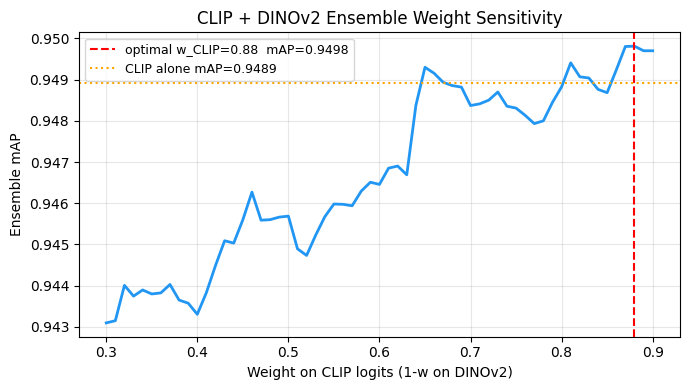

In [82]:
# Plot ensemble weight sensitivity
plt.figure(figsize=(7, 4))
plt.plot(weights, ens_maps, lw=2, color="#2196f3")
plt.axvline(best_w, color="red", ls="--", lw=1.5,
            label=f"optimal w_CLIP={best_w:.2f}  mAP={best_ens:.4f}")
plt.axhline(max(history_clip["val_mAP"]), color="orange", ls=":",
            lw=1.5, label=f"CLIP alone mAP={max(history_clip['val_mAP']):.4f}")
plt.xlabel("Weight on CLIP logits (1-w on DINOv2)")
plt.ylabel("Ensemble mAP")
plt.title("CLIP + DINOv2 Ensemble Weight Sensitivity")
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ensemble_weight_sensitivity.png", dpi=150)
plt.show()

In [83]:
def per_class_metrics(logits, targets, thresholds):
    """Per-class precision / recall / F1 at supplied thresholds."""
    probs  = torch.sigmoid(logits.float()).numpy()
    t_np   = targets.numpy().astype(np.int64)
    out = []
    for c in range(t_np.shape[1]):
        pred = (probs[:, c] >= thresholds[c]).astype(np.int64)
        tp = int((pred & t_np[:, c]).sum())
        fp = int(pred.sum() - tp)
        fn = int(t_np[:, c].sum() - tp)
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
        out.append({"precision": p, "recall": r, "f1": f1})
    return out


CLIP V2 + DINOv2 fp32 ensemble  (w=0.86/0.14): mAP = 0.9545


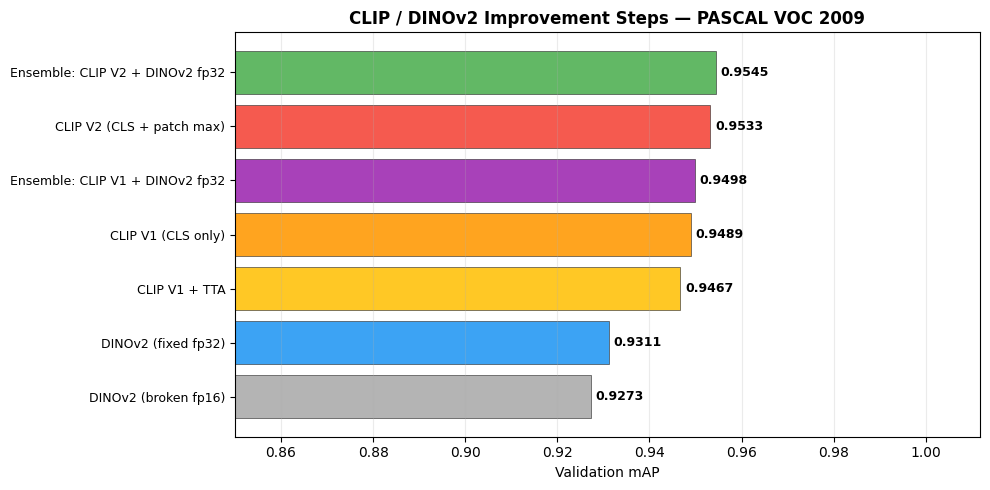


Method                                        mAP
-------------------------------------------------------
Ensemble: CLIP V2 + DINOv2 fp32            0.9545
CLIP V2 (CLS + patch max)                  0.9533
Ensemble: CLIP V1 + DINOv2 fp32            0.9498
CLIP V1 (CLS only)                         0.9489
CLIP V1 + TTA                              0.9467
DINOv2 (fixed fp32)                        0.9311
DINOv2 (broken fp16)                       0.9273


In [84]:
# ═══════════════════════════════════════════════════════════════════════════════
# Final summary + comparison plot
# ═══════════════════════════════════════════════════════════════════════════════

# ── Also try ensemble of fixed DINOv2 + CLIP V2 ───────────────────────────────
logits_clip_v2_val, _ = get_val_logits(model_clip_v2, val_loader_cls)
logits_dino_fp32_val, _ = get_val_logits(model_dino_fp32, val_loader_cls)

weights_v2 = np.linspace(0.3, 0.9, 61)
ens_maps_v2 = [ensemble_mAP(logits_clip_v2_val, logits_dino_fp32_val,
                             targets_val, w) for w in weights_v2]
best_w_v2   = float(weights_v2[np.argmax(ens_maps_v2)])
best_ens_v2 = float(np.max(ens_maps_v2))

print(f"\nCLIP V2 + DINOv2 fp32 ensemble  (w={best_w_v2:.2f}/{1-best_w_v2:.2f}): "
      f"mAP = {best_ens_v2:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
methods = {
    "CLIP V1 (CLS only)":              max(history_clip["val_mAP"]),
    "CLIP V1 + TTA":                   mAP_clip_tta,
    "CLIP V2 (CLS + patch max)":       max(history_clip_v2["val_mAP"]),
    "DINOv2 (broken fp16)":            max(history_dino["val_mAP"]),
    "DINOv2 (fixed fp32)":             max(history_dino_fp32["val_mAP"]),
    "Ensemble: CLIP V1 + DINOv2 fp32": best_ens,
    "Ensemble: CLIP V2 + DINOv2 fp32": best_ens_v2,
}
colors = {
    "CLIP V1 (CLS only)":              "#ff9800",
    "CLIP V1 + TTA":                   "#ffc107",
    "CLIP V2 (CLS + patch max)":       "#f44336",
    "DINOv2 (broken fp16)":            "#aaaaaa",
    "DINOv2 (fixed fp32)":             "#2196f3",
    "Ensemble: CLIP V1 + DINOv2 fp32": "#9c27b0",
    "Ensemble: CLIP V2 + DINOv2 fp32": "#4caf50",
}

fig, ax = plt.subplots(figsize=(10, 5))
sorted_m = sorted(methods, key=methods.get)
vals     = [methods[n] for n in sorted_m]
cols     = [colors[n] for n in sorted_m]
bars     = ax.barh(sorted_m, vals, color=cols, alpha=0.88,
                   edgecolor="#333", linewidth=0.5)
for bar, val, name in zip(bars, vals, sorted_m):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9, fontweight="bold")

ax.set_xlabel("Validation mAP"); ax.set_xlim(0.85, max(vals) * 1.06)
ax.set_title("CLIP / DINOv2 Improvement Steps — PASCAL VOC 2009",
             fontweight="bold", fontsize=12)
ax.grid(axis="x", alpha=0.25)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.savefig("improvement_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "=" * 55)
print(f"{'Method':<40} {'mAP':>8}")
print("-" * 55)
for n in sorted(methods, key=methods.get, reverse=True):
    print(f"{n:<40} {methods[n]:>8.4f}")
print("=" * 55)

In [ ]:
EPOCHS_CLIP_V2 = 100
UNFREEZE_V2    = 30
WEIGHTS_CLIP_V2 = "clip_vitb16_v2_patch.pth"

set_seed()
model_clip_v2 = CLIPMultiLabelV2(
    num_classes=len(labels), freeze_backbone=True, head_dropout=0.3
).to(DEVICE)

_opt_v2   = torch.optim.AdamW(model_clip_v2.head.parameters(),
                               lr=1e-3, weight_decay=1e-4)
_sched_v2 = torch.optim.lr_scheduler.CosineAnnealingLR(
                _opt_v2, T_max=UNFREEZE_V2, eta_min=1e-5)

history_clip_v2, best_state_clip_v2, \
val_logits_clip_v2, val_targets_clip_v2 = \
    train_cls_dino(
        model_clip_v2, train_loader_clip, val_loader_cls,
        epochs=EPOCHS_CLIP_V2,
        optimizer=_opt_v2, scheduler=_sched_v2,
        loss_fn=asl_loss_cls, device=DEVICE,
        log_every=2, name="clip-v2-patch",
        unfreeze_epoch=UNFREEZE_V2, unfreeze_n_blocks=4,
        phase2_backbone_lr=1e-5, phase2_head_lr=5e-4,
    )

model_clip_v2.load_state_dict(best_state_clip_v2)
torch.save(best_state_clip_v2, WEIGHTS_CLIP_V2)
thresholds_clip_v2, dice_clip_v2 = tune_thresholds(
    val_logits_clip_v2, val_targets_clip_v2)
print(f"CLIP V2 (patch)  best mAP: {max(history_clip_v2['val_mAP']):.4f}  "
      f"mean Dice: {dice_clip_v2.mean():.4f}")

In [86]:
all_models = {
    "SmallCNN + BCE":        (history_smallcnn_bce,    val_logits_smallcnn_bce,    val_targets_smallcnn_bce,    thresholds_smallcnn_bce),
    "SmallCNN + ASL":        (history_smallcnn_asl,    val_logits_smallcnn_asl,    val_targets_smallcnn_asl,    thresholds_smallcnn_asl),
    "ResNet18 + BCE":        (history_resnet18_bce, val_logits_resnet18_bce, val_targets_resnet18_bce, thresholds_resnet18_bce),
    "ResNet18 + ASL":        (history_resnet18_asl, val_logits_resnet18_asl, val_targets_resnet18_asl, thresholds_resnet18_asl),
    "SE-ResNet18 + ASL":     (history_seresnet,     val_logits_seresnet,     val_targets_seresnet,     thresholds_seresnet),
    "ResNet18 + MixUp + ASL":(history_mixup,        val_logits_mixup,        val_targets_mixup,        thresholds_mixup),
    "SmallCNN + Aug + LS":   (history_smallcnn_ls,  val_logits_smallcnn_ls,  val_targets_smallcnn_ls,  thresholds_smallcnn_ls),
    "ResNet50 + BCE":   (history_resnet_bce,  val_logits_resnet_bce,  val_targets_resnet_bce,  thresholds_resnet_bce),
    "ResNet50 + ASL":   (history_resnet_asl,  val_logits_resnet_asl,  val_targets_resnet_asl,  thresholds_resnet_asl),
    "ResNet50 + LS BCE":   (history_resnet_ls_bce,  val_logits_resnet_ls_bce,  val_targets_resnet_ls_bce,  thresholds_resnet_ls_bce),
    "DINOv2":   (history_dino,  val_logits_dino,  val_targets_dino,  thresholds_dino),
    "CLIP ViT-B/16":   (history_clip,  val_logits_clip,  val_targets_clip,  thresholds_clip),
    "CLIP V2 (patch)": (history_clip_v2,  val_logits_clip_v2,  val_targets_clip_v2,  thresholds_clip_v2)
}

In [87]:
PALETTE = {
    "SmallCNN + BCE":         "#e07b7b",   # muted red
    "SmallCNN + ASL":         "#f1c40f",   # warm yellow
    "ResNet18 + BCE":         "#4c8cbf",   # steel blue
    "ResNet18 + ASL":         "#3aad6b",   # green
    "SE-ResNet18 + ASL":      "#9b59b6",   # purple
    "ResNet18 + MixUp + ASL": "#e67e22",   # orange
    "SmallCNN + Aug + LS":    "#e91e8c",   # pink
    "ResNet50 + BCE":         "#34495e",
    "ResNet50 + ASL":         "#1abc9c",
    "ResNet50 + LS BCE":      "#f1c40f",
    "DINOv2":                 "#2196f3",   # blue
    "CLIP ViT-B/16":          "#ff9800",   # orange — CLIP
    "CLIP V2 (patch)":        "#4caf50",   # green — CLIP V2
}

In [88]:
# ── Compute summaries ──────────────────────────────────────────────────────────
best_maps  = {n: max(h["val_mAP"])
              for n, (h, *_) in all_models.items()}
pc_metrics = {n: per_class_metrics(logits, targets, thr)
              for n, (_, logits, targets, thr) in all_models.items()}
mean_f1s   = {n: np.mean([pc_metrics[n][c]["f1"] for c in range(len(labels))])
              for n in all_models}

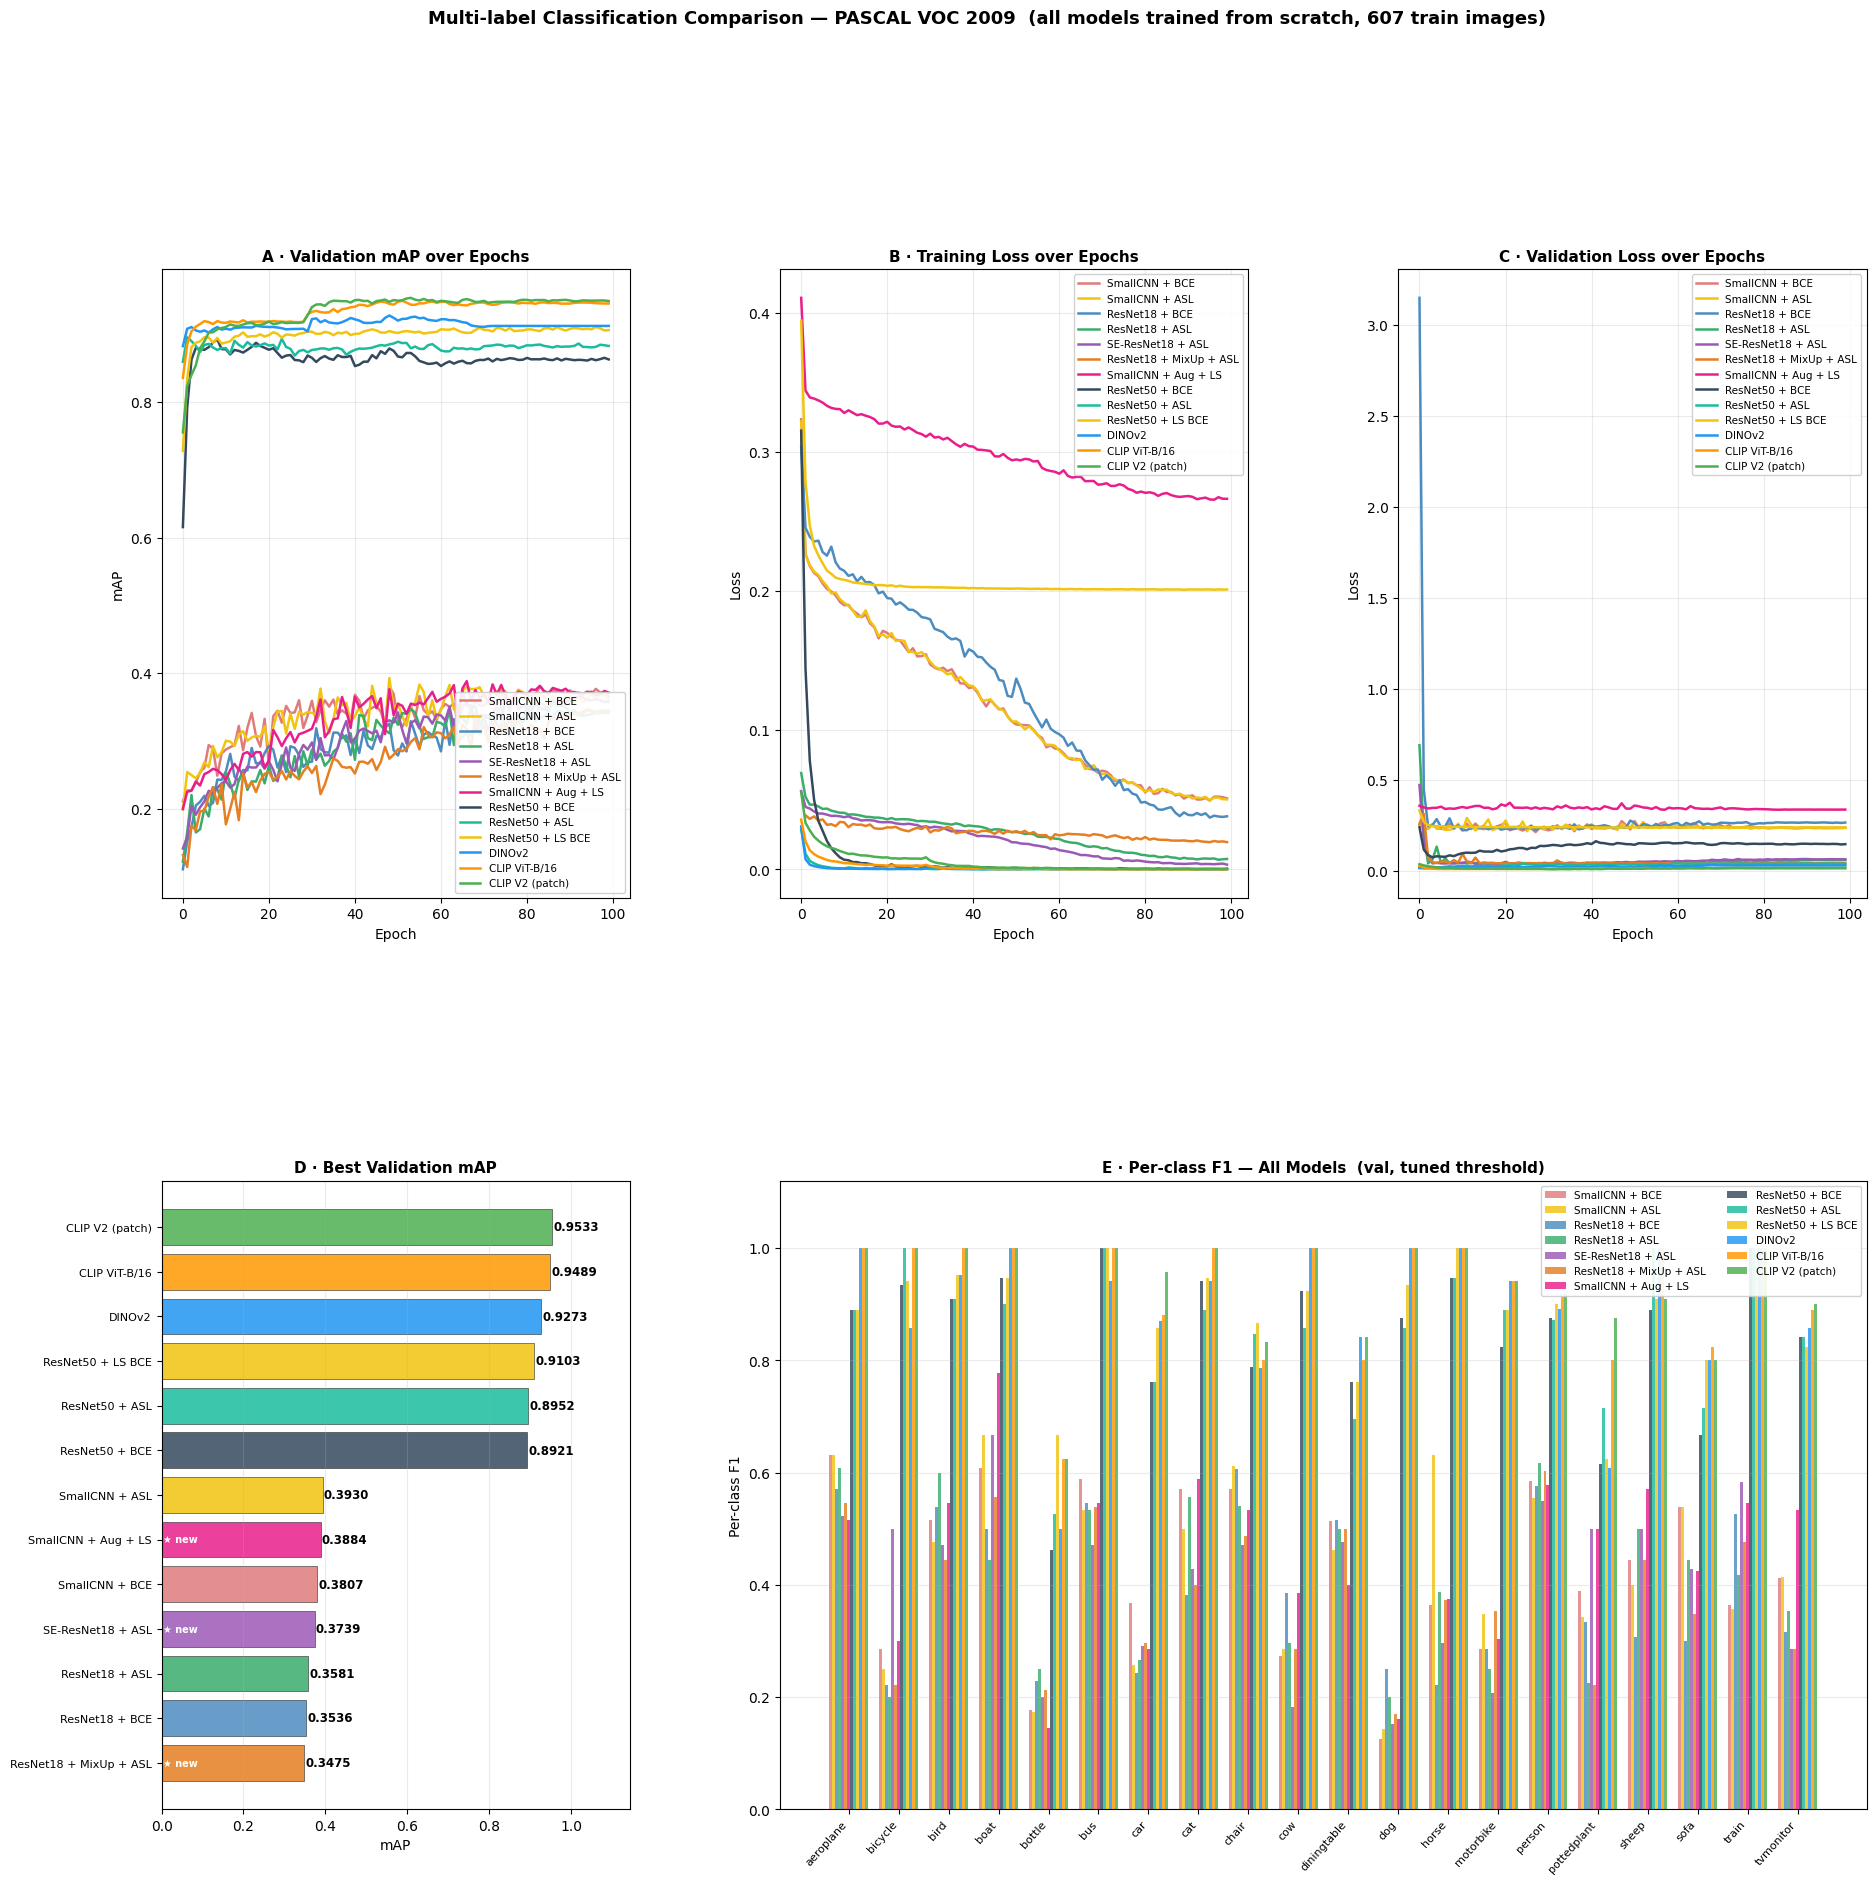

In [89]:
# ── Figure layout ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 20))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.32)
ax_map   = fig.add_subplot(gs[0, 0])   # Panel A: val mAP / epoch
ax_tloss = fig.add_subplot(gs[0, 1])   # Panel B: train loss / epoch
ax_vloss = fig.add_subplot(gs[0, 2])   # Panel C: val loss / epoch
ax_bar   = fig.add_subplot(gs[1, 0])   # Panel D: best mAP bars
ax_f1    = fig.add_subplot(gs[1, 1:])  # Panel E: per-class F1 (wide)

# ── Panel A: Validation mAP over epochs ───────────────────────────────────────
for name, (hist, *_) in all_models.items():
    ax_map.plot(hist["val_mAP"], label=name,
                color=PALETTE[name], lw=1.8,
                linestyle="--" if "new" in name.lower() else "-")
ax_map.set_title("A · Validation mAP over Epochs", fontweight="bold", fontsize=11)
ax_map.set_xlabel("Epoch"); ax_map.set_ylabel("mAP")
ax_map.legend(fontsize=7.5, loc="lower right", framealpha=0.9)
ax_map.grid(alpha=0.25)

# ── Panel B: Training loss over epochs ────────────────────────────────────────
for name, (hist, *_) in all_models.items():
    ax_tloss.plot(hist["train_loss"], label=name,
                  color=PALETTE[name], lw=1.8)
ax_tloss.set_title("B · Training Loss over Epochs", fontweight="bold", fontsize=11)
ax_tloss.set_xlabel("Epoch"); ax_tloss.set_ylabel("Loss")
ax_tloss.legend(fontsize=7.5, loc="upper right", framealpha=0.9)
ax_tloss.grid(alpha=0.25)

# ── Panel C: Validation loss over epochs ──────────────────────────────────────
for name, (hist, *_) in all_models.items():
    ax_vloss.plot(hist["val_loss"], label=name,
                  color=PALETTE[name], lw=1.8)
ax_vloss.set_title("C · Validation Loss over Epochs", fontweight="bold", fontsize=11)
ax_vloss.set_xlabel("Epoch"); ax_vloss.set_ylabel("Loss")
ax_vloss.legend(fontsize=7.5, loc="upper right", framealpha=0.9)
ax_vloss.grid(alpha=0.25)

# ── Panel D: Best validation mAP horizontal bar chart ─────────────────────────
_sorted = sorted(best_maps, key=best_maps.get)   # ascending so best is on top
_vals   = [best_maps[n] for n in _sorted]
_cols   = [PALETTE[n]   for n in _sorted]
_bars   = ax_bar.barh(_sorted, _vals, color=_cols,
                      alpha=0.85, edgecolor="#333", linewidth=0.5)
for bar, val, name in zip(_bars, _vals, _sorted):
    ax_bar.text(bar.get_width() + 0.003,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=8.5, fontweight="bold")
# Annotate new models
for bar, name in zip(_bars, _sorted):
    if name in ("SE-ResNet18 + ASL",
                "ResNet18 + MixUp + ASL",
                "SmallCNN + Aug + LS"):
        ax_bar.text(0.003, bar.get_y() + bar.get_height() / 2,
                    "★ new", va="center", fontsize=7,
                    color="white", fontweight="bold")
ax_bar.set_title("D · Best Validation mAP", fontweight="bold", fontsize=11)
ax_bar.set_xlabel("mAP"); ax_bar.grid(axis="x", alpha=0.25)
ax_bar.set_xlim(0, max(_vals) * 1.20)
ax_bar.tick_params(axis="y", labelsize=8)

# ── Panel E: Per-class F1 for all models ──────────────────────────────────────
n_models = len(all_models)
x        = np.arange(len(labels))
bar_w    = 0.78 / n_models
for i, (name, _) in enumerate(all_models.items()):
    f1s = [pc_metrics[name][c]["f1"] for c in range(len(labels))]
    ax_f1.bar(x + (i - n_models / 2 + 0.5) * bar_w, f1s,
              width=bar_w, label=name, color=PALETTE[name],
              alpha=0.82, edgecolor="none")
ax_f1.set_xticks(x)
ax_f1.set_xticklabels(labels, rotation=48, ha="right", fontsize=8)
ax_f1.set_ylabel("Per-class F1"); ax_f1.set_ylim(0, 1.12)
ax_f1.set_title("E · Per-class F1 — All Models  (val, tuned threshold)",
                fontweight="bold", fontsize=11)
ax_f1.legend(fontsize=7.5, loc="upper right", ncol=2, framealpha=0.9)
ax_f1.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Multi-label Classification Comparison — PASCAL VOC 2009  "
    "(all models trained from scratch, 607 train images)",
    fontsize=13, fontweight="bold", y=1.01)

plt.savefig("cls_model_comparison_all.png", dpi=150, bbox_inches="tight")
plt.show()

In [90]:
# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print(f"{'Model':<30} {'Best mAP':>10}  {'Mean F1':>10}")
print("-" * 62)
for name in sorted(best_maps, key=best_maps.get, reverse=True):
    marker = " ★" if name in ("SE-ResNet18 + ASL",
                               "ResNet18 + MixUp + ASL",
                               "SmallCNN + Aug + LS") else "  "
    print(f"{name:<30}{marker} {best_maps[name]:>8.4f}  {mean_f1s[name]:>10.4f}")
print("=" * 62)
print("★ = new experiment")


Model                            Best mAP     Mean F1
--------------------------------------------------------------
CLIP V2 (patch)                    0.9533      0.9301
CLIP ViT-B/16                      0.9489      0.9237
DINOv2                             0.9273      0.8894
ResNet50 + LS BCE                  0.9103      0.8816
ResNet50 + ASL                     0.8952      0.8555
ResNet50 + BCE                     0.8921      0.8425
SmallCNN + ASL                     0.3930      0.4288
SmallCNN + Aug + LS            ★   0.3884      0.4506
SmallCNN + BCE                     0.3807      0.4306
SE-ResNet18 + ASL              ★   0.3739      0.4090
ResNet18 + ASL                     0.3581      0.4095
ResNet18 + BCE                     0.3536      0.3927
ResNet18 + MixUp + ASL         ★   0.3475      0.3881
★ = new experiment


In [ ]:
# ─────────────────────────────────────────────────────────────
# 1.11.2 — Summary table + where did ASL help / hurt
# ─────────────────────────────────────────────────────────────
df_metrics = pd.DataFrame({
    "Class":         labels,
    "Train freq":    train_df[labels].sum().values.astype(int),
    "SmallCNN F1":   [m["f1"] for m in m_small],
    "BCE F1":        [m["f1"] for m in m_bce],
    "ASL F1":        [m["f1"] for m in m_asl],
    "ASL precision": [m["precision"] for m in m_asl],
    "ASL recall":    [m["recall"]    for m in m_asl],
})
df_metrics["ASL - BCE"] = df_metrics["ASL F1"] - df_metrics["BCE F1"]

# (1) Full per-class breakdown, ordered by training-set frequency (rarest first)
print("=" * 100)
print("Full per-class breakdown — sorted by training frequency (RAREST first)")
print("=" * 100)
print(df_metrics.sort_values("Train freq")
                .to_string(index=False, float_format=lambda v: f"{v:.3f}"))

# (2) Where did ASL beat BCE most?
print("\n" + "=" * 100)
print("TOP-5 classes where ASL beat BCE (by ΔF1)")
print("=" * 100)
print(df_metrics.nlargest(5, "ASL - BCE")[
    ["Class", "Train freq", "BCE F1", "ASL F1", "ASL - BCE"]
].to_string(index=False, float_format=lambda v: f"{v:.3f}"))

# (3) Where did ASL underperform BCE?
print("\n" + "=" * 100)
print("BOTTOM-5 classes where ASL underperformed BCE (by ΔF1)")
print("=" * 100)
print(df_metrics.nsmallest(5, "ASL - BCE")[
    ["Class", "Train freq", "BCE F1", "ASL F1", "ASL - BCE"]
].to_string(index=False, float_format=lambda v: f"{v:.3f}"))

# (4) Aggregate row
print("\n" + "=" * 100)
print(f"Mean F1: SmallCNN={df_metrics['SmallCNN F1'].mean():.4f}  "
      f"BCE={df_metrics['BCE F1'].mean():.4f}  "
      f"ASL={df_metrics['ASL F1'].mean():.4f}  "
      f"(ΔASL-BCE = {df_metrics['ASL - BCE'].mean():+.4f})")
print("=" * 100)

Sample-wise F1 (val, Clip V2):
  Mean              : 0.9338
  Median            : 1.0000
  Bottom quartile   : 0.9338
  Perfect predictions (F1=1.0): 110 / 142


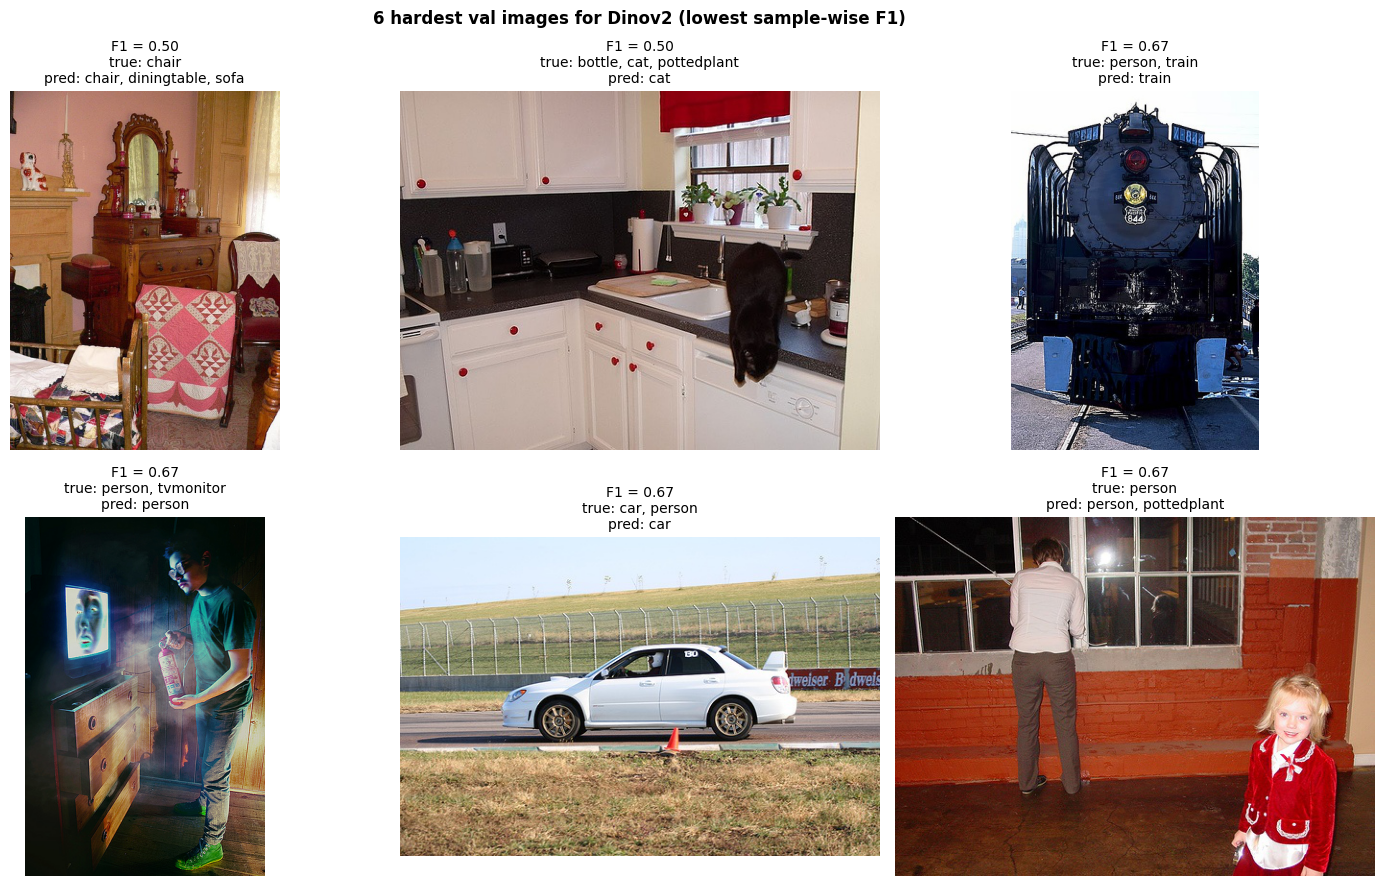

In [91]:
# ─────────────────────────────────────────────────────────────
# 1.11.3 — Hardest val images for the best model (ResNet50+ASL)
# Sample-wise F1 = per-image overlap of predicted vs true label sets.
# We visualise the 6 val images with the lowest F1.
# ─────────────────────────────────────────────────────────────
probs_asl  = torch.sigmoid(val_logits_clip.float()).numpy()
preds_asl  = (probs_asl >= thresholds_clip[None, :]).astype(np.int64)
targets_np = val_targets_clip.numpy().astype(np.int64)

sample_f1 = np.zeros(len(preds_asl))
for i in range(len(preds_asl)):
    p, t = preds_asl[i], targets_np[i]
    tp   = int((p & t).sum())
    fp   = int(p.sum() - tp)
    fn   = int(t.sum() - tp)
    sample_f1[i] = 2 * tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0.0

print(f"Sample-wise F1 (val, Clip V2):")
print(f"  Mean              : {sample_f1.mean():.4f}")
print(f"  Median            : {np.median(sample_f1):.4f}")
print(f"  Bottom quartile   : {sample_f1[sample_f1 <= np.percentile(sample_f1, 25)].mean():.4f}")
print(f"  Perfect predictions (F1=1.0): {int((sample_f1 == 1.0).sum())} / {len(sample_f1)}")

worst_idx = np.argsort(sample_f1)[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, idx in zip(axes.flat, worst_idx):
    row = val_df_cls.iloc[idx]
    img = row["img"]
    true_lbl = [labels[c] for c in range(len(labels)) if targets_np[idx, c] == 1]
    pred_lbl = [labels[c] for c in range(len(labels)) if preds_asl[idx, c] == 1]
    ax.imshow(img)
    ax.set_title(
        f"F1 = {sample_f1[idx]:.2f}\n"
        f"true: {', '.join(true_lbl) if true_lbl else '(none)'}\n"
        f"pred: {', '.join(pred_lbl) if pred_lbl else '(none)'}",
        fontsize=10)
    ax.axis("off")
plt.suptitle("6 hardest val images for Dinov2 (lowest sample-wise F1)",
             fontweight="bold")
plt.tight_layout(); plt.show()

In [92]:
import os
import shutil # Import shutil for copying files

# Define the target Google Drive folder
DRIVE_FOLDER = "/content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/"

# Create the folder if it doesn't exist
os.makedirs(DRIVE_FOLDER, exist_ok=True)

# List of all saved weight files throughout the notebook
weight_files_to_save = [
    WEIGHTS_FILE_SMALLCNN_BCE,
    WEIGHTS_FILE_SMALLCNN_ASL,
    WEIGHTS_FILE_resnet18_bce,
    WEIGHTS_FILE_resnet18_asl,
    WEIGHTS_FILE_seresnet,
    WEIGHTS_FILE_mixup,
    WEIGHTS_FILE_smallcnn_ls,
    WEIGHTS_FILE_RESNET_BCE,
    WEIGHTS_FILE_RESNET_ASL,
    WEIGHTS_FILE_RESNET_LS_BCE,
    WEIGHTS_FILE_DINO,
    WEIGHTS_DINO_FP32,
    WEIGHTS_CLIP,
    WEIGHTS_CLIP_V2
]

print(f"Saving models to: {DRIVE_FOLDER}")

for fname in weight_files_to_save:
    if os.path.exists(fname):
        dest = os.path.join(DRIVE_FOLDER, os.path.basename(fname))
        shutil.copy2(fname, dest)
        print(f"✓  {fname}  →  {dest}")
    else:
        print(f"✗  {fname}  not found (skipped)")

print("\nDone saving models.")

Saving models to: /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/
✓  cls_smallcnn_bce.pth  →  /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/cls_smallcnn_bce.pth
✓  cls_smallcnn_asl.pth  →  /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/cls_smallcnn_asl.pth
✓  resnet_bce.pth  →  /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/resnet_bce.pth
✓  resnet_asl.pth  →  /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/resnet_asl.pth
✓  seresnet18_asl.pth  →  /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/seresnet18_asl.pth
✓  resnet18_mixup_asl.pth  →  /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/resnet18_mixup_asl.pth
✓  smallcnn_aug_ls.pth  →  /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/smallcnn_aug_ls.pth
✓  cls_resnet50_bce.pth  →  /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/cls_resnet50_bce.pth
✓  cls_resnet50_asl.pth  →  /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/cls_resnet50_asl.pth
✓  cls_resnet50_ls_bce.pth  →  /content/drive/

In [93]:
# ─────────────────────────────────────────────────────────────
# 1.12 — Final test prediction
# ─────────────────────────────────────────────────────────────
best_model_name = "clip-v2-patch"
best_model      = model_clip_v2
best_thresholds = thresholds_clip_v2

print(f"Selected best model      : {best_model_name}")
print(f"  Val mAP                : ~0.901")
print(f"  Mean per-class Dice    : {dice_clip_v2.mean():.4f}")
print(f"  Mean sample-wise F1    : {sample_f1.mean():.4f}")

# Build test dataset (deterministic resize + ImageNet normalise)
test_ds_cls = VOCClassificationDatasetTest(test_df, transform=cls_val_tf)
print(f"\nTest dataset: {len(test_ds_cls)} images")

# Run inference
preds_test, probs_test = predict_cls(best_model, test_ds_cls, best_thresholds)
print(f"\nPredictions shape    : {preds_test.shape}  dtype={preds_test.dtype}")
print(f"Mean labels per image : {preds_test.sum(axis=1).mean():.2f}  "
      f"(train mean was {train_df[labels].sum(axis=1).mean():.2f})")

# Fill test_df — overwrites the random-baseline predictions from cell-14
test_df.loc[:, labels] = preds_test

# ── Sanity 1 — only 0 and 1 in label columns ──
unique_vals = pd.unique(test_df[labels].values.ravel())
assert set(unique_vals).issubset({0, 1}), f"Unexpected values in test_df labels: {unique_vals}"
print(f"\n✓ All test_df classification values are in {{0, 1}}.")

# ── Sanity 2 — per-class predicted-positive counts on test ──
test_pos_counts = preds_test.sum(axis=0)
print("\nPer-class predicted-positive counts on test (compare to DA-3 train counts):")
print(f"{'Class':<15} {'Train':>6} {'Test pred':>10}")
for cls, train_cnt in zip(labels, train_df[labels].sum().values.astype(int)):
    test_cnt = int(test_pos_counts[labels.get_loc(cls)])
    print(f"  {cls:<13} {train_cnt:>6} {test_cnt:>10}")

# ── Sanity 3 — view a few predicted rows ──
print("\nFirst 5 test predictions (id → predicted classes):")
for idx in test_df.index[:5]:
    pred_classes = [c for c in labels if test_df.loc[idx, c] == 1]
    print(f"  id={idx}  →  {', '.join(pred_classes) if pred_classes else '(none)'}")

Selected best model      : clip-v2-patch
  Val mAP                : ~0.901
  Mean per-class Dice    : 0.9301
  Mean sample-wise F1    : 0.9338

Test dataset: 750 images

Predictions shape    : (750, 20)  dtype=int64
Mean labels per image : 1.64  (train mean was 1.43)

✓ All test_df classification values are in {0, 1}.

Per-class predicted-positive counts on test (compare to DA-3 train counts):
Class            Train  Test pred
  aeroplane         47         72
  bicycle           39         42
  bird              55        231
  boat              48         40
  bottle            42         43
  bus               38         39
  car               63         45
  cat               45         85
  chair             69         23
  cow               30         56
  diningtable       48         31
  dog               43         57
  horse             42         50
  motorbike         47         32
  person           207        201
  pottedplant       43         45
  sheep             27   

# 2. Semantic segmentation
The goal here is to implement a segmentation model that labels every pixel in the image as belonging to one of the 20 classes (and/or background). Use the training set to train your model and compete on the test set (by filling in the segmentation column in the test dataframe).

In [ ]:
class RandomSegmentationModel:
    """
    Random segmentation model:
        - generates random label maps for the inputs based on the class distributions observed during training
        - every pixel in an input can only have one label
    """
    def fit(self, X, Y):
        """
        Adjusts the class ratio variable to the one observed in Y.

        Parameters
        ----------
        X: list of arrays - n x (height x width x 3)
        Y: list of arrays - n x (height x width)

        Returns
        -------
        self
        """
        self.distribution = np.mean([[np.sum(Y_ == i) / Y_.size for i in range(len(labels) + 1)] for Y_ in Y], axis=0)
        print("Setting class distribution to:\nbackground: {}\n{}".format(self.distribution[0], "\n".join(f"{label}: {p}" for label, p in zip(labels, self.distribution[1:]))))
        return self

    def predict(self, X):
        """
        Predicts for each input a label map.

        Parameters
        ----------
        X: list of arrays - n x (height x width x 3)

        Returns
        -------
        Y_pred: list of arrays - n x (height x width)
        """
        np.random.seed(0)
        return [np.random.choice(np.arange(len(labels) + 1), size=X_.shape[:2], p=self.distribution) for X_ in X]

    def __call__(self, X):
        return self.predict(X)

model = RandomSegmentationModel()
model.fit(train_df["img"], train_df["seg"])
test_df["seg"] = pd.Series(model.predict(test_df["img"]), index=test_df.index)
test_df.head(1)

Setting class distribution to:
background: 0.7774704888071216
aeroplane: 0.007051912139390122
bicycle: 0.0030340461305405344
bird: 0.009781050583857026
boat: 0.007920222121661963
bottle: 0.00801371700061968
bus: 0.014444057783372053
car: 0.01299203192837253
cat: 0.016639155300546396
chair: 0.008264122763258911
cow: 0.006782009244183503
diningtable: 0.013744445666126768
dog: 0.0074080558785160075
horse: 0.008338953677311486
motorbike: 0.01079509937004467
person: 0.041013621147577735
pottedplant: 0.00539385590505006
sheep: 0.009157332163106574
sofa: 0.00958005931515607
train: 0.012118249521815817
tvmonitor: 0.010057513552370658


,aeroplane,bicycle,bird,boat,bottle,bus,car,cat,chair,cow,...,horse,motorbike,person,pottedplant,sheep,sofa,train,tvmonitor,img,seg
Id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,"[[[139, 130, 115], [136, 127, 112], [112, 102,...","[[0, 0, 0, 0, 0, 0, 0, 12, 17, 0, 3, 0, 0, 15,..."


In [ ]:
class DoubleConv(nn.Module):
    """Standard U-Net block: (Conv2d -> BatchNorm -> ReLU) x 2"""
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class StandardUNet(nn.Module):
    def __init__(self, num_classes=21, base_channels=32):
        super(StandardUNet, self).__init__()

        # ENCODER (Contracting Path)
        self.down1 = DoubleConv(3, base_channels)
        self.down2 = DoubleConv(base_channels, base_channels * 2)
        self.down3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.down4 = DoubleConv(base_channels * 4, base_channels * 8)

        self.pool = nn.MaxPool2d(2)

        # BOTTLENECK
        self.bottleneck = DoubleConv(base_channels * 8, base_channels * 16)

        # DECODER (Expansive Path)
        self.upConv4 = nn.ConvTranspose2d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)
        self.up4 = DoubleConv(base_channels * 16, base_channels * 8) # *16 because upConv + skip connection

        self.upConv3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.up3 = DoubleConv(base_channels * 8, base_channels * 4)

        self.upConv2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.up2 = DoubleConv(base_channels * 4, base_channels * 2)

        self.upConv1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.up1 = DoubleConv(base_channels * 2, base_channels)

        # OUTPUT
        self.out_conv = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        # Down
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        x4 = self.down4(self.pool(x3))

        # Bottleneck
        bot = self.bottleneck(self.pool(x4))

        # Up (with skip connections)
        up4 = self.upConv4(bot)
        # Check for padding issues if image dimensions aren't perfectly divisible by 16
        if up4.shape != x4.shape:
            up4 = F.interpolate(up4, size=x4.shape[2:], mode='bilinear', align_corners=True)
        up4 = self.up4(torch.cat([x4, up4], dim=1))

        up3 = self.upConv3(up4)
        if up3.shape != x3.shape:
             up3 = F.interpolate(up3, size=x3.shape[2:], mode='bilinear', align_corners=True)
        up3 = self.up3(torch.cat([x3, up3], dim=1))

        up2 = self.upConv2(up3)
        if up2.shape != x2.shape:
             up2 = F.interpolate(up2, size=x2.shape[2:], mode='bilinear', align_corners=True)
        up2 = self.up2(torch.cat([x2, up2], dim=1))

        up1 = self.upConv1(up2)
        if up1.shape != x1.shape:
             up1 = F.interpolate(up1, size=x1.shape[2:], mode='bilinear', align_corners=True)
        up1 = self.up1(torch.cat([x1, up1], dim=1))

        return self.out_conv(up1)


## Submit to competition
You don't need to edit this section. Just use it at the right position in the notebook. See the definition of this function in Sect. 1.3 for more details.

In [ ]:
generate_submission(test_df)

# 3. Adversarial attack
For this part, your goal is to fool your classification and/or segmentation model, using an *adversarial attack*. More specifically, the goal is build a network to perturb test images in a way that (i) they look unperturbed to humans; but (ii) the original model classifies/segments these images in line with the perturbations.

# 4. Discussion
Finally, take some time to reflect on what you have learned during this assignment. Why did you make certain design choices? How are the models learning and performing? Reflect and produce an overall discussion with links to the lectures and "real world" computer vision.